In [195]:
import pandas as pd
import numpy as np
import sys
import glob
from scipy.ndimage import median_filter, gaussian_filter
from scipy import signal
import math
import matplotlib.pyplot as plt
import mwdust
from astropy.coordinates import SkyCoord
import astropy.units as u
from scipy.interpolate import CubicSpline
from astropy import constants as const
from astropy.io import ascii
# import astrodash
import pickle
import itertools

In [196]:
sys.path.append("/Users/pnr5sh/Documents/phd/mmmp/")
import sidchaini.sidhelpers as sidhelpers

In [197]:
#reading in meta data from my dir
dataset = pd.read_csv('multipeak_dataset_metadata.csv', header='infer')
dataset['ztf_name'] = ['ZTF']*len(dataset)
dataset.columns

Index(['wise_objid', 'IAU name', 'Internal name/s', 'Obj. RA', 'Obj. DEC',
       'Obj. Type', 'Redshift', 'Spec. ID', 'Obs-date', 'JD', 'Phase (days)',
       'From', 'Telescope', 'Instrument', 'Observer/s', 'Reducer/s',
       'Source group', 'Public', 'Associated groups', 'End prop. period',
       'Ascii file', 'Fits file', 'Spec. type', 'Spec. quality',
       'Extinction-Corrected', 'WL Medium', 'WL Units',
       'Flux Unit Coefficient', 'Spec. units', 'Flux Calibrated By',
       'Exp-time', 'Aperture (slit)', 'HA', 'Airmass', 'Dichroic', 'Grism',
       'Grating', 'Blaze', 'Lambda-min', 'Lambda-max', 'Del-Lambda', 'Contrib',
       'Publish', 'Remarks', 'Created by', 'Creation date', 'mjd', 'peak_mjd',
       'peak_mag', 'peak_filt', 'double-peaked', 'ztf_name'],
      dtype='object')

In [198]:
#manually renaming objects w/o pre-loaded ZTF names
dataset.loc[dataset['IAU name']=='SN 2024zsw', 'Internal name/s'] = 'ZTF24abpdzvm'
dataset.loc[dataset['IAU name']=='SN 2020urc', 'Internal name/s'] = 'ZTF20acgiglu'
# dataset.loc[dataset['IAU name']=='SN 2018cew', 'Internal name/s'] = 'ZTF...' #doesnt have name?
dataset.loc[dataset['IAU name']=='SN 2024abmk', 'Internal name/s'] = 'ZTF24absznoi'
dataset.loc[dataset['IAU name']=='SN 2024abtu', 'Internal name/s'] = 'ZTF24abtnkbi'
dataset.loc[dataset['IAU name']=='SN 2024zzy', 'Internal name/s'] = 'ZTF24abqqven'

In [201]:
#populating the ztf_name feature of the dataset by extracting from internal name/s feature

intnamelist = dataset['Internal name/s'].to_list()
iaunames = dataset['IAU name'].to_list()

name_list = [(str(intnamelist[i]), str(iaunames[i])) for i in range(len(intnamelist))]

for pair in name_list:
    intname = pair[0]
    iauname = pair[1]
    varX = "ZTF"
    index = intname.find(varX)
    ztf_name = intname[index:index+12]
    if ztf_name[0] != 'Z':
        print(f'warning: could not parse out ZTF name from internal names list for {iauname}')
    else:
        dataset.loc[dataset['IAU name']==iauname, 'ztf_name'] = ztf_name

In [202]:
# removing SN2023aew+2018cew+FBOT and the extra spectra from 22oqm and 19hgp from the dataset

dataset = dataset.loc[(~dataset['Spec. ID'].isin([60564.0, 64670.0, 64672.0, 64683.0, 67011.0, 67012.0, 67015.0, 67016.0, 67018.0, 67020.0, 67885.0, 67883.0, 67887.0, 67888.0]))
                   &~(dataset['IAU name']=='SN 2023aew')&~(dataset['IAU name']=='SN 2018cew')&
                   ~(dataset['Obj. Type']=='FBOT')].reset_index()
dataset

,index,wise_objid,IAU name,Internal name/s,Obj. RA,Obj. DEC,Obj. Type,Redshift,Spec. ID,Obs-date,...,Publish,Remarks,Created by,Creation date,mjd,peak_mjd,peak_mag,peak_filt,double-peaked,ztf_name
0,0,13342.0,SN 2018avy,"ZTF18aahhzqn, Gaia18aze",178.754792,32.075350,SN Ib/c,0.031000,54254.0,2018-04-21 04:37:36.00,...,NaN,[TNS source group: 48 - ZTF ],TNS_Bot1,2019-10-07 23:05:03,58229.192778,58225.156007,18.147050,ZTF_r,1,ZTF18aahhzqn
1,1,12430.0,SN 2018bcc,"ZTF18aakuewf, Gaia18bbd, ATLAS18nkv",243.594375,35.917889,SN Ibn,0.063600,52076.0,2018-04-25 07:55:12.00,...,NaN,Absolute flux calibrated using ZTF photometry ...,Emir Karamehmetoglu,2019-06-04 15:09:05,58233.330000,58231.129356,17.692159,ZTF_g,0,ZTF18aakuewf
2,3,15860.0,SN 2018fzn,ZTF18abojpnr,297.487120,59.592827,SN IIb,0.037500,66712.0,2018-08-21 09:31:40.00,...,2021ApJ...912...46B,NaN,WIS_ZTF_Bot,2022-07-07 12:22:55,58351.397000,58370.051276,19.171934,ZTF_g,0,ZTF18abojpnr
3,4,15860.0,SN 2018fzn,ZTF18abojpnr,297.487120,59.592827,SN IIb,0.037500,66713.0,2018-09-09 04:33:36.00,...,2021ApJ...912...46B,NaN,WIS_ZTF_Bot,2022-07-07 12:22:55,58370.190000,58370.051276,19.171934,ZTF_g,0,ZTF18abojpnr
4,5,14851.0,SN 2018gcj,"ATLAS18uxi, ZTF18absliyc",6.005904,-1.223377,SN Ic,0.080000,57217.0,2018-09-11 08:56:52.00,...,NaN,[TNS source group: 48 - ZTF ],TNS_Bot1,2020-06-11 23:05:04,58372.372824,58371.685414,18.892202,ZTF_g,0,ZTF18absliyc
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
122,160,27192.0,SN 2024afbf,"ZTF24abzgggz, ATLAS24rxe",170.447324,46.128450,SN Ic,0.030000,85050.0,2025-01-02 09:29:51.00,...,NaN,[TNS reporting group: 48 - ZTF ],TNS_Bot1,2025-01-03 06:10:05,60677.395729,60675.269521,19.457773,ZTF_g,0,ZTF24abzgggz
123,161,25944.0,SN 2024rbc,"GOTO24elc, ATLAS24mky, ZTF24aaymkrs",3.089359,31.063392,SN Ib,0.016000,83170.0,2024-08-13 08:56:16.00,...,NaN,[TNS source group: 48 - ZTF ],TNS_Bot1,2024-08-13 10:10:04,60535.372407,60537.304655,17.396463,ZTF_g,0,ZTF24aaymkrs
124,162,26960.0,SN 2024zsw,ZTF24abpdzvm,20.793617,19.570172,SN IIb,0.032286,84756.0,2024-11-18 03:41:26.00,...,NaN,[TNS source group: 48 - ZTF ],TNS_Bot1,2024-12-24 17:18:57,60632.153773,60632.542341,19.196814,ZTF_g,1,ZTF24abpdzvm
125,163,26941.0,SN 2024zzy,ZTF24abqqven,150.722002,8.437942,SN Ib,0.030487,84730.0,2024-11-09 09:44:17.00,...,NaN,[TNS source group: 48 - ZTF ],TNS_Bot1,2024-12-24 17:18:57,60623.405752,60624.468310,17.892795,ZTF_r,0,ZTF24abqqven


In [203]:
#creating our version of the ZTF BTS metadata info file
# ZTFID,IAUID,RA,Dec,peakt,peakfilt,peakmag,peakabs,duration,rise,fade,type,redshift,b,A_V
# already have: ZTFID,IAUID,RA,Dec,peakt,peakfilt,peakmag,type,redshift, double-peaked
# want to get: A_V, [could calc peakabs if want, fits weren't necessarily constrained]
# ignoring: duration, rise, fade, b, peakabs

#?TODO: calc abs mag (hubble flow?)

bs_ZTFBTS = pd.DataFrame(columns=['ZTFID','IAUID','RA','Dec','peakt','peakfilt',
                                  'peakmag','type','redshift','double-peaked'])

znames, iaunames, ras, decs, pmjds, pfilts, pmags, types, zs, dps = [],[],[],[],[],[],[],[],[],[]
for i,obj in enumerate(dataset['ztf_name'].unique()):
    if obj=='ZTF':
        print(f'No ZTF name, skipping {dataset.loc[dataset['ztf_name']=='ZTF', 'IAU name'].iloc[0]} for now...')
    else:
        data = dataset.loc[dataset['ztf_name']==obj]
        
        #some objs have repeat entries, just taking the first one
        znames.append(data['ztf_name'].iloc[0])
        iaunames.append(data['IAU name'].iloc[0][0:2]+data['IAU name'].iloc[0][3:])
        ras.append(data['Obj. RA'].iloc[0])
        decs.append(data['Obj. DEC'].iloc[0])
        pmjds.append(data['peak_mjd'].iloc[0])
        pfilts.append(data['peak_filt'].iloc[0][-1])
        pmags.append(data['peak_mag'].iloc[0])
        types.append(data['Obj. Type'].iloc[0])
        zs.append(data['Redshift'].iloc[0])
        dps.append(data['double-peaked'].iloc[0])
        

bs_ZTFBTS['ZTFID'] = znames
bs_ZTFBTS['IAUID'] = iaunames
bs_ZTFBTS['RA'] = ras
bs_ZTFBTS['Dec'] = decs
bs_ZTFBTS['peakt'] = pmjds
bs_ZTFBTS['peakfilt'] = pfilts
bs_ZTFBTS['peakmag'] = pmags
bs_ZTFBTS['type'] = types
bs_ZTFBTS['redshift'] = zs
bs_ZTFBTS['double-peaked'] = dps

In [204]:
# #Dropping the FBOT object
# bs_ZTFBTS = bs_ZTFBTS.drop(bs_ZTFBTS.loc[bs_ZTFBTS['type']=='FBOT'].index)

In [207]:
#calculating extinction
r_v = 3.1

avs = []
for i in range(len(bs_ZTFBTS)):
    sfd = mwdust.SFD()
    coord = SkyCoord(bs_ZTFBTS.RA.iloc[i] * u.deg, bs_ZTFBTS.Dec.iloc[i] * u.deg).galactic
    av = r_v*sfd(coord.l.value, coord.b.value, 5000)[0]
    avs.append(av)

bs_ZTFBTS['A_V'] = avs

In [208]:
#create a col that has the "filenames" for the pre-processed spectra (and thus LCs)
fnames = []
for i,ztf in enumerate(dataset['ztf_name'].unique()):
    no_spec = len(dataset.loc[dataset['ztf_name']==ztf, :])
    fname = [ f"{ztf}_{i}" for i in range(no_spec)]
    fnames.append(fname)

ztfs = dataset['ztf_name'].unique()
fnames = pd.Series(fnames)
data = {"ZTFID":ztfs, "filenames":fnames}
temp_df = pd.DataFrame(data)

bs_ZTFBTS = pd.merge(bs_ZTFBTS,temp_df,on='ZTFID', how='inner')

# fns = []
# for fnlist in bs_ZTFBTS.filenames.to_numpy(copy=True):
#     fns += fnlist
# print(fns)

In [209]:
#class balance b/w single and double peaked
print(len(bs_ZTFBTS.loc[bs_ZTFBTS['double-peaked']==0])/len(bs_ZTFBTS), len(bs_ZTFBTS.loc[bs_ZTFBTS['double-peaked']==1])/len(bs_ZTFBTS))
print(len(bs_ZTFBTS.loc[bs_ZTFBTS['double-peaked']==0]), len(bs_ZTFBTS.loc[bs_ZTFBTS['double-peaked']==1]), len(bs_ZTFBTS))

0.803921568627451 0.19607843137254902
82 20 102


In [210]:
print('SNTYPE, N, N-1, N-2+')
for sntype in bs_ZTFBTS.type.unique():
    print(sntype, '&',
          len(bs_ZTFBTS.loc[bs_ZTFBTS['type'] == sntype]), '&',
          len(bs_ZTFBTS.loc[(bs_ZTFBTS['type'] == sntype)&((bs_ZTFBTS['double-peaked']==0))]),'&',
          len(bs_ZTFBTS.loc[(bs_ZTFBTS['type'] == sntype)&((bs_ZTFBTS['double-peaked']==1))]),
          )

SNTYPE, N, N-1, N-2+
SN Ib/c & 4 & 3 & 1
SN Ibn & 5 & 4 & 1
SN IIb & 18 & 11 & 7
SN Ic & 46 & 40 & 6
SN Ib & 26 & 23 & 3
SN Icn & 1 & 0 & 1
SN Ib-Ca-rich & 1 & 0 & 1
SN Ic-pec & 1 & 1 & 0


In [211]:
bs_ZTFBTS.to_csv('./maven_data/bs_ZTFBTS_TransientTable.csv', index=False, index_label=False)

In [15]:
kfold1 = bs_ZTFBTS.iloc[0:21][['double-peaked', 'filenames']]  #2, 22
kfold2 = bs_ZTFBTS.iloc[21:39][['double-peaked', 'filenames']] #12, 13
kfold3 = bs_ZTFBTS.iloc[39:56][['double-peaked', 'filenames']] #9, 15
kfold4 = bs_ZTFBTS.iloc[56:77][['double-peaked', 'filenames']] #8, 19
kfold5 = bs_ZTFBTS.iloc[77:][['double-peaked', 'filenames']]   #4, 20

kfold2# kfold2.unique(), kfold3.unique(), kfold4.unique(), kfold5.unique()

,double-peaked,filenames
21,1,"[ZTF19aayejww_0, ZTF19aayejww_1, ZTF19aayejww_..."
22,1,[ZTF19aaznwze_0]
23,0,[ZTF19abafmwj_0]
24,0,[ZTF19abcyqqg_0]
25,0,[ZTF18aahuujv_0]
26,0,[ZTF19abfiqjg_0]
27,0,[ZTF19abqmsnk_0]
28,0,[ZTF19abvdgqo_0]
29,0,[ZTF19abxtcio_0]
30,0,[ZTF19aceshib_0]


In [16]:
#kfold splits: 
kfold1 = sum(bs_ZTFBTS.iloc[0:21].filenames.to_list(), [])  #24
kfold2 = sum(bs_ZTFBTS.iloc[21:39].filenames.to_list(), []) #25
kfold3 = sum(bs_ZTFBTS.iloc[39:56].filenames.to_list(), []) #24
kfold4 = sum(bs_ZTFBTS.iloc[56:77].filenames.to_list(), []) #27
kfold5 = sum(bs_ZTFBTS.iloc[77:].filenames.to_list(), [])   #24

kfold1_idx = list(range(len(kfold1)))
kfold2_idx = list(range(len(kfold1), len(kfold1)+len(kfold2)))
kfold3_idx = list(range(len(kfold1)+len(kfold2), len(kfold1)+len(kfold2)+len(kfold3)))
kfold4_idx = list(range(len(kfold1)+len(kfold2)+len(kfold3), len(kfold1)+len(kfold2)+len(kfold3)+len(kfold4)))
kfold5_idx = list(range(len(kfold1)+len(kfold2)+len(kfold3)+len(kfold4), len(kfold1)+len(kfold2)+len(kfold3)+len(kfold4)+len(kfold5)))

all_idx = list(range(len(kfold1)+len(kfold2)+len(kfold3)+len(kfold4)+len(kfold5)))

#saving the train, test indices as tuples in array to load into maven
kfold_split_dict = {
    'kfold1': ([x for x in all_idx if x not in kfold1_idx], kfold1_idx),
    'kfold2': ([x for x in all_idx if x not in kfold2_idx], kfold2_idx),
    'kfold3': ([x for x in all_idx if x not in kfold3_idx], kfold3_idx),
    'kfold4': ([x for x in all_idx if x not in kfold4_idx], kfold4_idx),
    'kfold5': ([x for x in all_idx if x not in kfold5_idx], kfold5_idx),
}

with open('maven_data/kfold_split_dict.pkl', 'wb+') as f:
    pickle.dump(kfold_split_dict, f)

QUICK STATS for single-peaked:
count    82.000000
mean      1.697308
std       8.549151
min     -19.119502
25%      -4.765445
50%       0.753535
75%       7.823236
max      31.979753
dtype: float64
QUICK STATS for double-peaked:
count    18.000000
mean     -3.002518
std      11.071901
min     -28.073122
25%      -9.884325
50%      -2.816332
75%       3.443930
max      18.733059
dtype: float64


Text(0.5, 1.0, 'Spectral Phase for Double-peaked Objects')

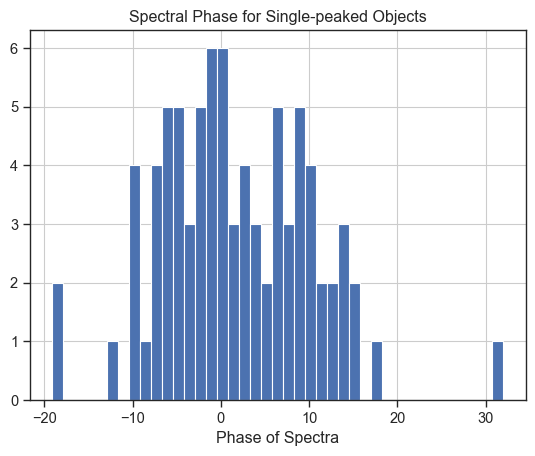

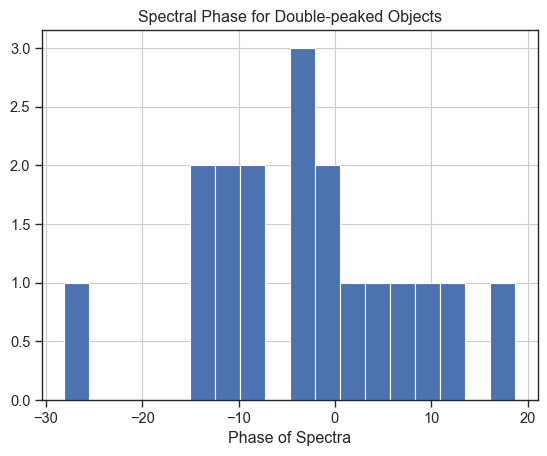

In [18]:
#investigating phase of spectra split between single and double-peaked obj

# want histogram of phase spread for single-peaked objs and histogram of phase spread for double-peaked objs
phase_single, phase_double = [],[]
for i,obj in enumerate(dataset['ztf_name'].unique()):
    if obj=='ZTF':
        print(f'No ZTF name, skipping {dataset.loc[dataset['ztf_name']=='ZTF', 'IAU name'].iloc[0]} for now...')
    else:
        data = dataset.loc[dataset['ztf_name']==obj]

        if data['double-peaked'].iloc[0] == 0: #single-peaked
            phase_single.append(data['Phase (days)'].iloc[0])
        else: 
            phase_double.append(data['Phase (days)'].iloc[0])

print('QUICK STATS for single-peaked:')
print(pd.Series(phase_single).describe())

print('QUICK STATS for double-peaked:')
print(pd.Series(phase_double).describe())

plt.figure()
plt.hist(phase_single, bins=int(len(phase_single)/2))
plt.xlabel('Phase of Spectra')
plt.title('Spectral Phase for Single-peaked Objects')

plt.figure()
plt.hist(phase_double, bins=len(phase_double))
plt.xlabel('Phase of Spectra')
plt.title('Spectral Phase for Double-peaked Objects')

In [ ]:
##### PRE PROCESS LIGHT CURVES ########

#maven needs light curves files w/ 4 columns: time,mag,magerr,band
#   where time is in mjd and filter is either g, R

# dropping bad obs
# centering LCs around date of first spectra (-50, +150 days)
# creating mag and mag_err cols
# dropping points w/ e_mag>2 mags
# creating mjd col

def create_ztf_lc_dfs(datadir, sn_type, check_names=False, save_df=True):
        files = sorted(glob.glob(datadir+'*_fp_lc.txt'))
        ztf_info_df = pd.read_csv(f'ztf_info_files/ztf_fp_info_for_{sn_type}.csv')

        if (sn_type == 'SN IIb') or (sn_type =='SN IIn') or (sn_type == 'SN Ibc'):
                startindx = 18
        elif (sn_type == 'SN Ic') or (sn_type =='SN Ib'):
                startindx = 17
        elif (sn_type == 'SLSN-I') or (sn_type == 'SN IbnIcn') or (sn_type == 'SN Ic-pec'):
                startindx = 20
        elif (sn_type == 'SLSN-II') or (sn_type =='SN Ibc Ca-rich'):
                startindx = 21
        # elif sn_type == 'FBOT':
        #         startindx = 19
        else:
                print(f'SN type {sn_type} unsupported or not in format SN XX / SLSN-XX')
                return

        sn_names, lc_dfs = [],[]
        for file in files:
                sn_name = file[startindx:-10] #NOTE: FIRST INDEX CHANGES W/ DATADIR NAME LENGTH
                if check_names:
                        print(sn_name)
                        continue
                
                sn_names.append(sn_name)

                cols = ['index', 'field', 'ccdid', 'qid', 'filter', 'pid', 'infobitssci', 'sciinpseeing', 'scibckgnd', 'scisigpix',
                        'zpmaginpsci', 'zpmaginpsciunc', 'zpmaginpscirms', 'clrcoeff', 'clrcoeffunc', 'ncalmatches', 'exptime',
                        'adpctdif1', 'adpctdif2', 'diffmaglim', 'zpdiff', 'programid', 'jd', 'rfid', 'forcediffimflux', 'forcediffimfluxunc',
                        'forcediffimsnr', 'forcediffimchisq', 'forcediffimfluxap', 'forcediffimfluxuncap', 'forcediffimsnrap', 'aperturecorr',
                        'dnearestrefsrc', 'nearestrefmag', 'nearestrefmagunc', 'nearestrefchi', 'nearestrefsharp', 'refjdstart', 'refjdend', 'procstatus']
                df = pd.read_csv(file, names=cols, header=None, sep=" ", skiprows=54)
                df = df.set_index(df['index'])  # manually setting indeces
                df = df.drop(columns=['index']) # drop duplicated index 
                df = df[(df['infobitssci'] < 33554432) & (df['scisigpix'] <= 25) & (df['sciinpseeing'] <= 4) & (df['forcediffimflux']!=-99999.0)].reset_index(drop=True) #clean according to docs

                # cut df down to -50 days to +150 (+365?) days centered on date of first spectra
                # time window included in ztf_fp_info*csv files for each obj type
                obj = ztf_info_df.loc[ztf_info_df['obj_name'].str[3:]==sn_name]
                start_jd = obj['jd_start'].iloc[0]
                end_jd = obj['jd_end'].iloc[0]
                df_cut = df.loc[(df['jd']<end_jd)&(df['jd']>start_jd)] #only selecting points that fall within specified time window
                df_cut = df_cut.reset_index(drop=True)
                df_cut = df_cut.infer_objects() #infering dtype of columns

                mag = df_cut['zpdiff'] - 2.5 * np.log10(df_cut['forcediffimflux'])
                sigma_mag = 1.0857 * df_cut['forcediffimfluxunc']/df_cut['forcediffimflux']
                df_cut['mag'] = mag
                df_cut['e_mag'] = sigma_mag
                df_cut = df_cut.loc[(df_cut['forcediffimflux']>0) & (df_cut['e_mag']<2)].reset_index(drop=True) #only selecting points w/ non-nan mags and errorbars less than 2 mags
                df_cut['mjd'] = df_cut['jd']-2400000.5

                # saving LC in maven-friendly format w/ ZTF name as file name
                # if obj has no ZTF internal name, saved w/ IAU name and will need to look up personally 
                #       and update the metadata
                if save_df:
                        if 'SN '+sn_name in dataset['IAU name'].to_list(): #only converting objs in our "good" sample
                                smol_df = df_cut[['mjd', 'mag', 'e_mag', 'filter']]
                                smol_df = smol_df.rename(columns={"mjd": "time", "e_mag": "magerr", "filter":"band"})
                                smol_df.loc[smol_df['band']=='ZTF_g', 'band'] = 'g'
                                smol_df.loc[smol_df['band']=='ZTF_r', 'band'] = 'R'
                                smol_df = smol_df.loc[~(smol_df['band']=='ZTF_i')] #removing iband data

                                no_spec = len(dataset.loc[dataset['IAU name']=='SN '+sn_name, :])
                                ztf_name = dataset.loc[dataset['IAU name']=='SN '+sn_name, 'ztf_name'].iloc[0]
                                if len(ztf_name)<4:
                                        print(f'WARNING: SN {sn_name} has no ZTF name; ignoring for maven')
                                        # smol_df.to_csv(f'maven_data/lightcurves/SN{sn_name}.csv',index=False,header=False)
                                else:
                                        for i in range(no_spec):
                                                smol_df.to_csv(f'maven_data/lightcurves/{ztf_name}_{i}.csv',index=False) 
                                                #^copies a LC file the number of times we have a spectra to match maven's expected file naming conventions                                                            

                lc_dfs.append(df_cut)

        return sn_names, lc_dfs

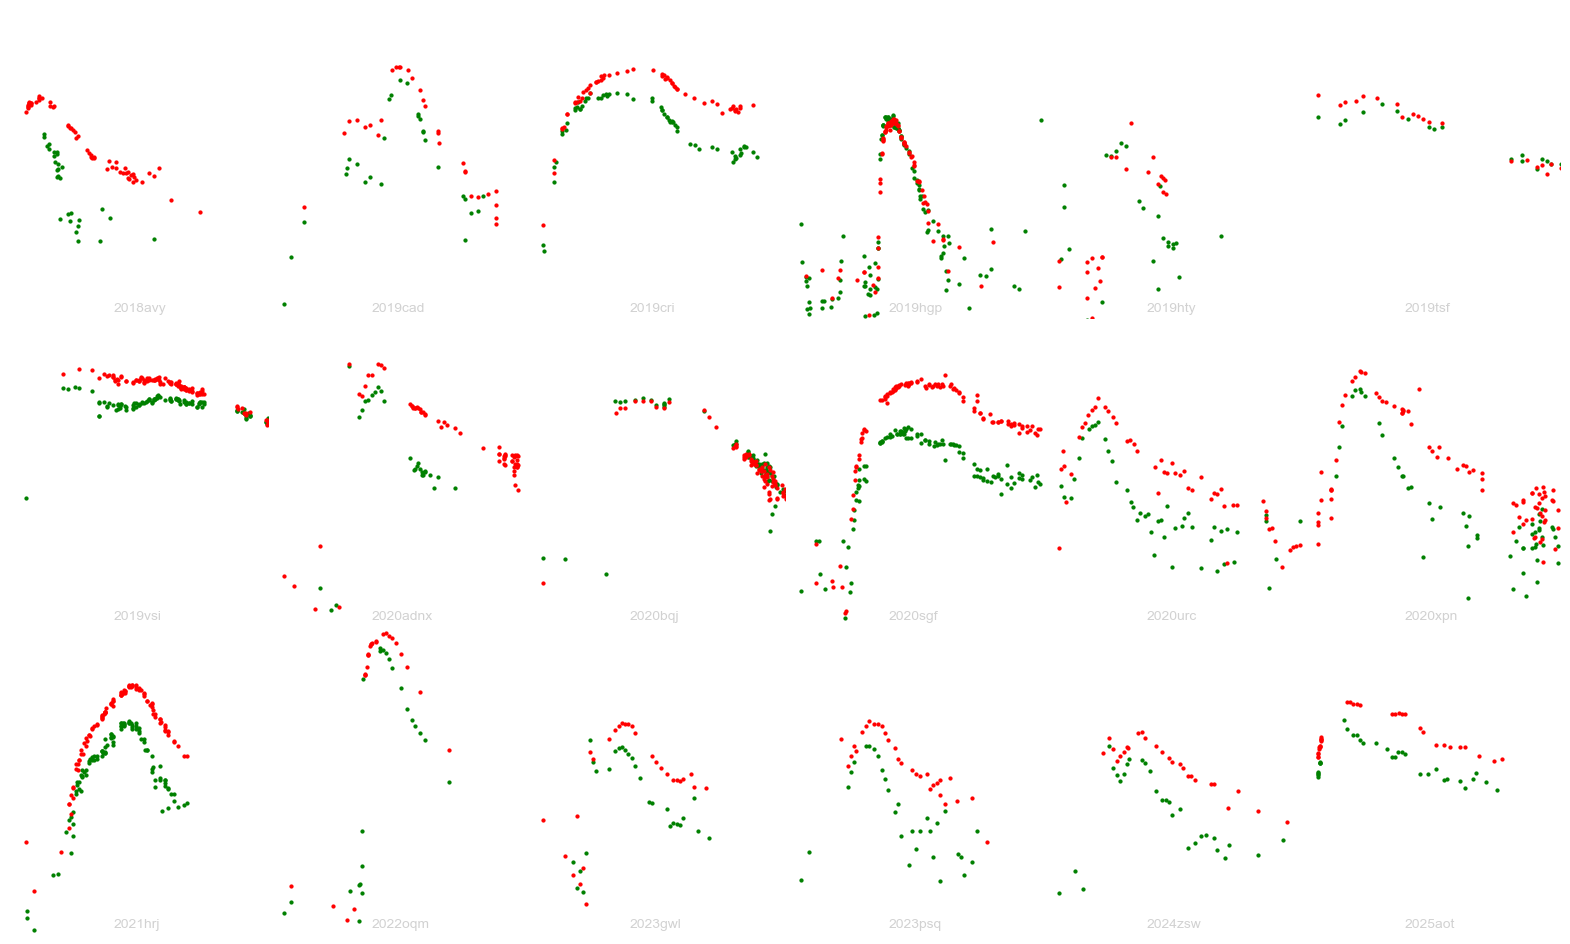

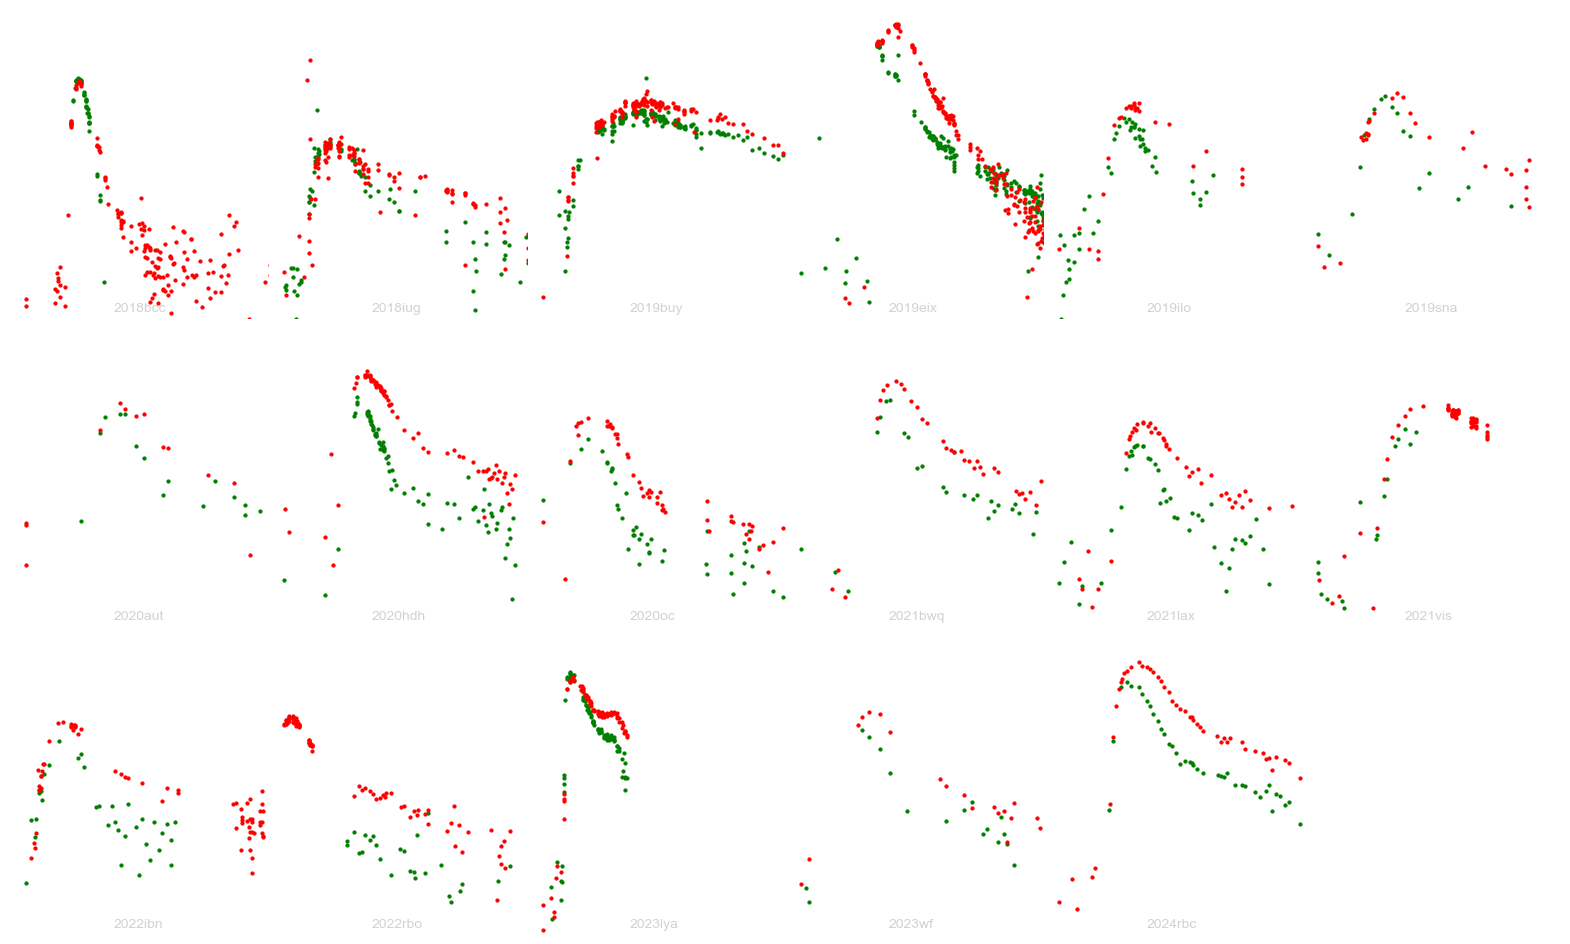

In [ ]:
dp = (dataset['double-peaked']==1)
sp = ~dp

# lc_files = glob.glob('./maven_data/lightcurves/*_0.csv')
# files_ztf = [file[25:-6] for file in lc_files]

sp_objs = dataset.loc[sp, 'ztf_name'].drop_duplicates()
dp_objs = dataset.loc[dp, 'ztf_name'].drop_duplicates()

x = range(3)
y = range(6)
axes = list(itertools.product(x, y))
axes = [list(item) for item in axes]

# plot for double peaked objects
fig, axs = plt.subplots(3, 6, figsize=(20, 12))
for i, ztf in enumerate(dp_objs):
    iau = dataset.loc[dataset['ztf_name']==ztf, 'IAU name'].iloc[0][3:]
    lc_df = pd.read_csv(f'./maven_data/lightcurves/{ztf}_0.csv')

    g = (lc_df['band']=='g')
    r = (lc_df['band']=='R')
    
    x,y = axes[i][0], axes[i][1]
    xplotg, yplotg = lc_df.loc[g, 'time'], lc_df.loc[g, 'mag']
    xplotr, yplotr = lc_df.loc[r, 'time'], lc_df.loc[r, 'mag']

    axs[x,y].scatter(xplotg, yplotg, color='green', s=5)
    axs[x,y].scatter(xplotr, yplotr, color='red', s=5)
    axs[x,y].annotate(iau,xy=(0.4,0.02),xycoords='axes fraction',color='dimgray',fontsize=10, alpha=0.3)
    # axs[x,y].invert_yaxis()
    axs[x,y].grid(False)
    axs[x,y].set_xlim(min(min(xplotg), min(xplotr))-10, min(min(xplotg), min(xplotr))+150)
    axs[x,y].set_ylim(23.5, 16)
    axs[x,y].tick_params(axis='both', which='both', bottom=False, top=False, left=False, right=False, labelbottom=False, labelleft=False)
    axs[x,y].axis('off')
plt.subplots_adjust(wspace=0, hspace=0)
plt.savefig('./figures/double-peaked-lcs-small_multiples-unlabeled.png', dpi=300)

# same but for random 18 single peaked objects
x = range(3)
y = range(6)
axes = list(itertools.product(x, y))
axes = [list(item) for item in axes]

# plot for double peaked objects
fig, axs = plt.subplots(3, 6, figsize=(20, 12))
for i, ztf in enumerate(sp_objs[::5]):
    iau = dataset.loc[dataset['ztf_name']==ztf, 'IAU name'].iloc[0][3:]
    lc_df = pd.read_csv(f'./maven_data/lightcurves/{ztf}_0.csv')

    g = (lc_df['band']=='g')
    r = (lc_df['band']=='R')
    
    x,y = axes[i][0], axes[i][1]
    xplotg, yplotg = lc_df.loc[g, 'time'], lc_df.loc[g, 'mag']
    xplotr, yplotr = lc_df.loc[r, 'time'], lc_df.loc[r, 'mag']

    axs[x,y].scatter(xplotg, yplotg, color='green', s=5)
    axs[x,y].scatter(xplotr, yplotr, color='red', s=5)
    axs[x,y].annotate(iau,xy=(0.4,0.02),xycoords='axes fraction',color='dimgray',fontsize=10, alpha=0.3)
    # axs[x,y].invert_yaxis()
    axs[x,y].grid(False)
    axs[x,y].set_xlim(min(min(xplotg), min(xplotr))-10, min(min(xplotg), min(xplotr))+150)
    axs[x,y].set_ylim(23.5, 16)
    axs[x,y].tick_params(axis='both', which='both', bottom=False, top=False, left=False, right=False, labelbottom=False, labelleft=False)
    axs[x,y].axis('off')
axs[2,5].axis('off')
plt.subplots_adjust(wspace=0, hspace=0)
plt.savefig('./figures/single-peaked-lcs-small_multiples-unlabeled.png', dpi=300)

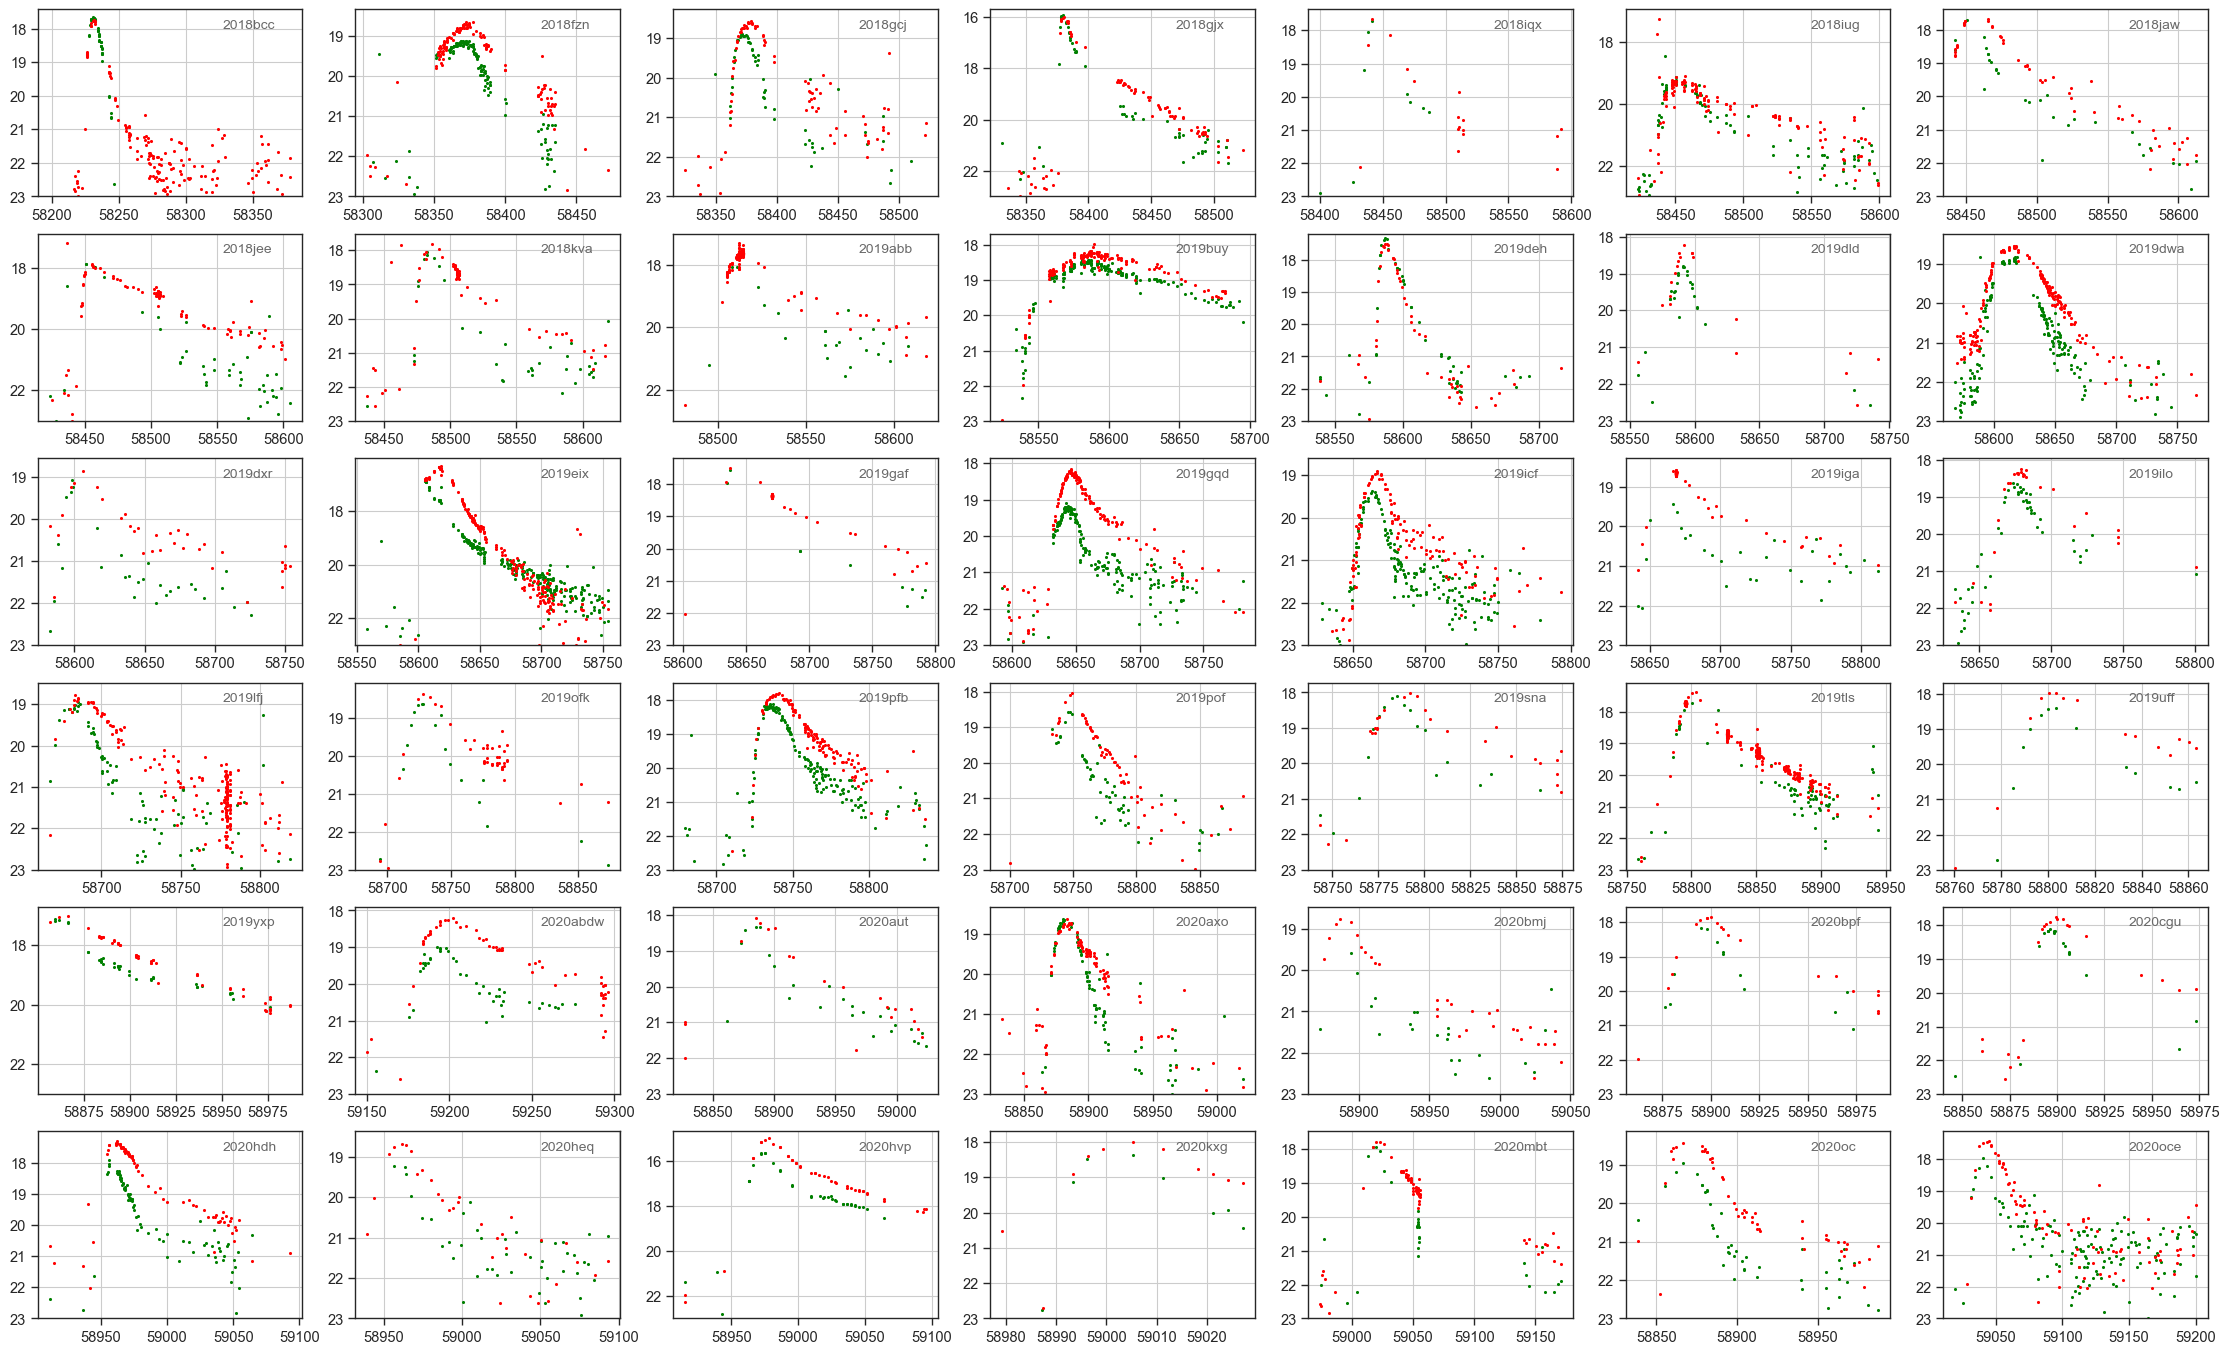

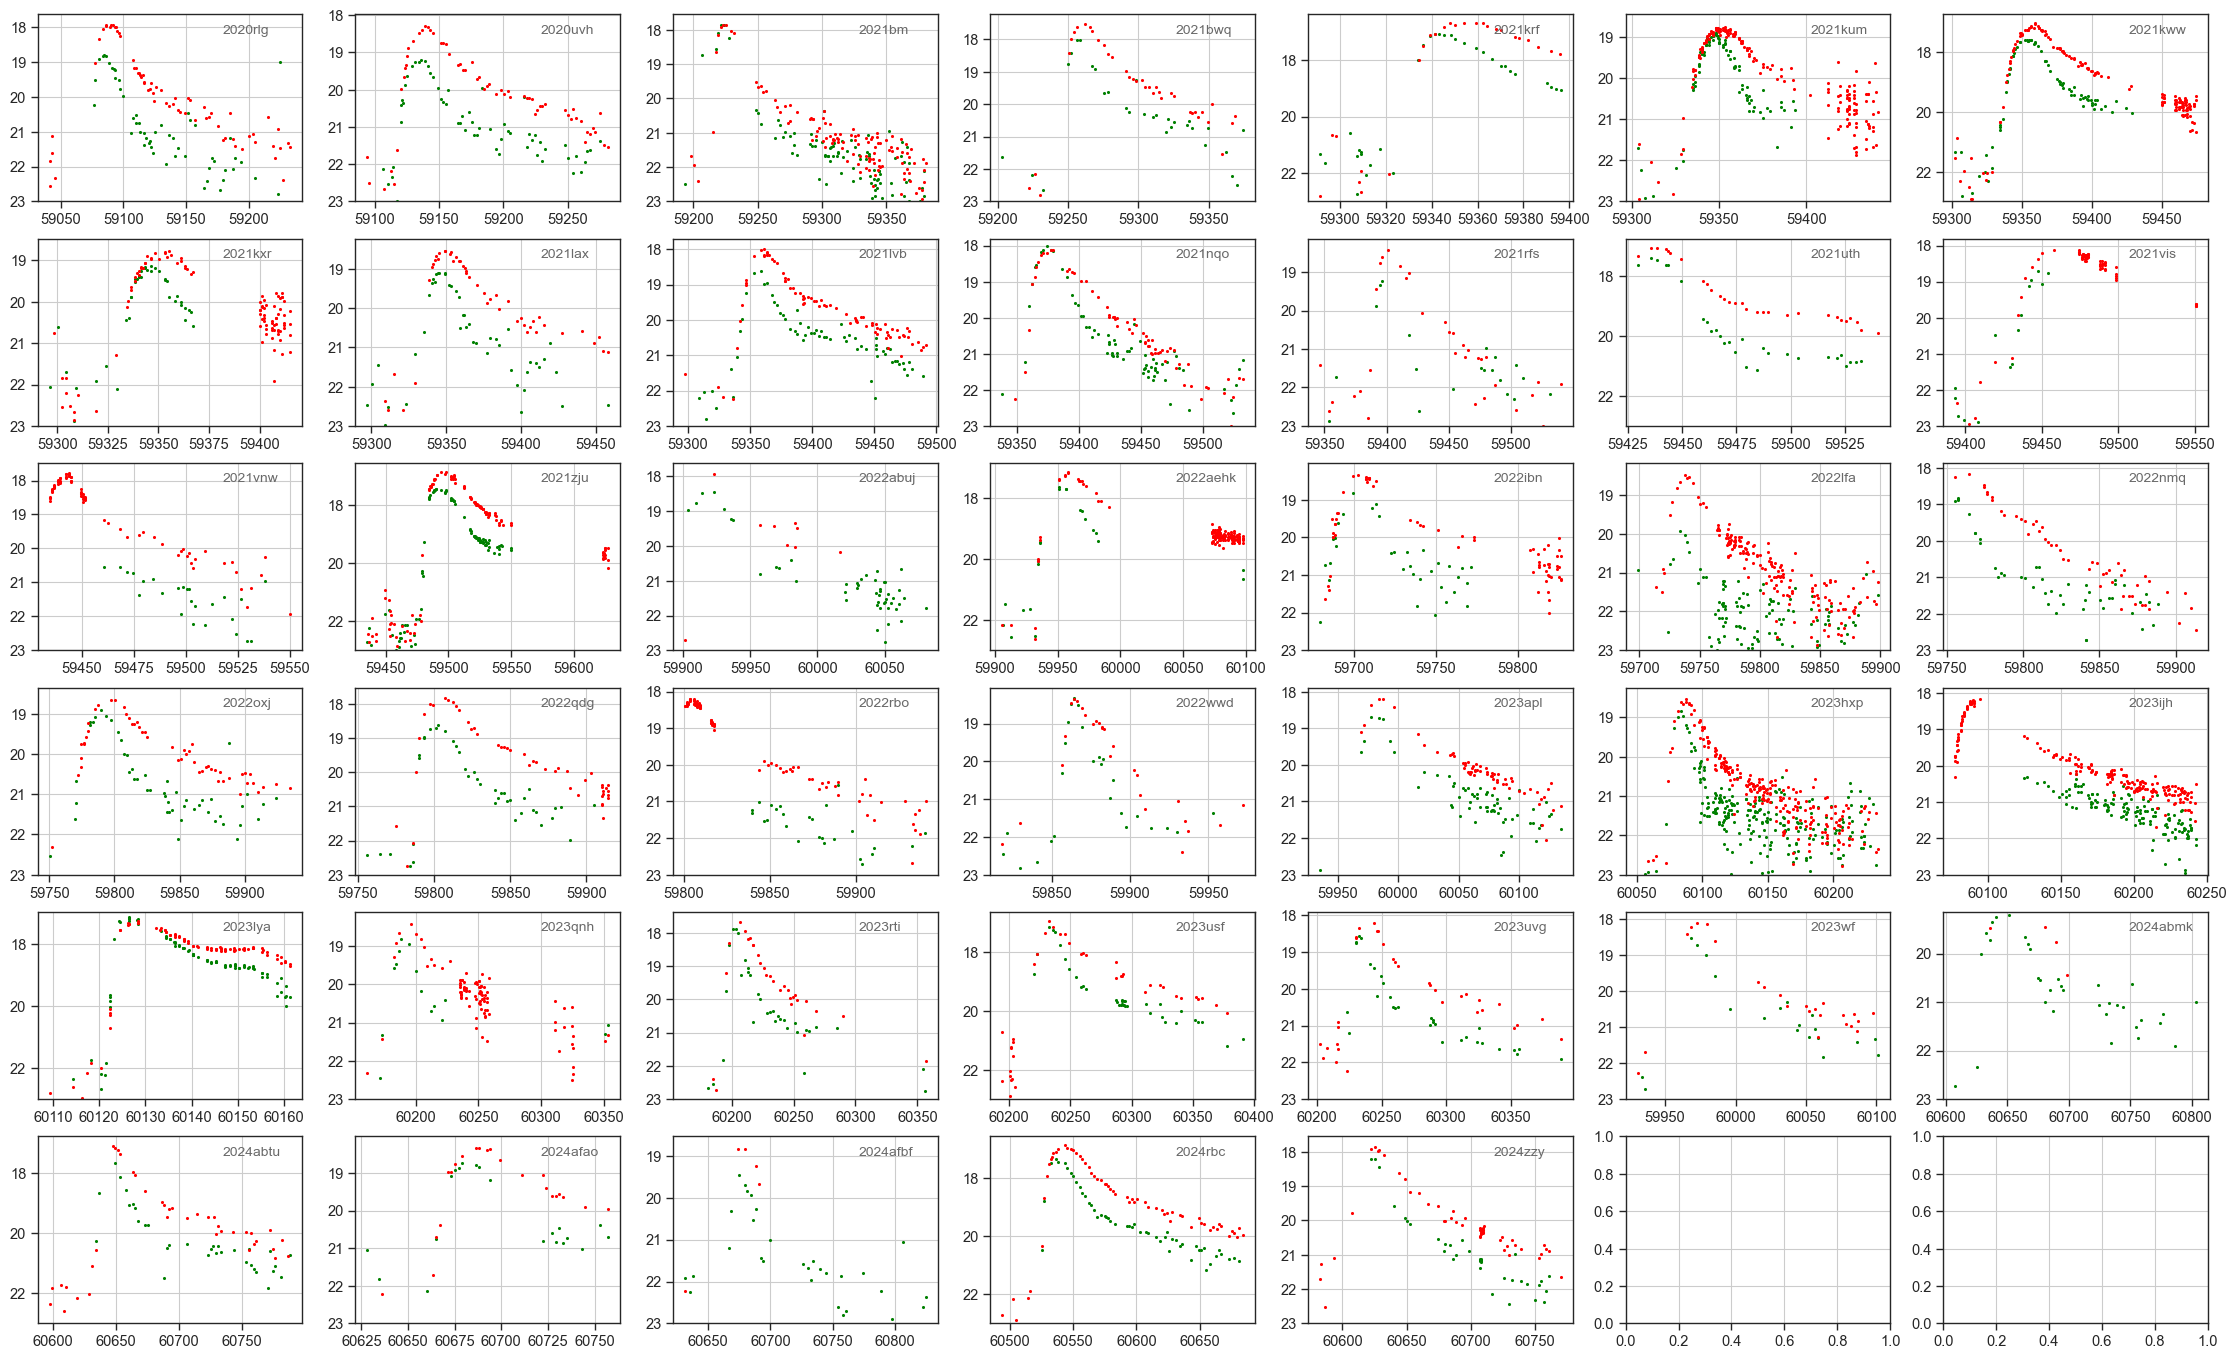

In [ ]:
# make same plot but for single peaked

x = range(6)
y = range(7)
axes = list(itertools.product(x, y))
axes = [list(item) for item in axes]

fig, axs = plt.subplots(6, 7, figsize=(28, 17))
for i, ztf in enumerate(sp_objs[:42]):
    iau = dataset.loc[dataset['ztf_name']==ztf, 'IAU name'].iloc[0][3:]
    lc_df = pd.read_csv(f'./maven_data/lightcurves/{ztf}_0.csv')

    g = (lc_df['band']=='g')
    r = (lc_df['band']=='R')
    
    x,y = axes[i][0], axes[i][1]
    xplotg, yplotg = lc_df.loc[g, 'time'], lc_df.loc[g, 'mag']
    xplotr, yplotr = lc_df.loc[r, 'time'], lc_df.loc[r, 'mag']

    axs[x,y].scatter(xplotg, yplotg, color='green', s=2)
    axs[x,y].scatter(xplotr, yplotr, color='red', s=2)
    axs[x,y].set_ylim(min(lc_df.loc[r, 'mag'])-0.3, 23)
    axs[x,y].annotate(iau,xy=(0.7,0.9),xycoords='axes fraction',color='dimgray',fontsize=10,)
    # axs[x,y].invert_yaxis()
    axs[x,y].grid(False)
    axs[x,y].set_xlim(min(min(xplotg), min(xplotr))-10, min(min(xplotg), min(xplotr))+150)
    axs[x,y].set_ylim(23.5, 16)
    axs[x,y].tick_params(axis='both', which='both', bottom=False, top=False, left=False, right=False, labelbottom=False, labelleft=False)
    axs[x,y].axis('off')
plt.subplots_adjust(wspace=0, hspace=0)
plt.savefig('./figures/single-peaked-lcs-bothbands-labeled-part1.png', dpi=300)

fig, axs = plt.subplots(6, 7, figsize=(28, 17))
for i, ztf in enumerate(sp_objs[42:]):
    iau = dataset.loc[dataset['ztf_name']==ztf, 'IAU name'].iloc[0][3:]
    lc_df = pd.read_csv(f'./maven_data/lightcurves/{ztf}_0.csv')

    g = (lc_df['band']=='g')
    r = (lc_df['band']=='R')
    
    x,y = axes[i][0], axes[i][1]
    xplotg, yplotg = lc_df.loc[g, 'time'], lc_df.loc[g, 'mag']
    xplotr, yplotr = lc_df.loc[r, 'time'], lc_df.loc[r, 'mag']

    axs[x,y].scatter(xplotg, yplotg, color='green', s=2)
    axs[x,y].scatter(xplotr, yplotr, color='red', s=2)
    axs[x,y].set_ylim(min(lc_df.loc[r, 'mag'])-0.3, 23)
    axs[x,y].annotate(iau,xy=(0.7,0.9),xycoords='axes fraction',color='dimgray',fontsize=10,)
    # axs[x,y].invert_yaxis()
    axs[x,y].grid(False)
    axs[x,y].set_xlim(min(min(xplotg), min(xplotr))-10, min(min(xplotg), min(xplotr))+150)
    axs[x,y].set_ylim(23.5, 16)
    axs[x,y].tick_params(axis='both', which='both', bottom=False, top=False, left=False, right=False, labelbottom=False, labelleft=False)
    axs[x,y].axis('off')
plt.subplots_adjust(wspace=0, hspace=0)
plt.savefig('./figures/single-peaked-lcs-bothbands-labeled-part2.png', dpi=300)

In [17]:
sn_names_ib, lc_dfs_ib = create_ztf_lc_dfs('./ztf_fp_data/ib/','SN Ib')
sn_names_ic, lc_dfs_ic = create_ztf_lc_dfs('./ztf_fp_data/ic/','SN Ic')
sn_names_iib, lc_dfs_iib = create_ztf_lc_dfs('./ztf_fp_data/iib/','SN IIb', check_names=False, save_df=True)
sn_names_carich, lc_dfs_carich = create_ztf_lc_dfs('./ztf_fp_data/carich/','SN Ibc Ca-rich', check_names=False)
sn_names_ibc, lc_dfs_ibc = create_ztf_lc_dfs('./ztf_fp_data/ibc/','SN Ibc', check_names=False)
sn_names_ibncn, lc_dfs_ibncn = create_ztf_lc_dfs('./ztf_fp_data/ibncn/','SN IbnIcn', check_names=False)
sn_names_icpec, lc_dfs_icpec = create_ztf_lc_dfs('./ztf_fp_data/icpec/','SN Ic-pec', check_names=False)

/Users/pnr5sh/miniconda3/envs/astro2/lib/python3.13/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/Users/pnr5sh/miniconda3/envs/astro2/lib/python3.13/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/Users/pnr5sh/miniconda3/envs/astro2/lib/python3.13/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/Users/pnr5sh/miniconda3/envs/astro2/lib/python3.13/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/Users/pnr5sh/miniconda3/envs/astro2/lib/python3.13/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [42]:
##### PRE PROCESS SPECTRA ########

# def get_list_of_spec_files(spec_dir, sn_type):
#     """
#     sn_type needs to be in "SN XX" format
#     """
#     # only want to preproc spectra for objs in our good sample, which are denoted by those in dataset df
#     raw_spec_file_names = glob.glob(f'./wiserep_spectra/{spec_dir}/spectra/*')
#     sntype = (dataset['Obj. Type']==sn_type)

#     iau_str = dataset.loc[sntype, 'IAU name'].unique()
#     ztf_str = dataset.loc[sntype, 'ztf_name'].unique()

#     #generating list of 3 potential strings that spectra file could use for each obj
#     # wiserep names are either XXXXabc, SNXXXXabc, or ZTFabcdefg
#     potential_names = []
#     for i,iauname in enumerate(iau_str):
#         sniau = iauname[0:2]+iauname[3:]
#         iau = iauname[3:]
#         ztf = ztf_str[i]
#         potential_names.append([sniau, iau, ztf])

#     #check each spectra file to see if matches any of the 3 strs of our target objs
#     #appending each spectrum to list for each obj name, then appending all objs to 1 list
#     spectra_files_for_type, ztf_names_ordered = [],[]
#     for i,name in enumerate(potential_names):
#         sfiles = []
#         znames = []
#         for j,file in enumerate(raw_spec_file_names):
#             if any(n in file for n in name):
#                 sfiles.append(file)
#                 znames.append(name[2])
#         spectra_files_for_type.append(sfiles)
#         ztf_names_ordered.append(znames)
    
#     return spectra_files_for_type, ztf_names_ordered

def get_list_of_spec_files(spec_dir, sn_type):
    ztf_names_ordered = dataset.loc[dataset['Obj. Type']==sn_type, 'ztf_name'].unique()
    
    sn_ascii_files_all = []
    for i,ztf in enumerate(ztf_names_ordered):
        sn_ascii_files = dataset.loc[(dataset['Obj. Type']==sn_type)&(dataset['ztf_name']==ztf), 'Ascii file'].to_numpy()
        full_path = f'/Users/pnr5sh/Documents/phd/mmmp/adrian/wiserep_spectra/{spec_dir}/spectra/'+sn_ascii_files
        sn_ascii_files_all.append(full_path)

    return sn_ascii_files_all, ztf_names_ordered

header = ['wavelength', 'flux', 'fluxerr']
#each file has different number of header lines, creating function that ignores commented lines
headerstart = "#"
def skip_to(fle, headerstart, **kwargs):
    with open(fle) as f:
        pos = 0
        curline = f.readline()
        while curline.startswith(headerstart):
            pos = f.tell()
            curline = f.readline()
        f.seek(pos)
        return pd.read_csv(f, **kwargs)

In [43]:
class ProcessingTools(object):
    def redshift_spectrum(self, wave, flux, z):
        wave_new = wave * (z + 1)

        return wave_new, flux

    def deredshift_spectrum(self, wave, flux, z):
        wave_new = wave / (z + 1)

        return wave_new, flux

    def min_max_index(self, flux, outerVal=0):
        """ 
        :param flux: 
        :param outerVal: is the scalar value in all entries before the minimum and after the maximum index
        :return: 
        """
        nonZeros = np.where(flux != outerVal)[0]
        if nonZeros.size:
            minIndex, maxIndex = min(nonZeros), max(nonZeros)
        else:
            minIndex, maxIndex = len(flux), len(flux)

        return minIndex, maxIndex

class PreProcessSpectrum(object):
    def __init__(self, w0, w1, nw):
        self.w0 = w0
        self.w1 = w1
        self.nw = nw
        self.dwlog = np.log(w1 / w0) / nw
        self.processingTools = ProcessingTools()

    def log_wavelength(self, wave, flux):
        # Set up log wavelength array bins
        wlog = self.w0 * np.exp(np.arange(0, self.nw) * self.dwlog)

        fluxOut = self._vectorised_log_binning(wave, flux)
        # fluxOut = self._original_log_binning(wave, flux)

        minIndex, maxIndex = self.processingTools.min_max_index(fluxOut, outerVal=0)

        return wlog, fluxOut, minIndex, maxIndex

    def _vectorised_log_binning(self, wave, flux):
        """ Vectorised code version of the self._original_log_binning (for improved speed since this is the most called
        function in the script during training). This is complicated, but it has been tested to match the slower
        looping method """

        spec = np.array([wave, flux]).T
        mask = (wave >= self.w0) & (wave < self.w1)
        spec = spec[mask]
        wave, flux = spec.T
        try:
            fluxOut = np.zeros(int(self.nw))
            waveMiddle = wave[1:-1]
            waveTake1Index = wave[:-2]
            wavePlus1Index = wave[2:]
            s0List = 0.5 * (waveTake1Index + waveMiddle)
            s1List = 0.5 * (waveMiddle + wavePlus1Index)
            s0First = 0.5 * (3 * wave[0] - wave[1])
            s0Last = 0.5 * (wave[-2] + wave[-1])
            s1First = 0.5 * (wave[0] + wave[1])
            s1Last = 0.5 * (3 * wave[-1] - wave[-2])
            s0List = np.concatenate([[s0First], s0List, [s0Last]])
            s1List = np.concatenate([[s1First], s1List, [s1Last]])
            s0LogList = np.log(s0List / self.w0) / self.dwlog + 1
            s1LogList = np.log(s1List / self.w0) / self.dwlog + 1
            dnuList = s1List - s0List

            s0LogListInt = s0LogList.astype(int)
            s1LogListInt = s1LogList.astype(int)
            numOfJLoops = s1LogListInt - s0LogListInt
            jIndexes = np.flatnonzero(numOfJLoops)
            jIndexVals = s0LogListInt[jIndexes]
            prependZero = jIndexVals[0] if jIndexVals[0] < 0 else False
            if prependZero is not False:
                jIndexVals[0] = 0
                numOfJLoops[0] += prependZero
            numOfJLoops = (numOfJLoops[jIndexes])[jIndexVals < self.nw]
            fluxValList = ((flux * 1 / (s1LogList - s0LogList) * dnuList)[jIndexes])[jIndexVals < self.nw]
            fluxValList = np.repeat(fluxValList, numOfJLoops)
            minJ = min(jIndexVals)
            maxJ = (max(jIndexVals) + numOfJLoops[-1]) if (max(jIndexVals) + numOfJLoops[-1] < self.nw) else self.nw
            fluxOut[minJ:maxJ] = fluxValList[:(maxJ - minJ)]

            return fluxOut
        except Exception as e:
            print(e)
            print('wave', wave)
            print('flux', flux)
            print("########################################ERROR#######################################\n\n\n\n")
            return np.zeros(self.nw)

In [ ]:
def preproc_spectra4maven(spectrafiles, plot=False, save=False, ztfname='ZTF', savedir='./maven_data/spectra/',):
    """ 
    preprocess spectra according to MAVEN paper
    1) apply low pass median filter to smooth spectrum
    2) create log-spaced wavelength bins, bin the flux
    3) fit 13-point cubic spline, divide it from spectrum to correct for continuum
    
    Returns list of preproc'd spectra
    """
    no_spec = len(spectrafiles)

    preproc_spectra = []
    for i in range(no_spec):
        #read in spectrum as df
        #spectrafile = skip_to(spectrafiles[i], headerstart, header=None, names=header, delimiter=delimiter)
        spectrafile = ascii.read(spectrafiles[i]).to_pandas()
        if len(spectrafile.columns) == 2:
            spectrafile[3] = np.nan
        spectrafile.columns = header
        # print(spectrafile)

        # dropping any extra rows outside of SEDM range so every spectra same length
        wave = spectrafile.loc[(3776.0<=spectrafile['wavelength'])&(spectrafile['wavelength']<=9224.0), 'wavelength']
        flux = spectrafile.loc[(3776.0<=spectrafile['wavelength'])&(spectrafile['wavelength']<=9224.0), 'flux']
    
        w0 = min(wave)
        w1 = max(wave)
        nw = 213
        # print(f"min_wave={w0}, max_wave={w1}, wave-rows={len(wave)}")
        # print(len(wave), len(flux))

        #log-spacing wavelength w/ functions from DASH
        ztfspec_pre = PreProcessSpectrum(w0, w1, nw)
        wbins, fbins, _, _ = ztfspec_pre.log_wavelength(wave, flux)
        # wbins, fbins, _, _ = ztfspec_pre.log_wavelength(wave, smooth_spec)
        fbins = pd.Series(fbins)

        #OR gaussian filtering to estimate continuum
        continuum = gaussian_filter(fbins, sigma=30)
        cont_divid_flux = fbins / continuum
        
        #debug plots to check if cubicspline fit looks good
        plt.figure()
        plt.step(wbins, fbins, color='black', alpha=0.6)
        plt.plot(wbins, continuum, color='blue', alpha=1.0)
        plt.gca().grid(False)
        plt.title(f"{ztfname} continuum estimation")
        plt.show()
        
        #normalizing to be b/w 0-1
        norm_flux = (cont_divid_flux-min(cont_divid_flux)) / (max(cont_divid_flux)-min(cont_divid_flux))
        
        if plot:
            plt.figure()
            plt.step(wbins, norm_flux, color='k')
            # plt.plot(wbins, norm_flux, color='k')
            plt.title(f"preproc'd spectrum for {ztfname}. \n(Spectrum {i+1} of {no_spec})")
            plt.xlabel('Wavelength [$\AA$]')
            plt.gca().grid(False)
            plt.savefig(f"./temp/preproc_spec/{ztfname}_{i}.png", dpi=300)
            plt.show()
        
        #exporting binned, continuum-divided, normalized spectrum
        preproc_spectra.append([wbins, norm_flux])

        if save:
            #save just as ZTFname.csv with 2 or 3 columns: ["freq", "spec", "specerr"], where freq is actually lambda
            finalspec = pd.DataFrame(data={'freq':wbins, 'spec':norm_flux})
            finalspec.to_csv(f"{savedir}/{ztfname}_{i}.csv", index=False, header=False)
    
    return preproc_spectra

<>:58: SyntaxWarning: invalid escape sequence '\A'
<>:58: SyntaxWarning: invalid escape sequence '\A'
/var/folders/ql/0nrbq6jj6ks_2gbxfdznzzlc0000gp/T/ipykernel_35505/1809460006.py:58: SyntaxWarning: invalid escape sequence '\A'
  plt.xlabel('Wavelength [$\AA$]')


0 ZTF19aalouag


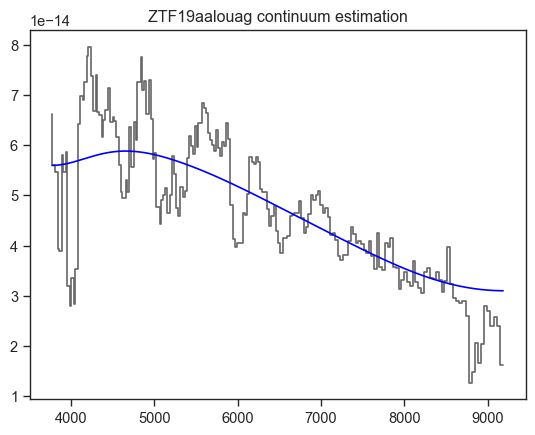

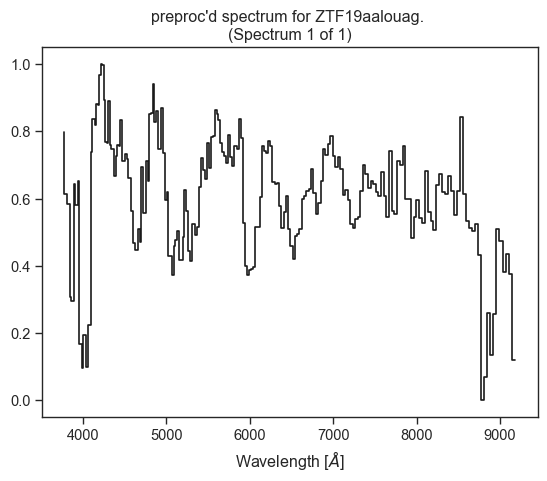

1 ZTF19aarnqys


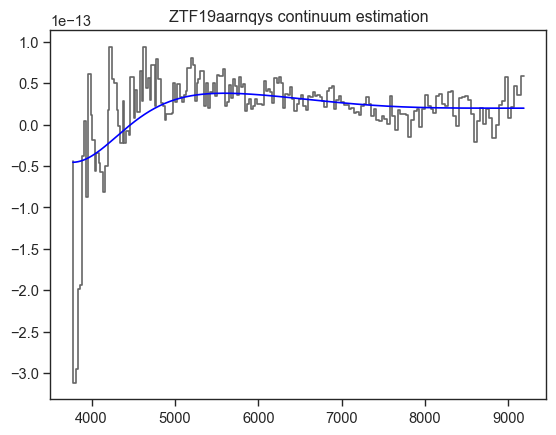

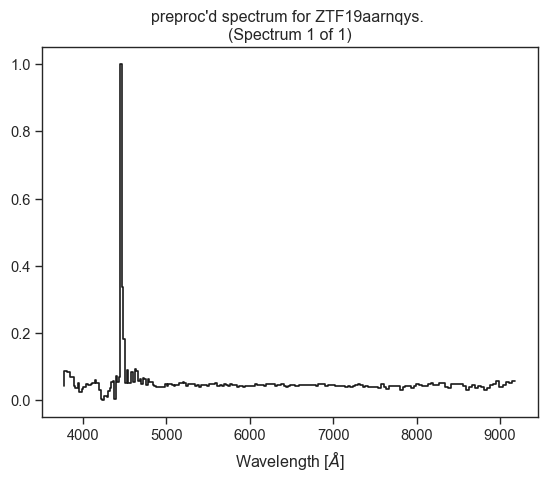

2 ZTF19abcyqqg


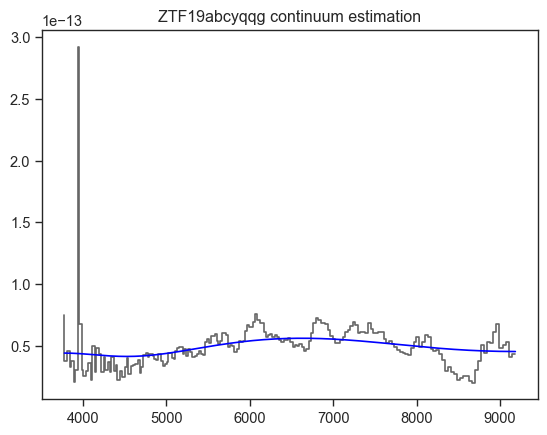

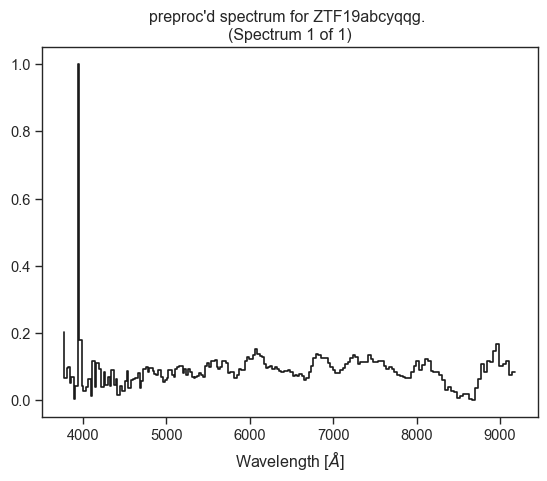

3 ZTF19abvdgqo


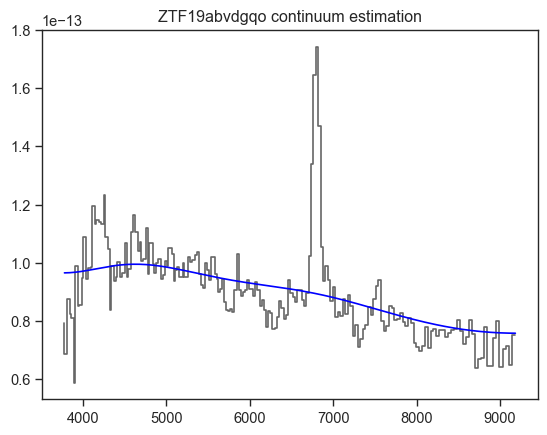

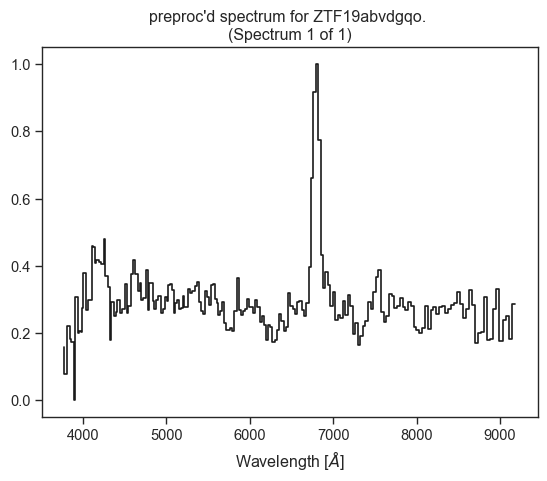

4 ZTF19ackjjwf


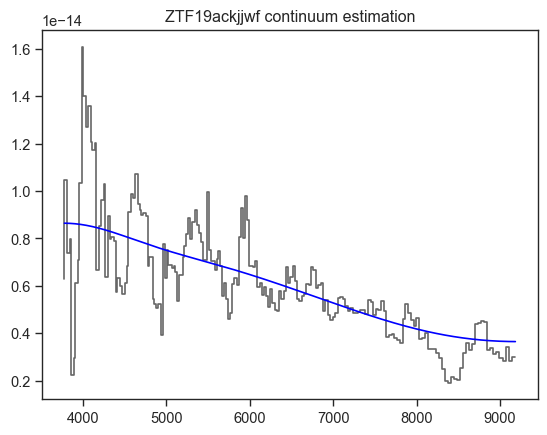

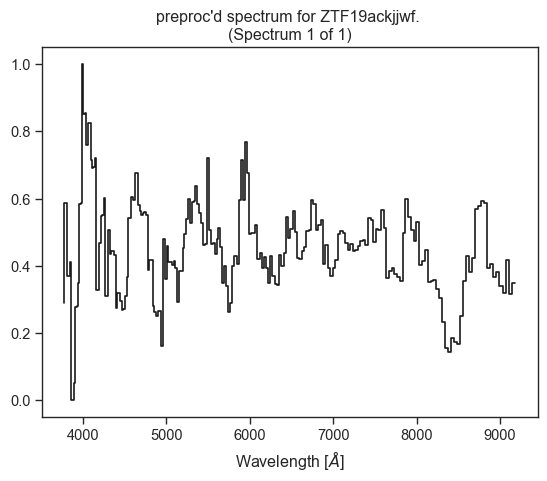

5 ZTF19ackjszs


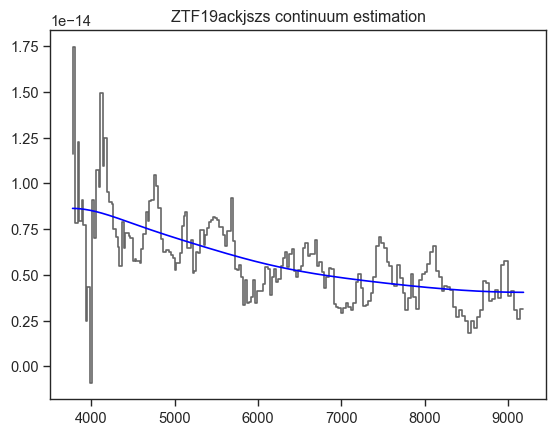

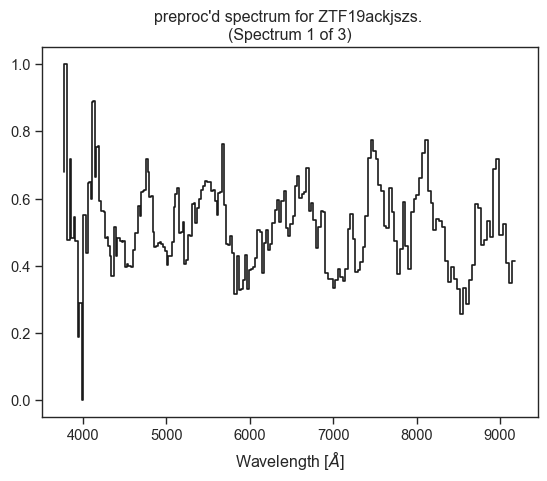

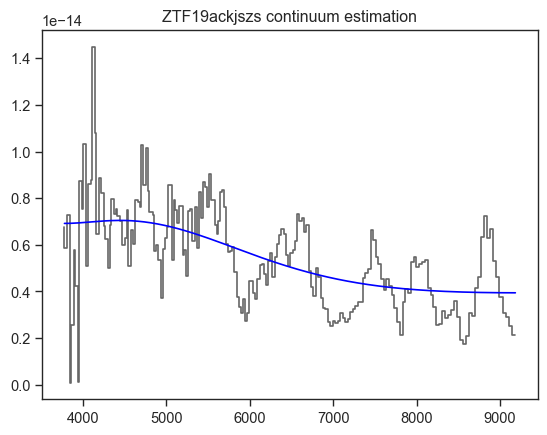

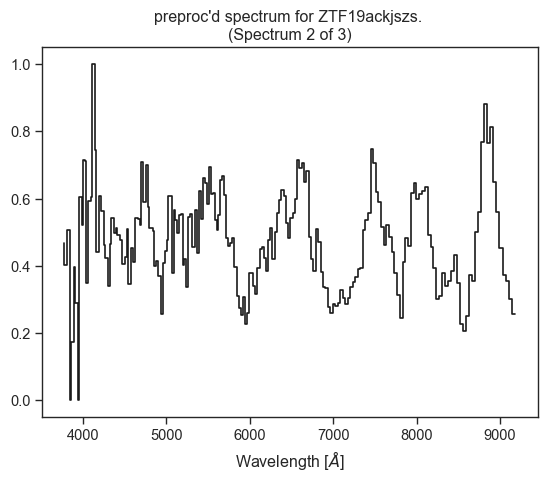

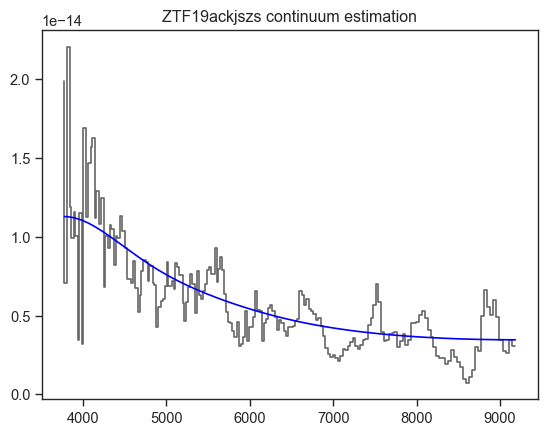

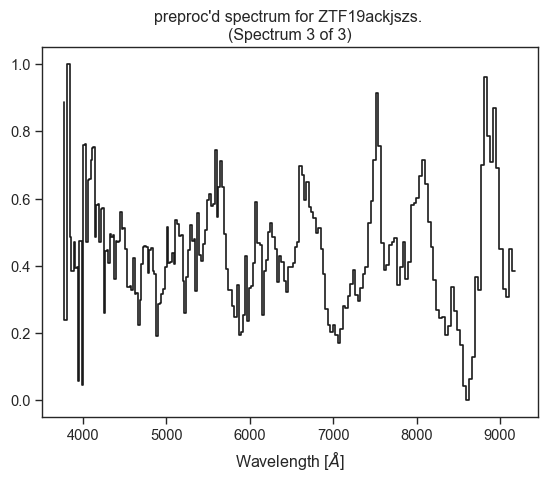

6 ZTF19acmelor


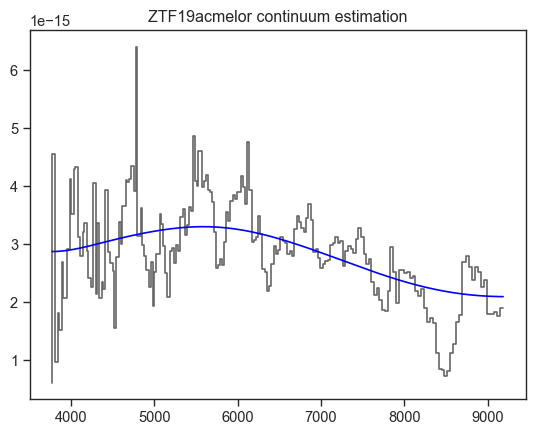

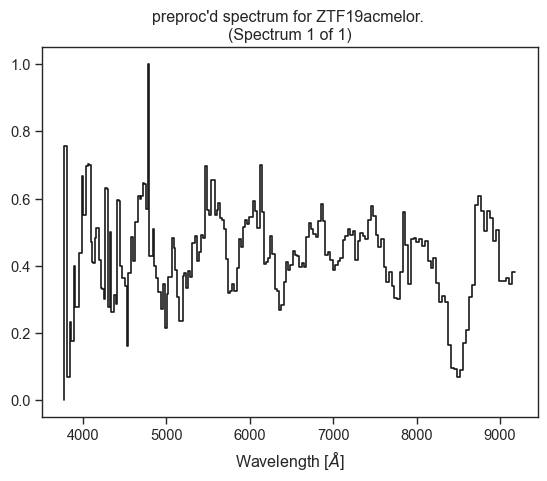

7 ZTF19acxpuql


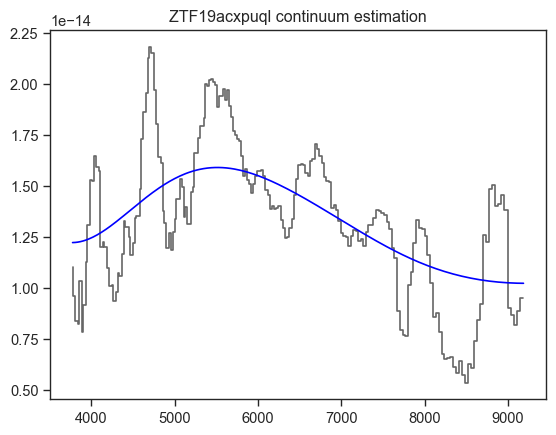

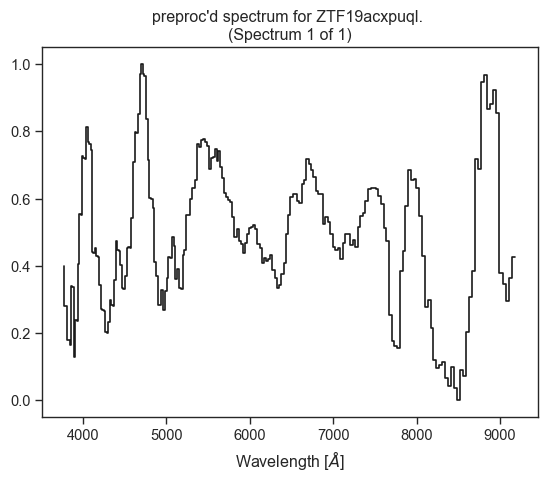

8 ZTF20aaerxne


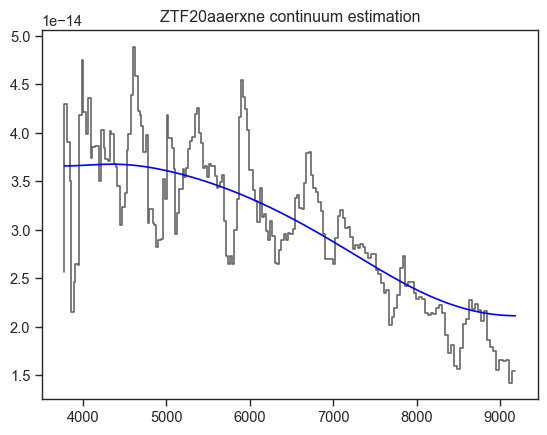

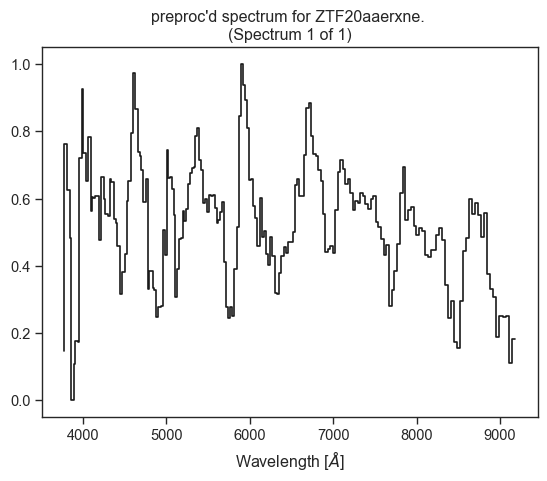

9 ZTF20aakodyh


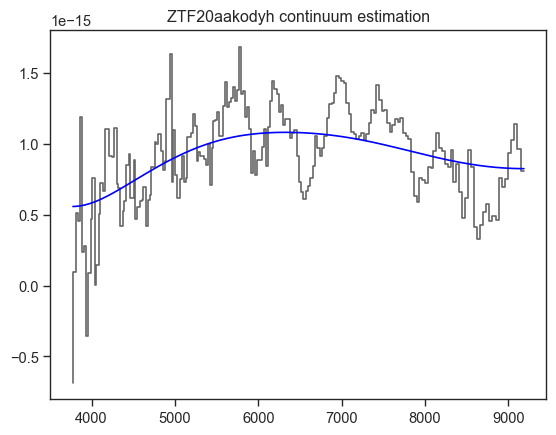

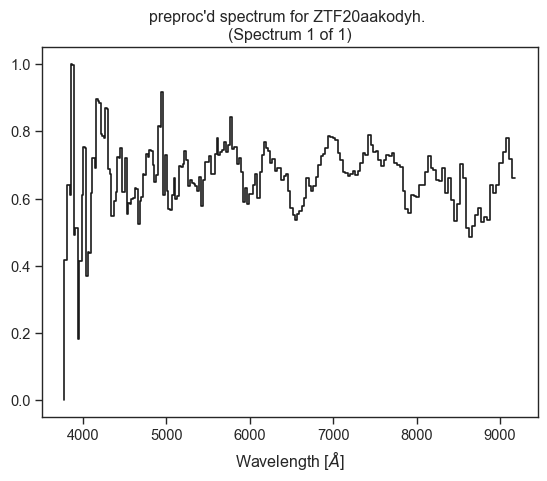

10 ZTF20aalcyih


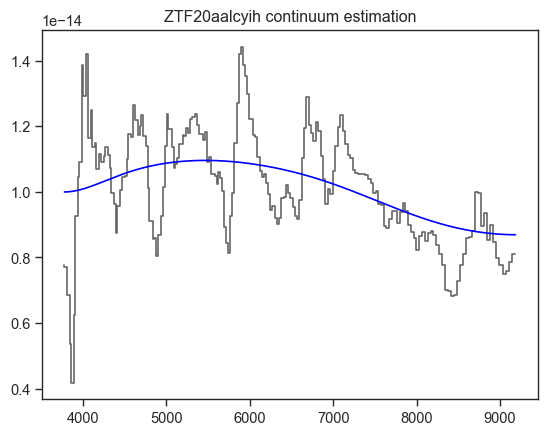

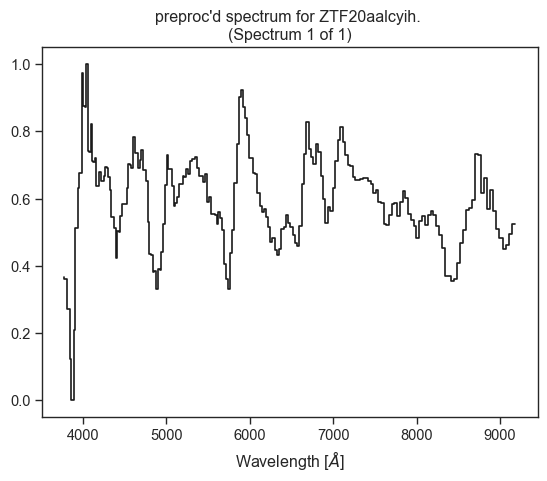

11 ZTF20aavzffg


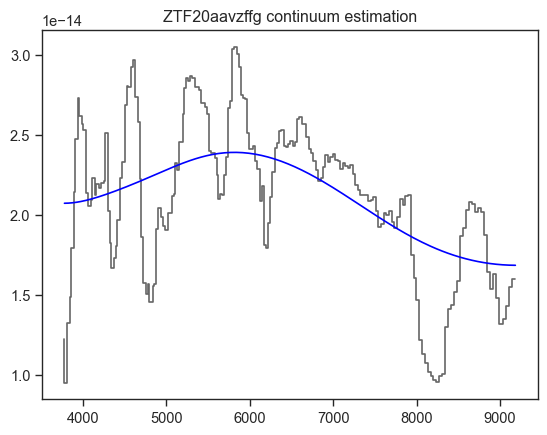

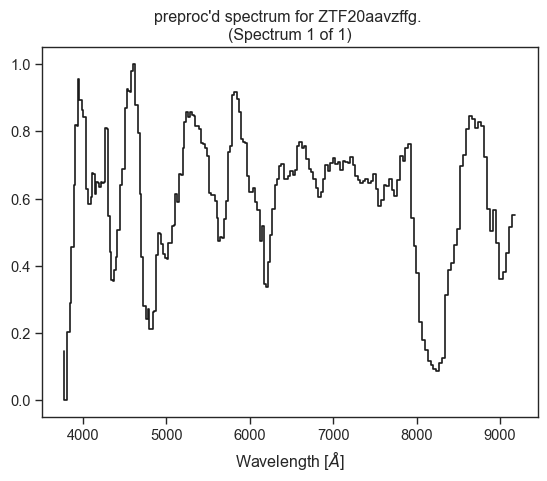

12 ZTF20abbhrrt


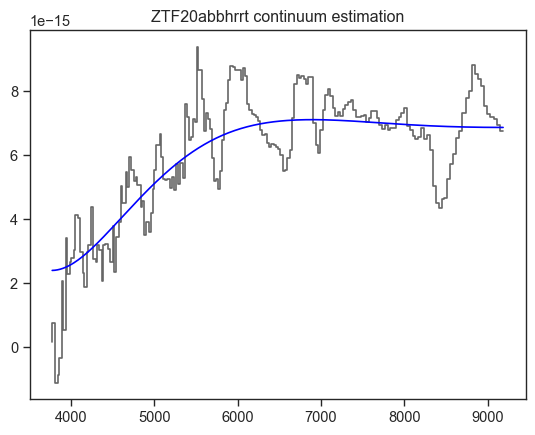

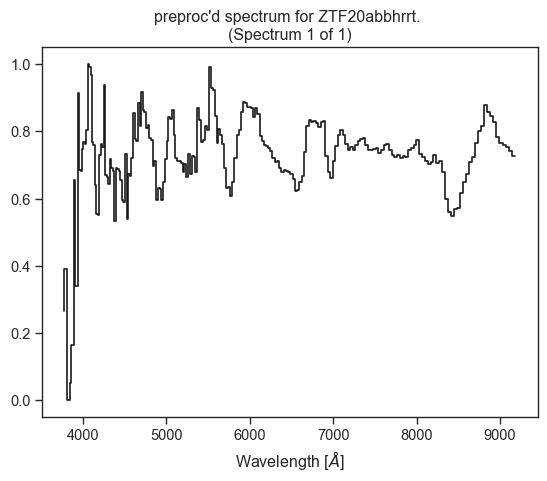

13 ZTF21aarnjyd


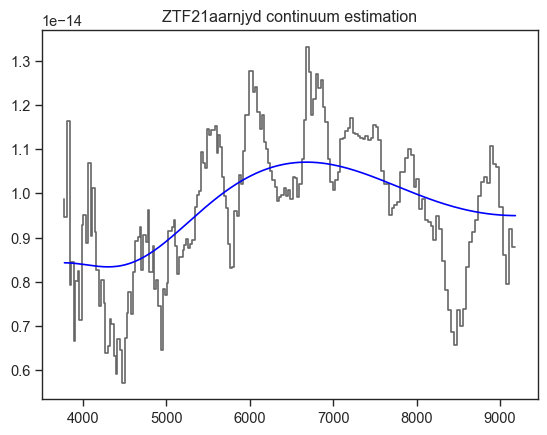

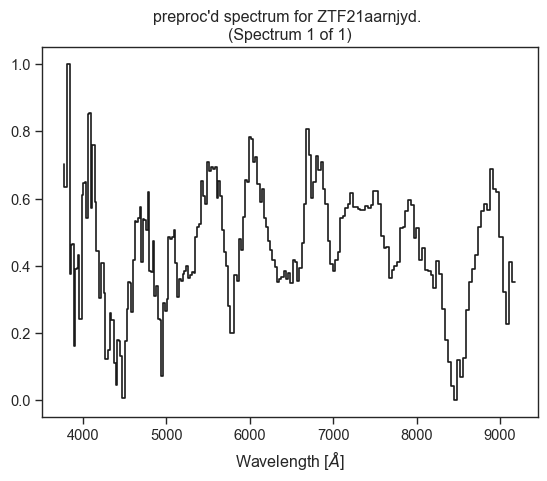

14 ZTF21aayddkn


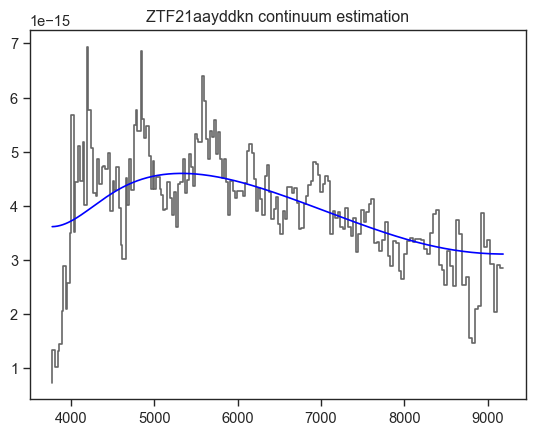

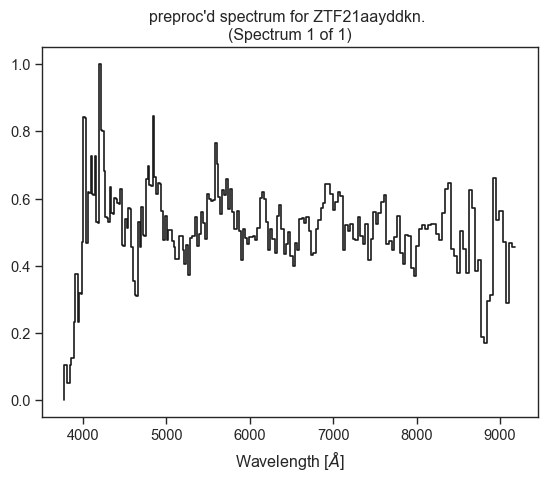

15 ZTF21aayqrgx


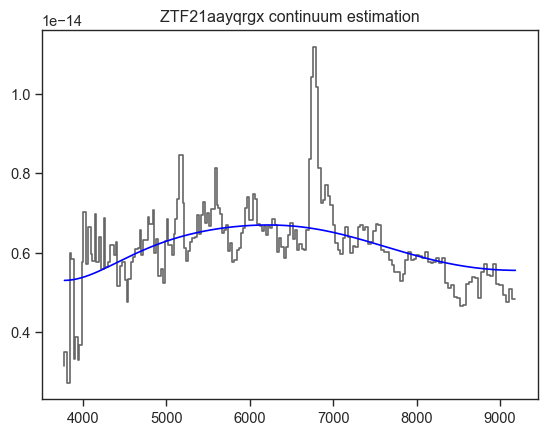

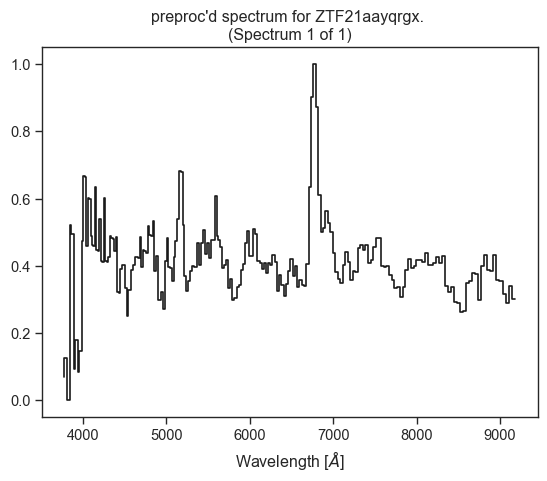

16 ZTF21abahiow


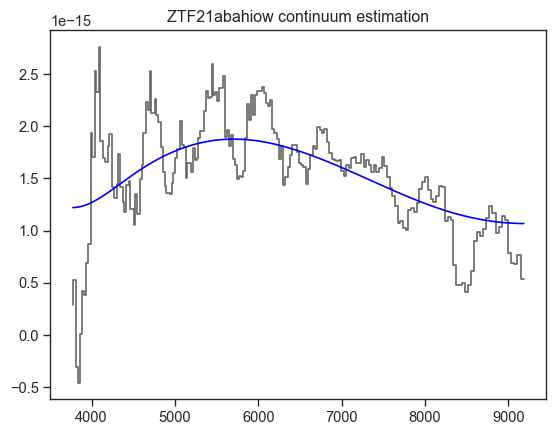

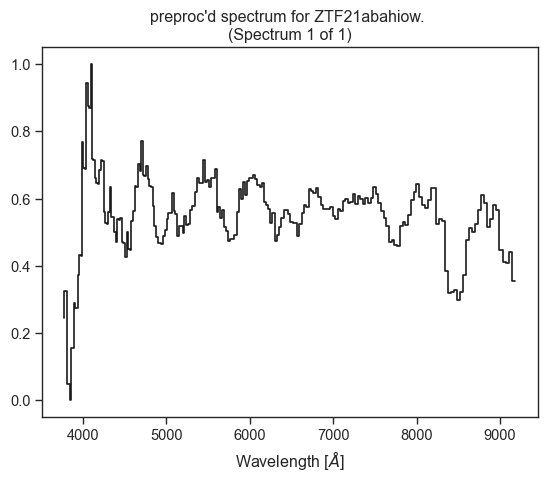

17 ZTF21abimeun


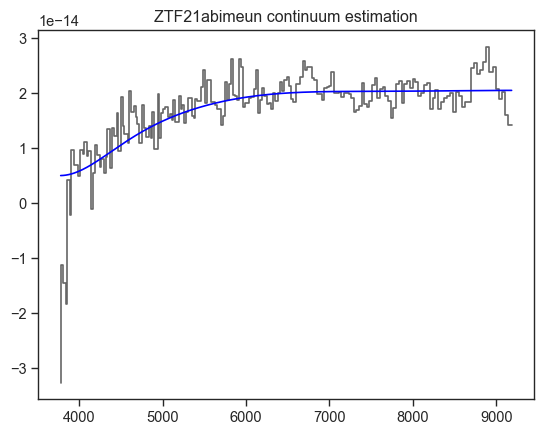

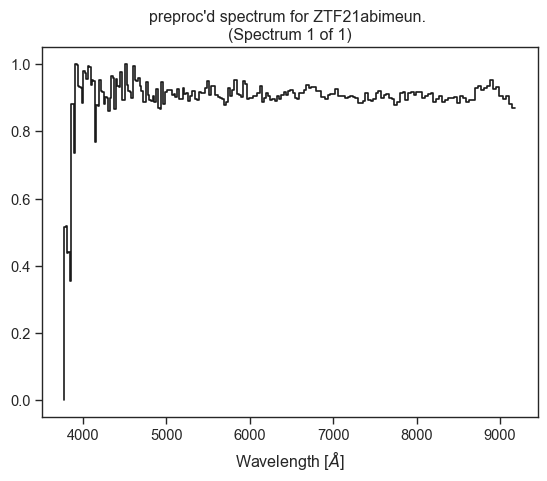

18 ZTF21abrqrsz


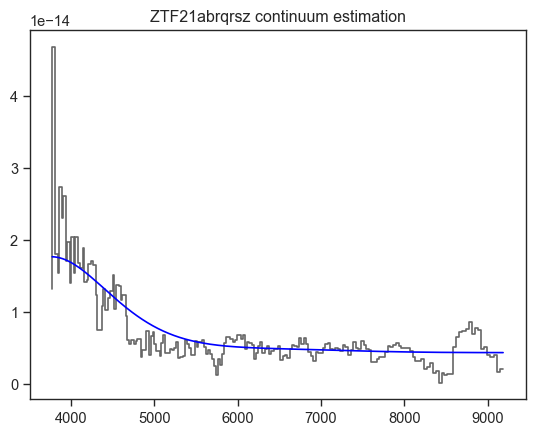

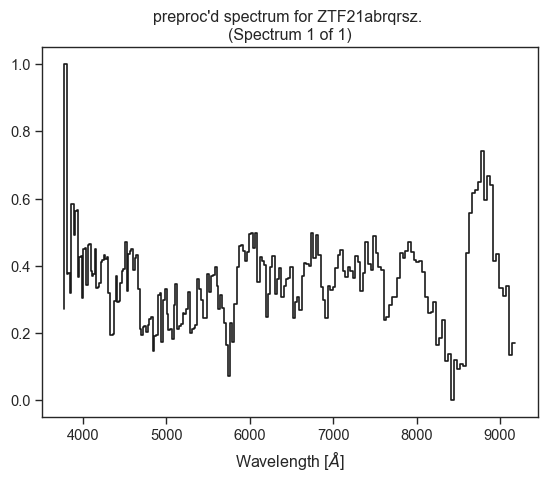

19 ZTF21acdxhuv


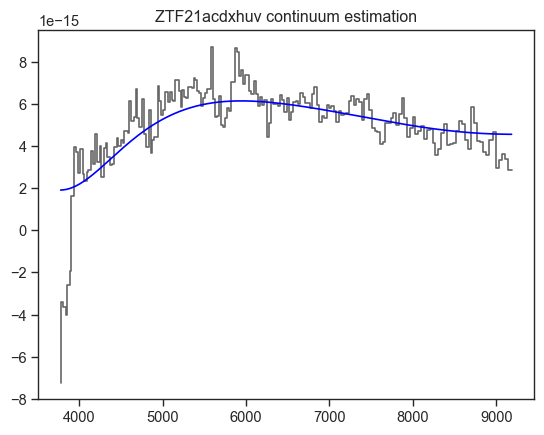

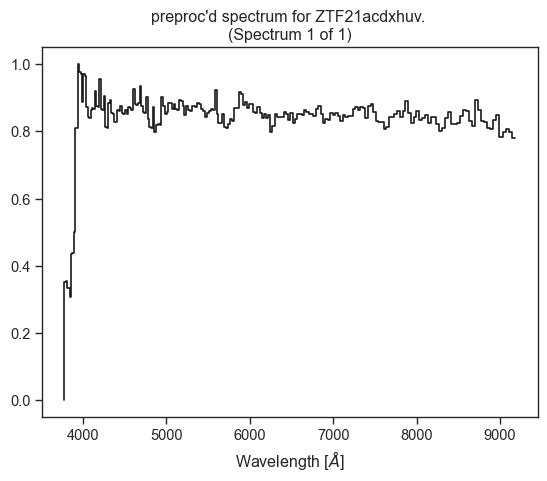

20 ZTF22aatunnt


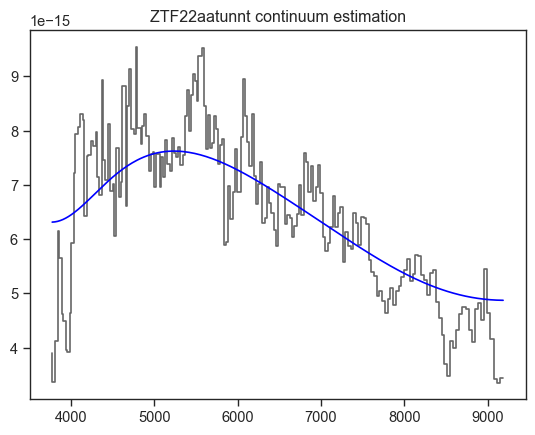

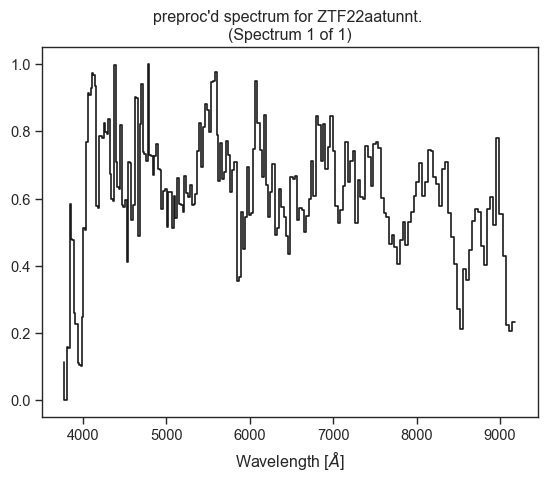

21 ZTF22aazqoey


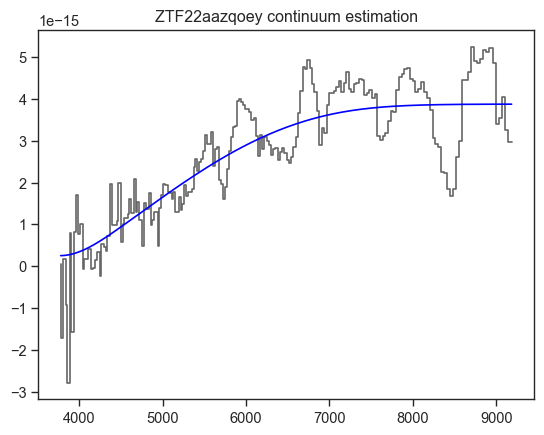

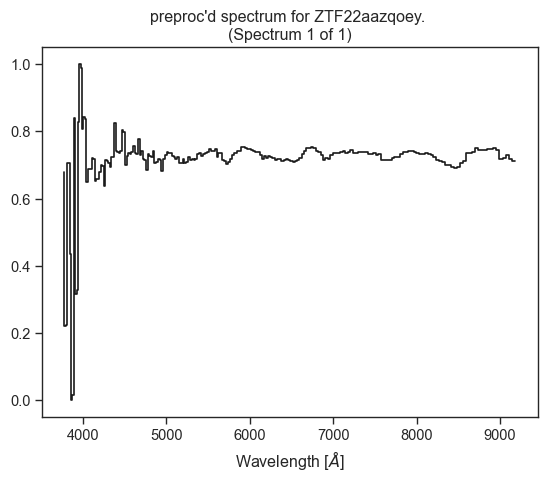

22 ZTF23aazuzip


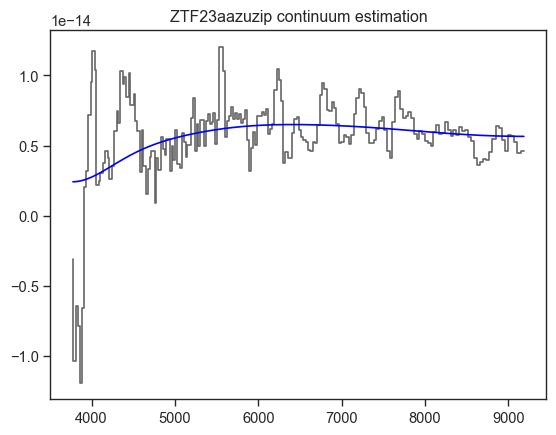

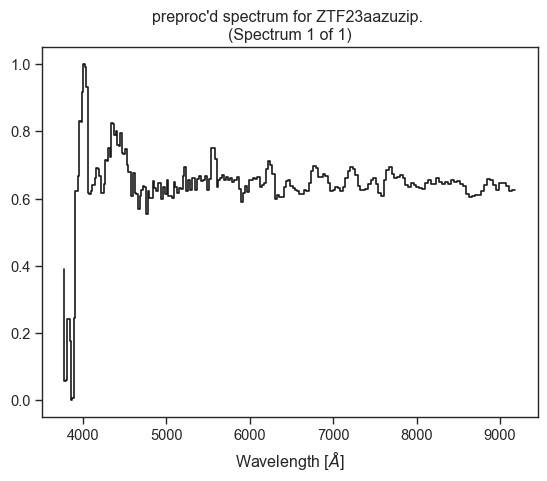

23 ZTF23abbpswf


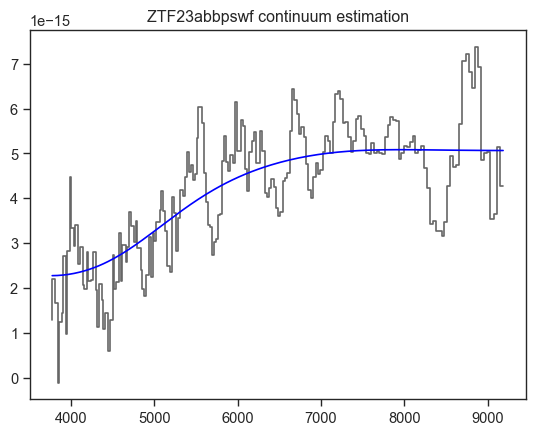

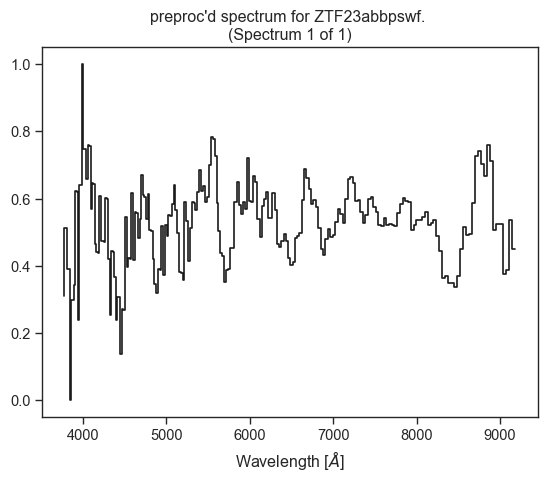

24 ZTF24aaymkrs


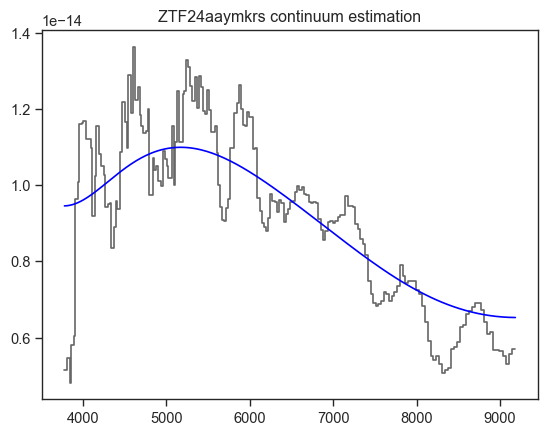

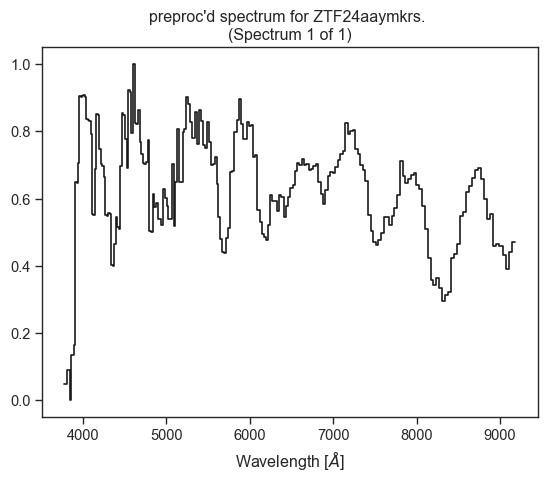

25 ZTF24abqqven


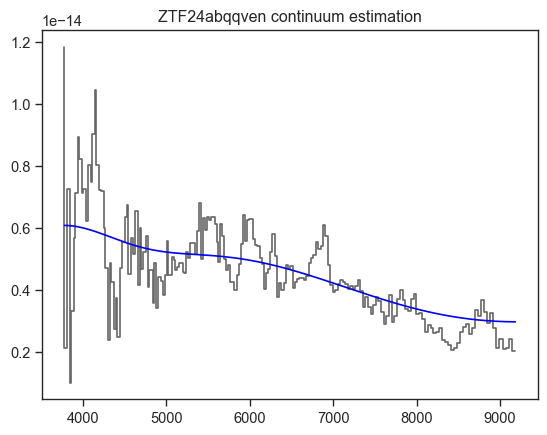

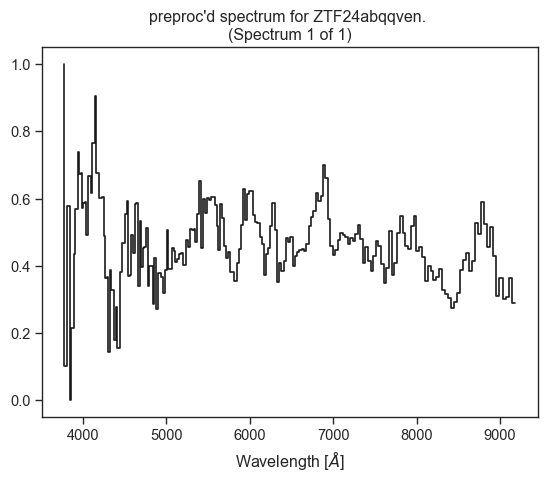

In [189]:
spectra_files_for_ib, ztf_names_ordered_ib = get_list_of_spec_files('ib_spectra', 'SN Ib')

for i in range(len(spectra_files_for_ib)):
    sfiles = spectra_files_for_ib[i]
    ztfname = ztf_names_ordered_ib[i]
    print(i, ztfname)
    preproc_spectra4maven(sfiles, save=True, plot=True, savedir='./maven_data/spectra/', ztfname=ztfname)

0 ZTF18absliyc


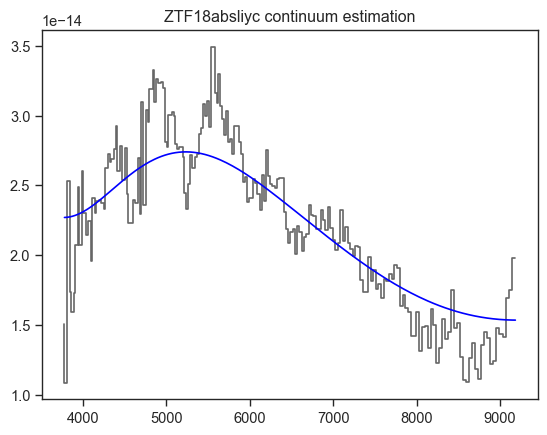

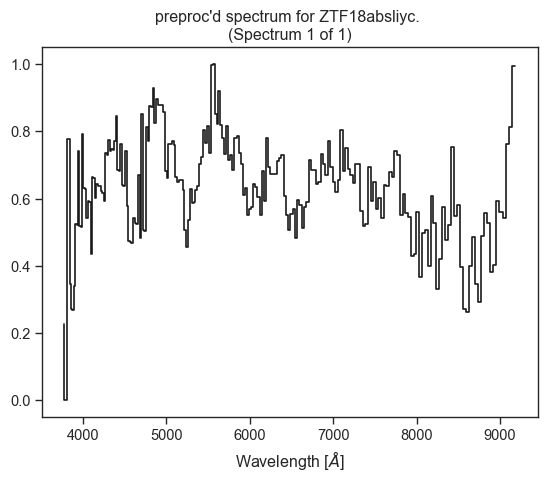

1 ZTF18acqphpd


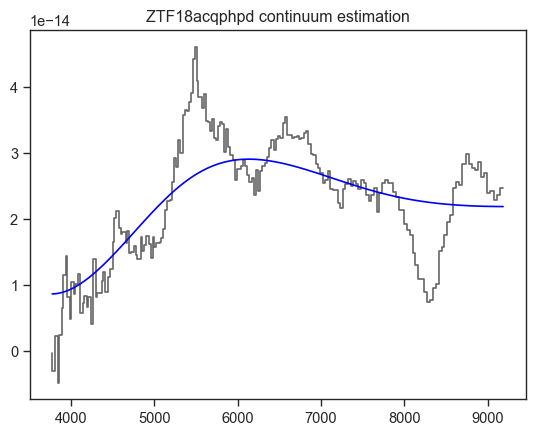

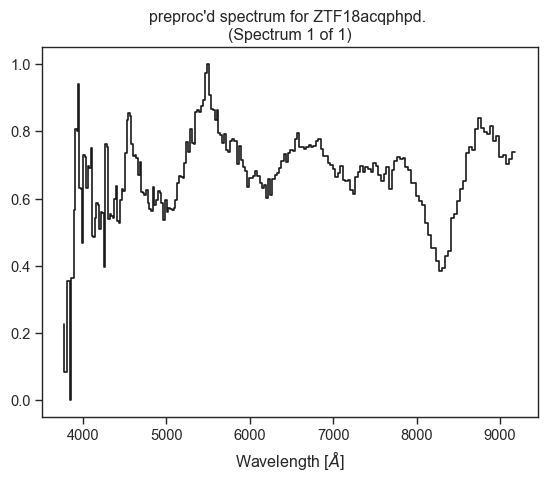

2 ZTF18aczqzrj


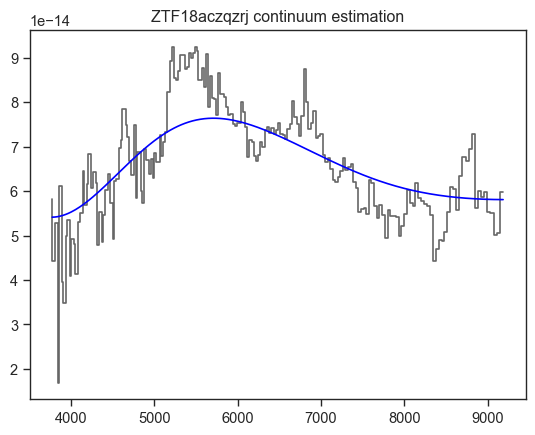

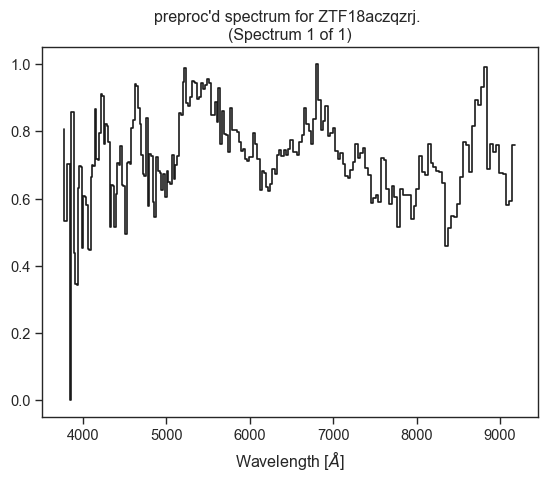

3 ZTF19aadwtoe


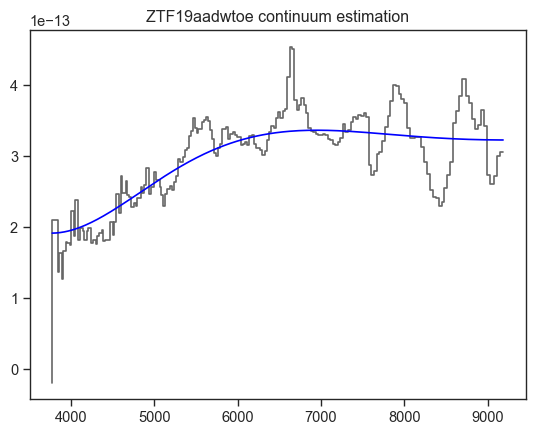

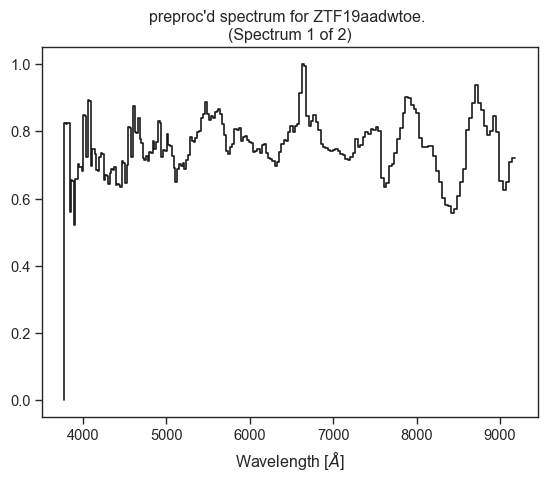

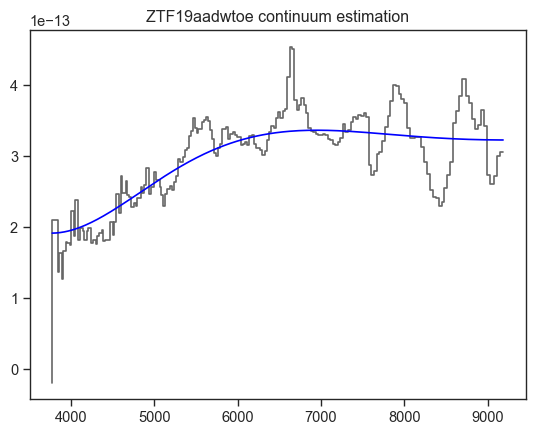

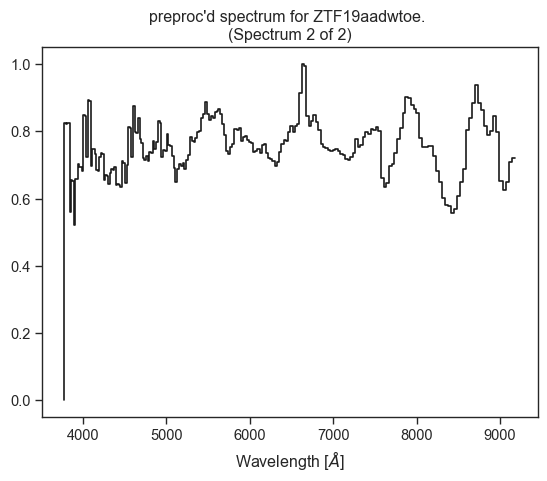

4 ZTF19aamsetj


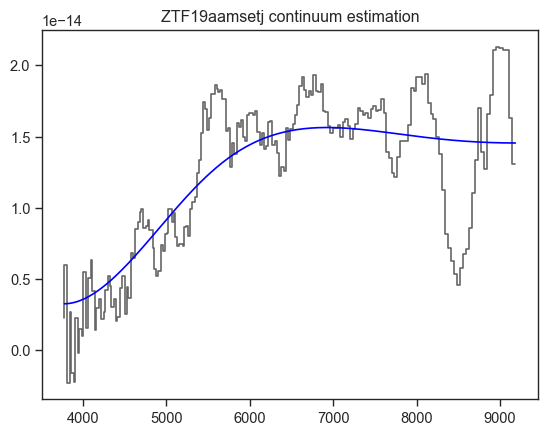

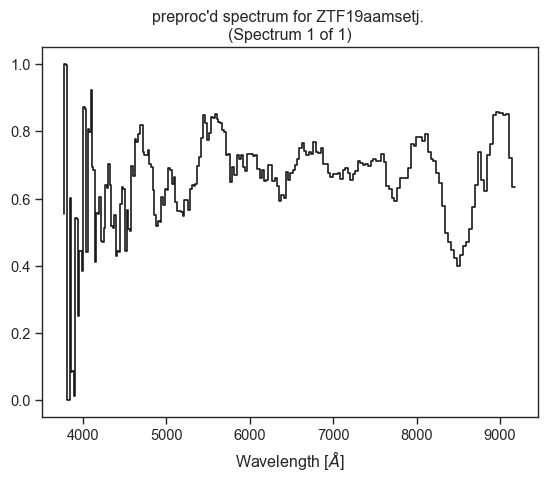

5 ZTF19aanijpu


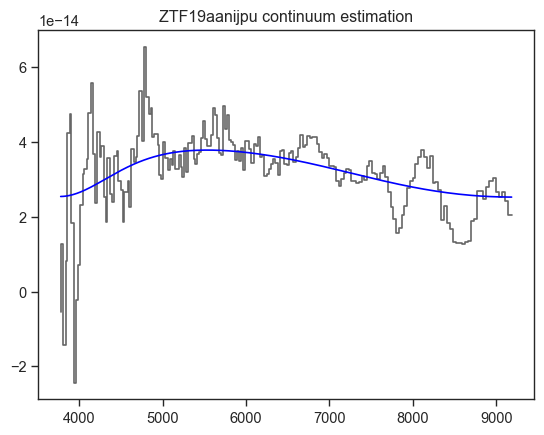

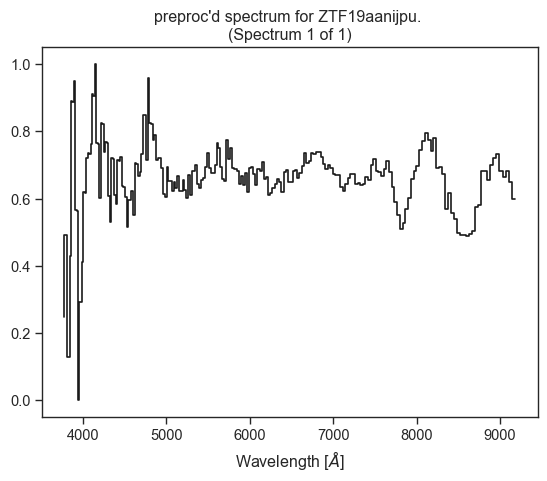

6 ZTF19aapceyj


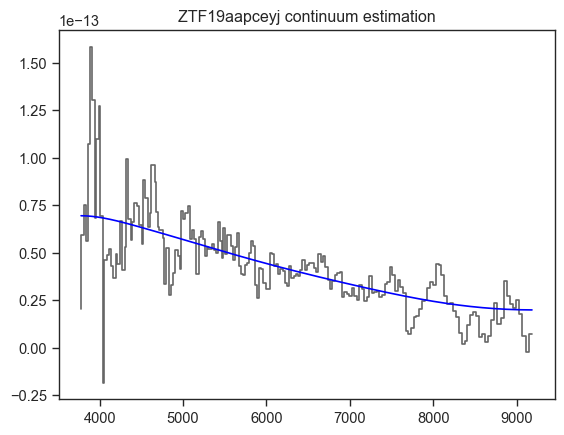

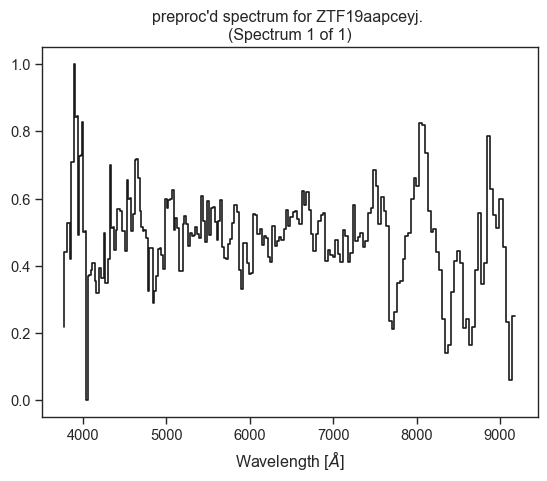

7 ZTF19aarfyvc


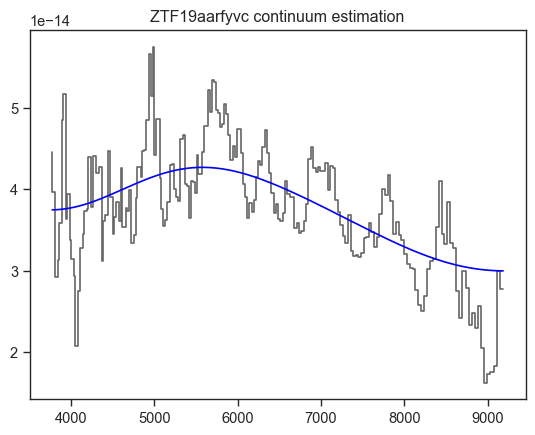

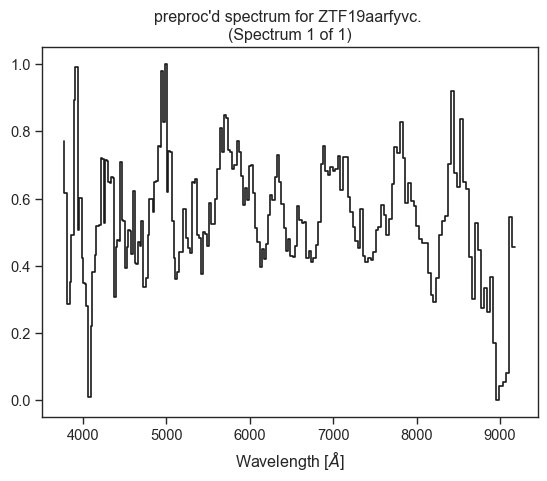

8 ZTF19aatheus


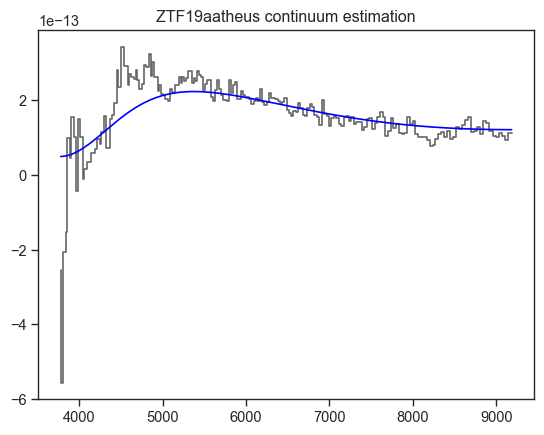

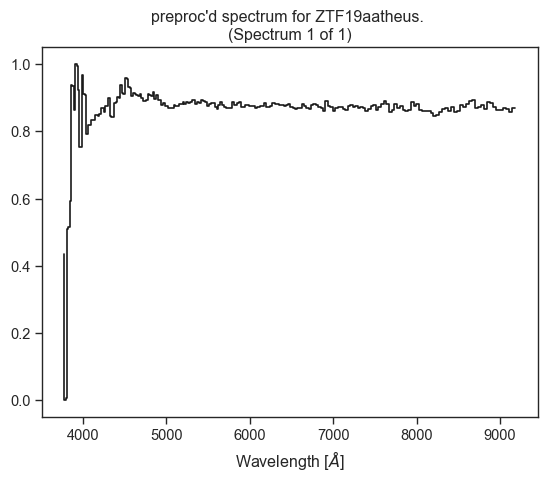

9 ZTF19aavoweu


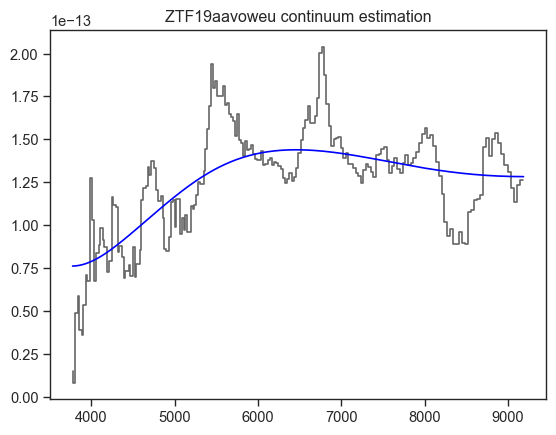

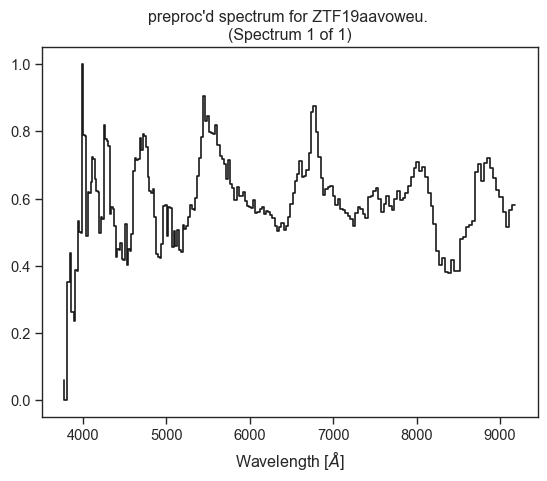

10 ZTF19abafmwj


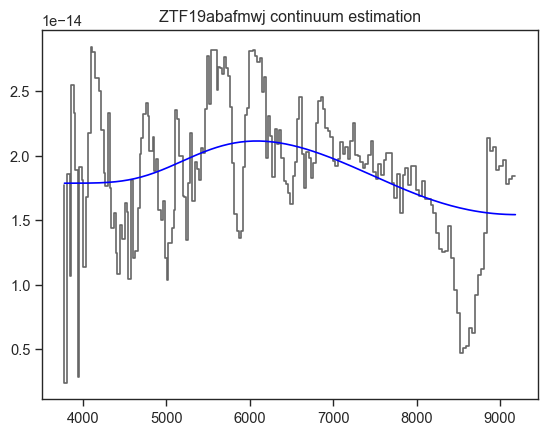

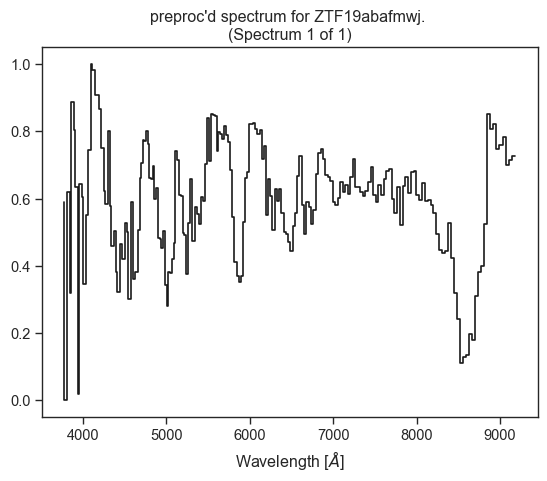

11 ZTF18aahuujv


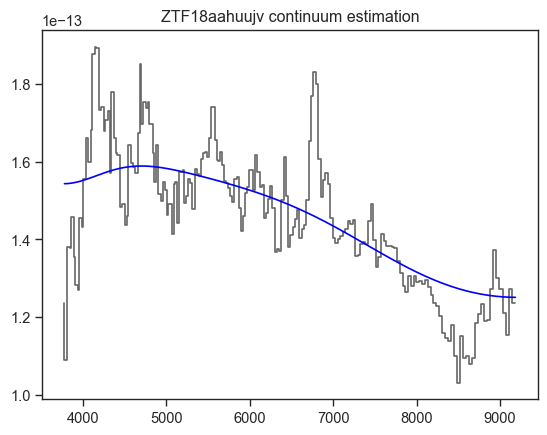

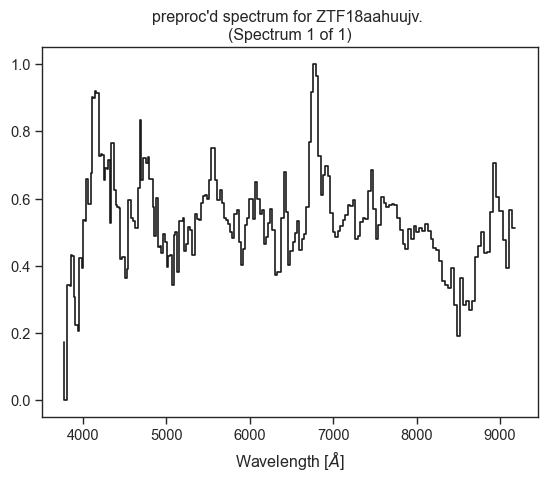

12 ZTF19abfiqjg


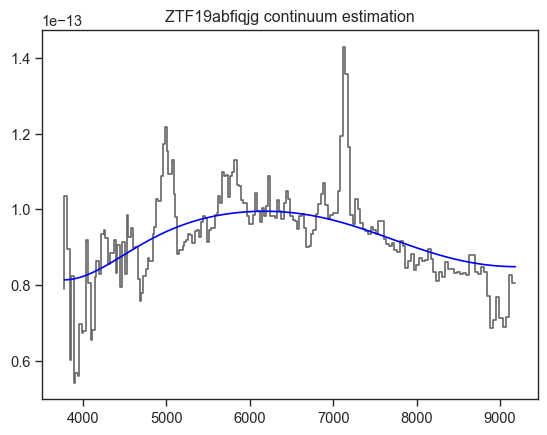

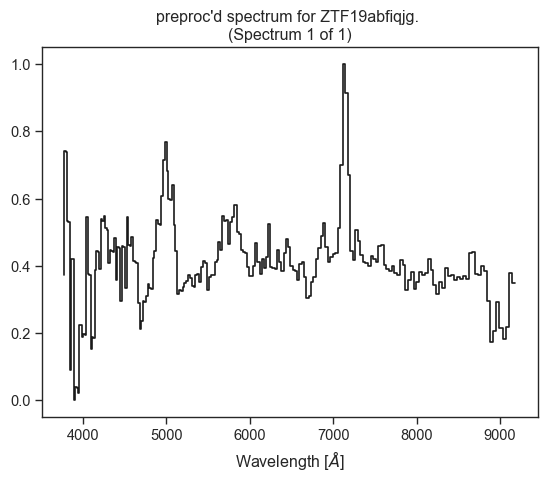

13 ZTF20actpqgc


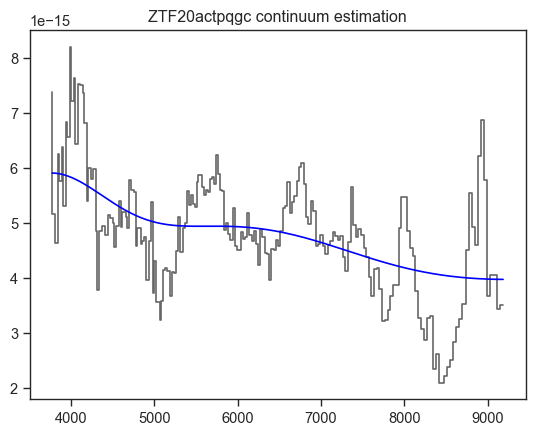

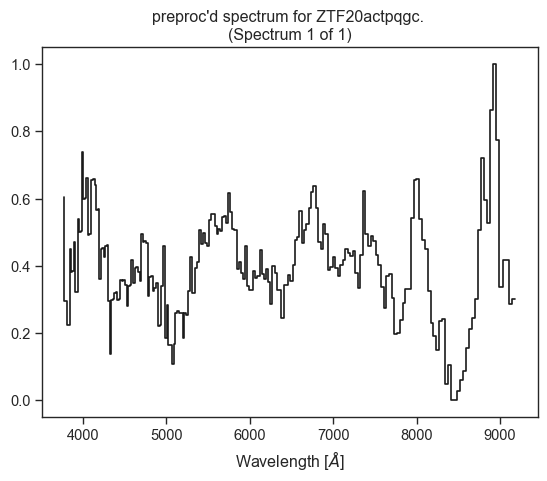

14 ZTF20aaiftgi


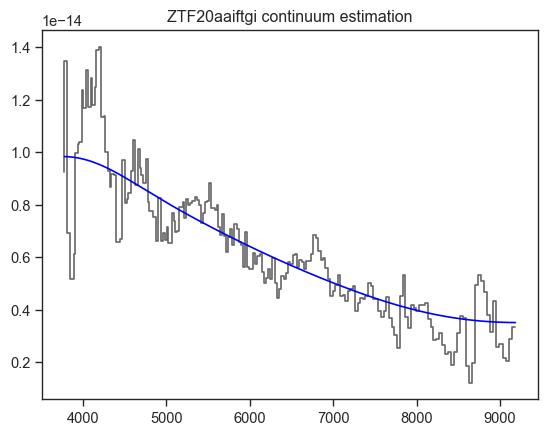

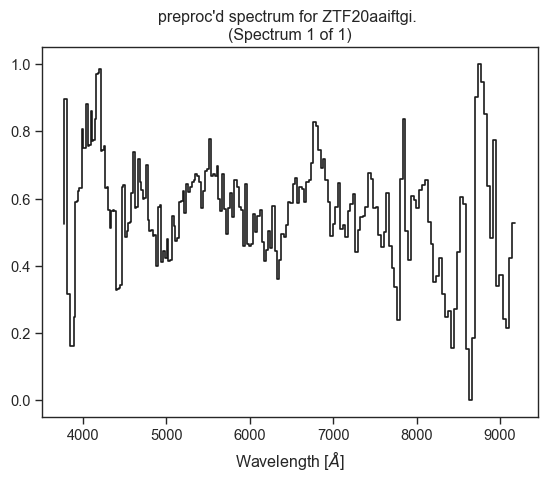

15 ZTF20aahggbm


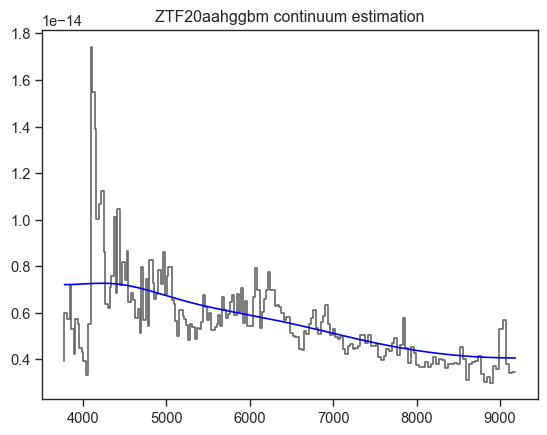

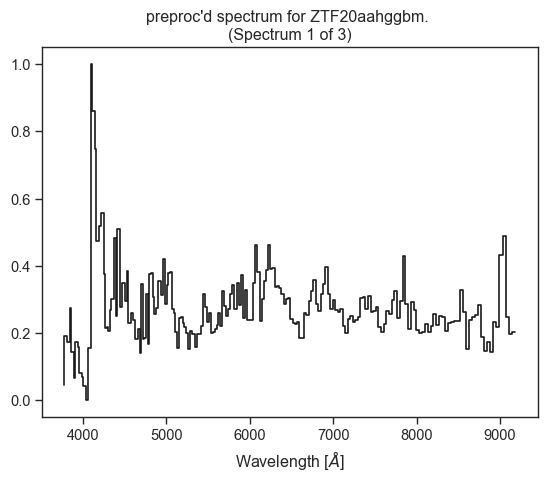

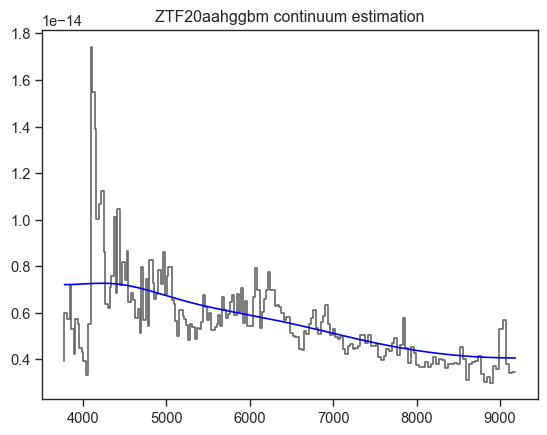

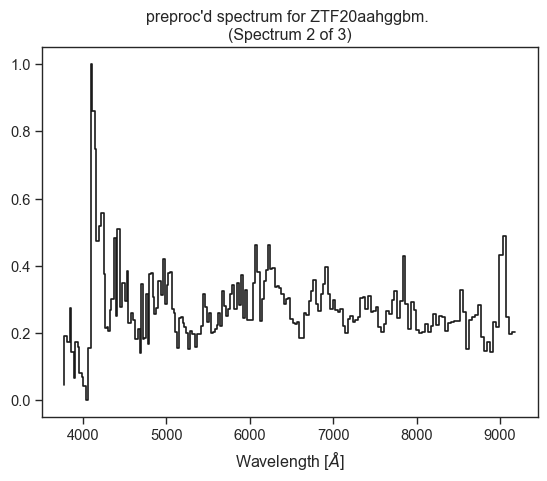

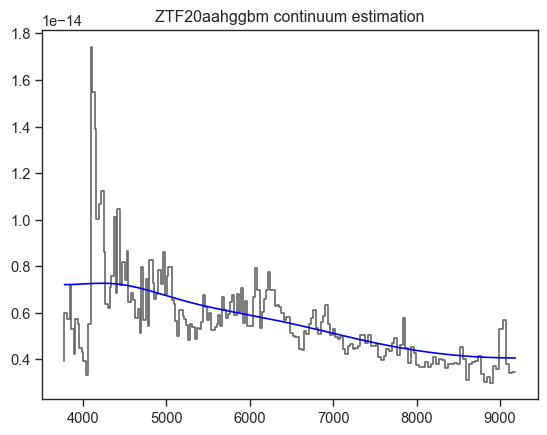

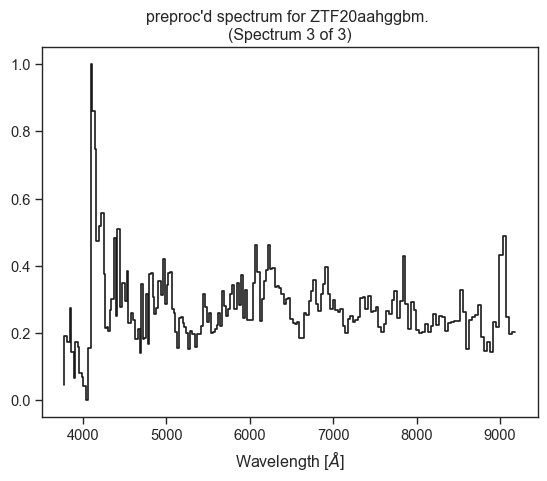

16 ZTF20aammtwx


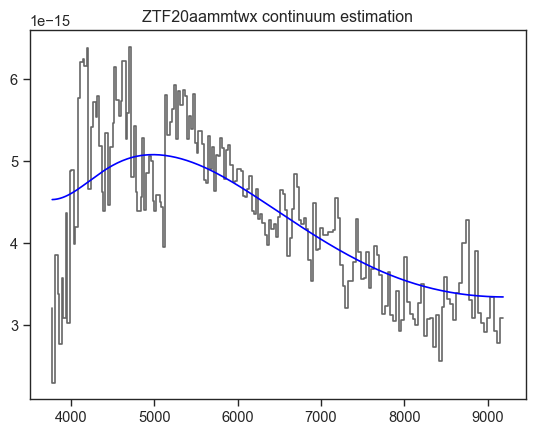

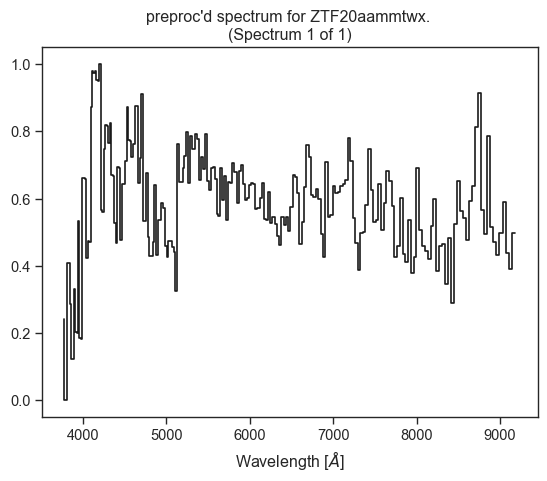

17 ZTF20aauwhfa


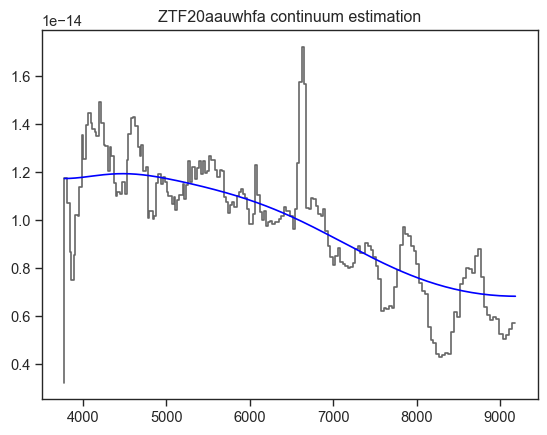

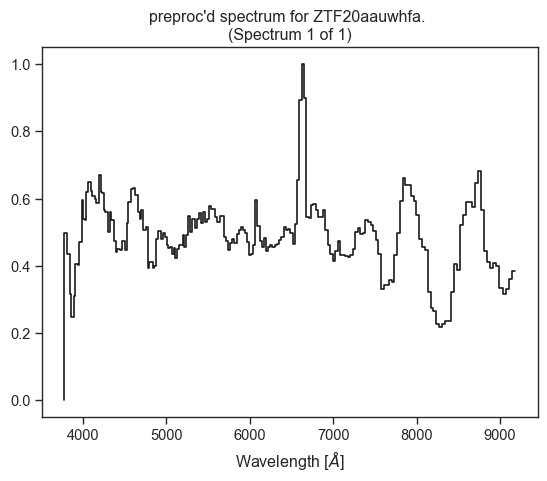

18 ZTF20aaurfnl


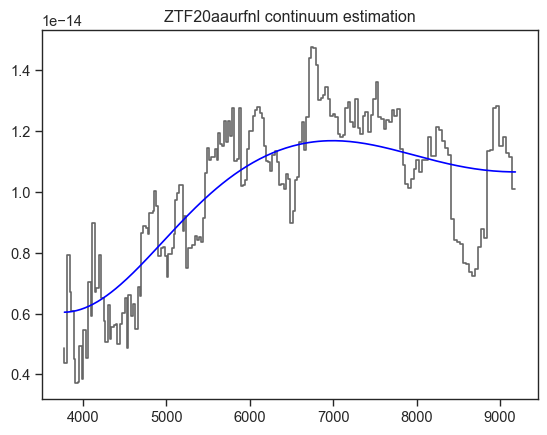

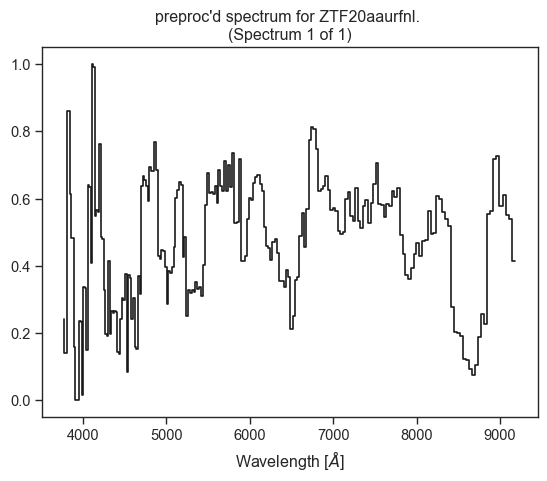

19 ZTF20abeezca


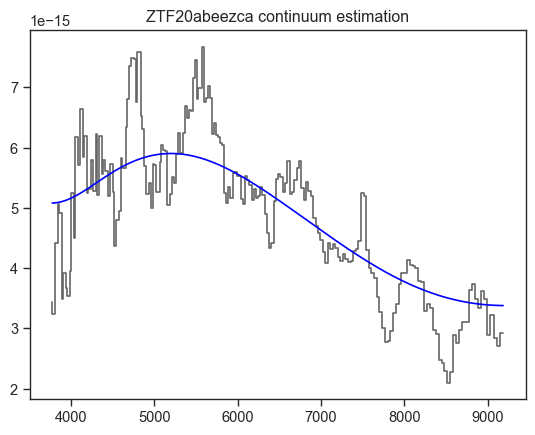

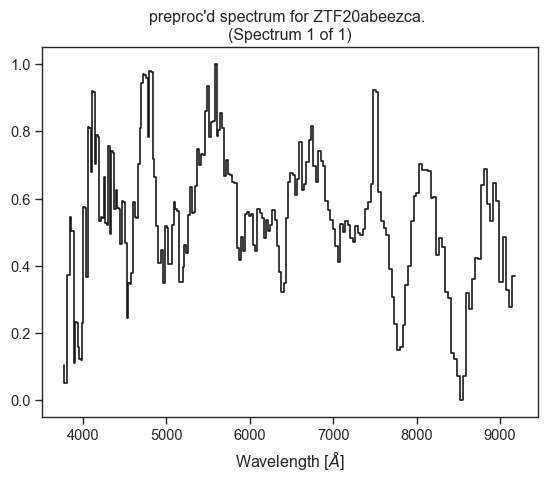

20 ZTF20aaekkuv


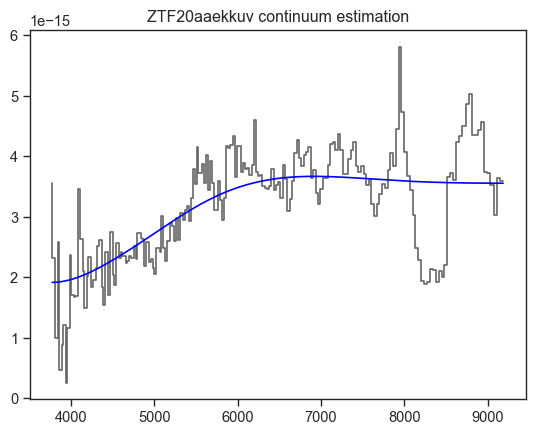

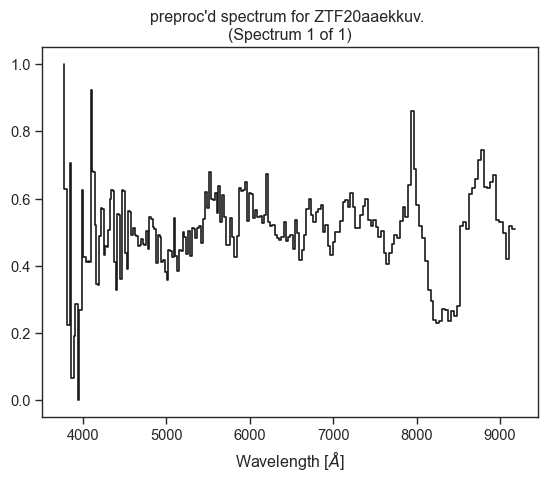

21 ZTF20abkiarz


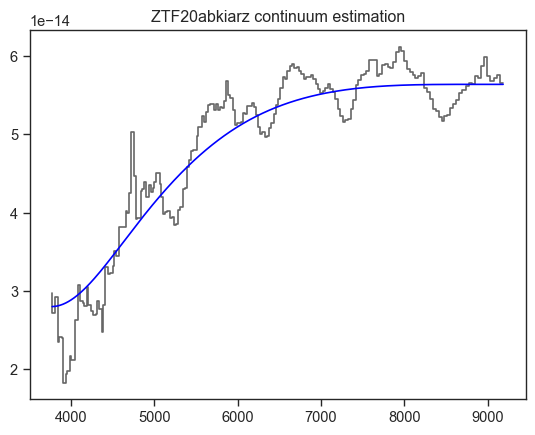

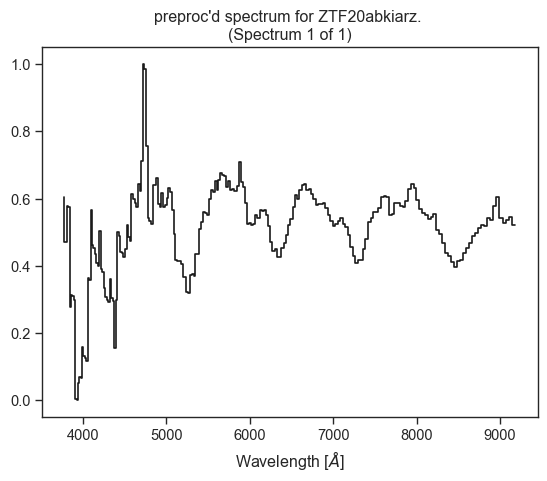

22 ZTF20abtkjfw


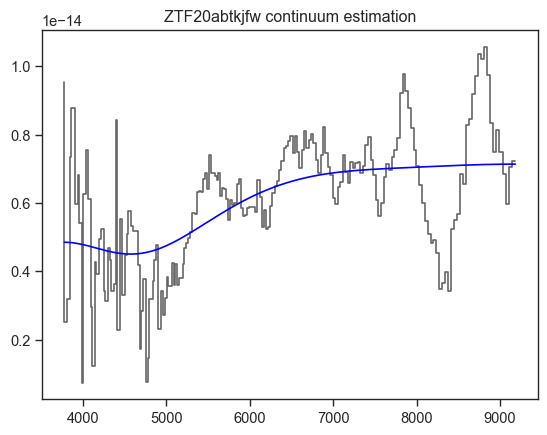

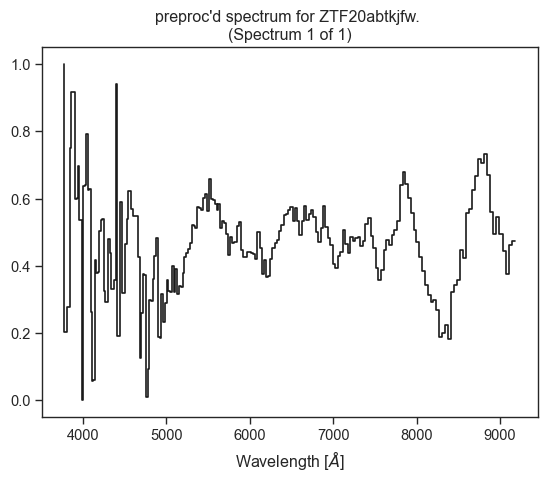

23 ZTF20abxpoxd


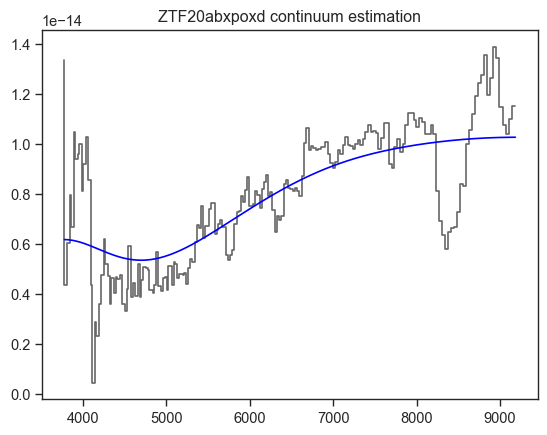

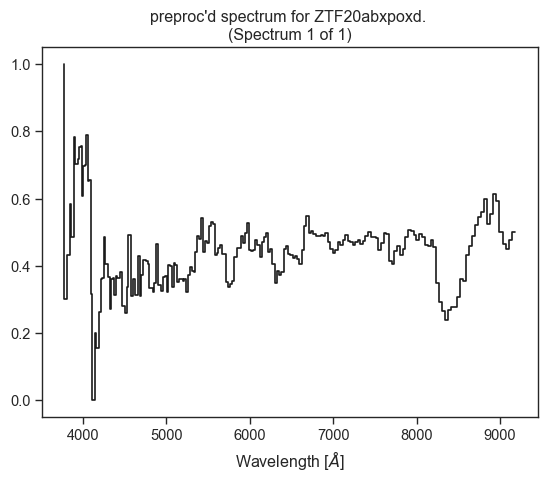

24 ZTF20acfqngt


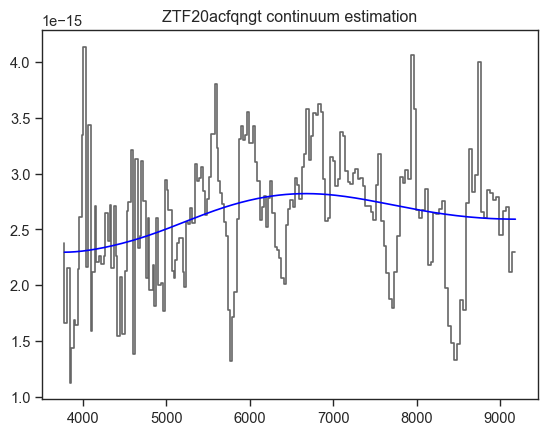

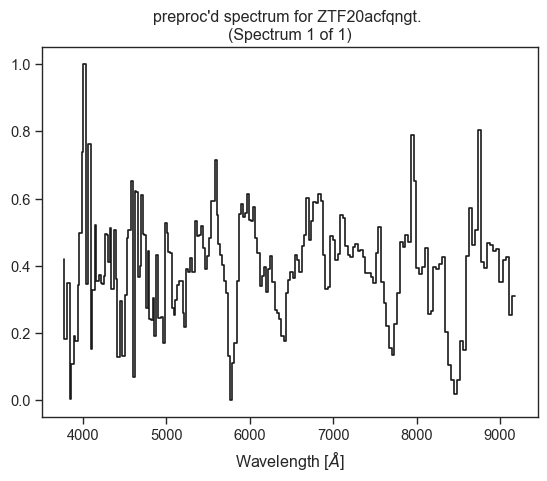

25 ZTF20aclnplo


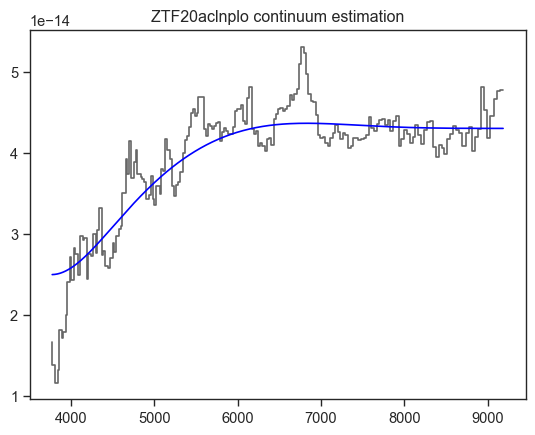

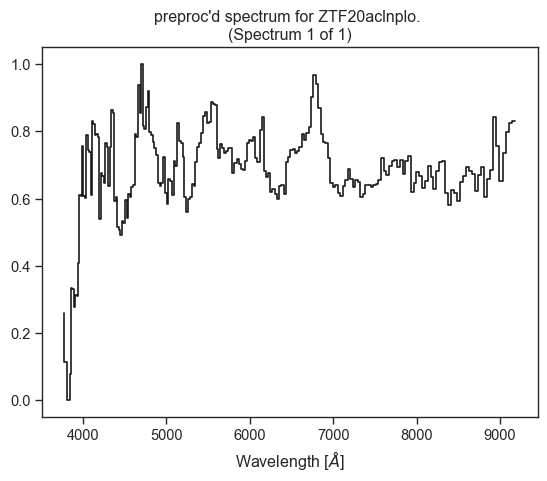

26 ZTF21aaaosoq


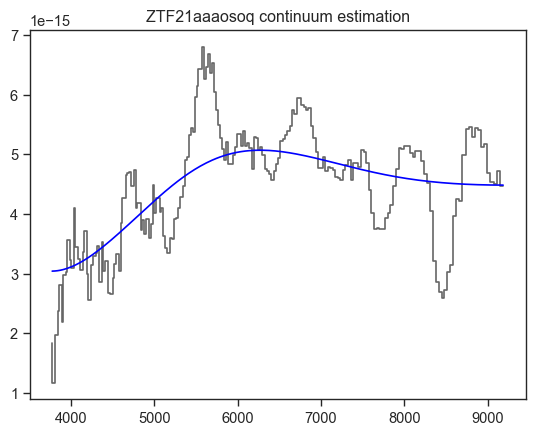

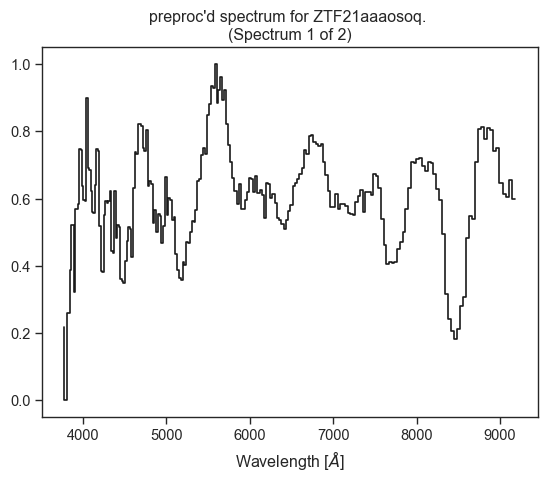

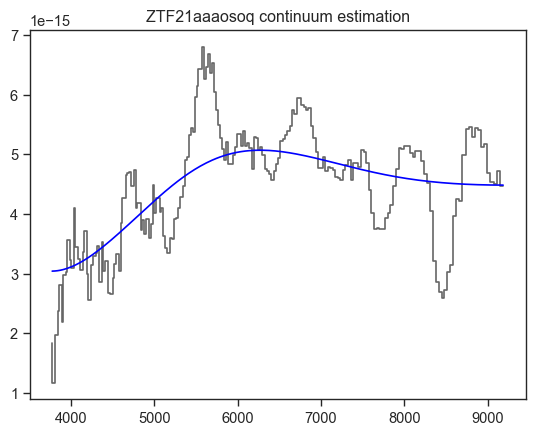

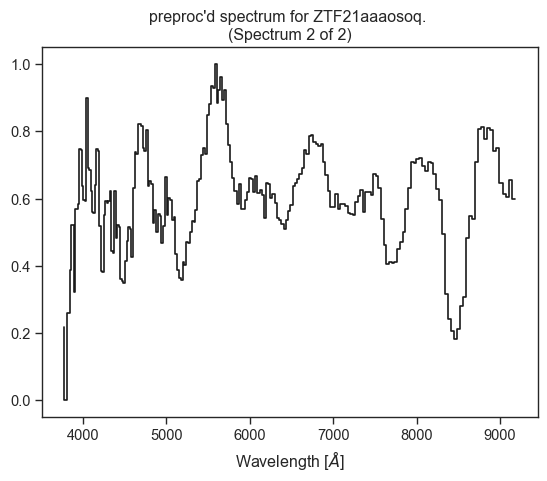

27 ZTF21aahdqrg


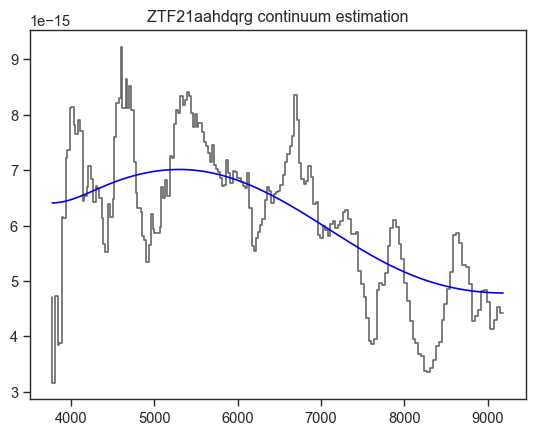

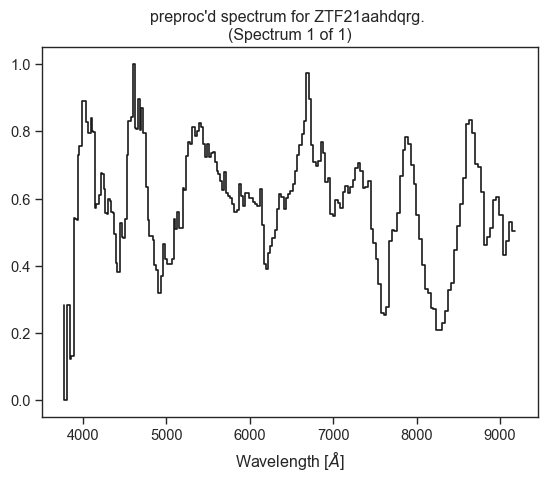

28 ZTF21abcrhpk


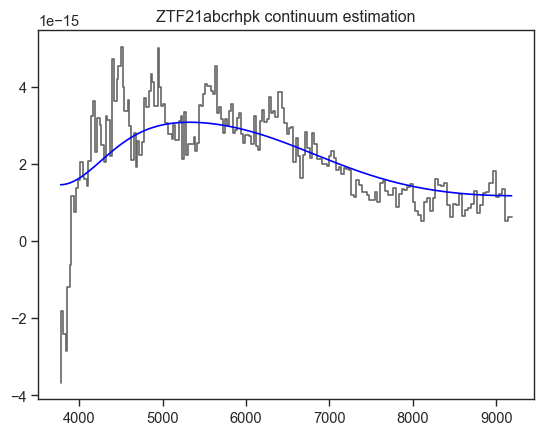

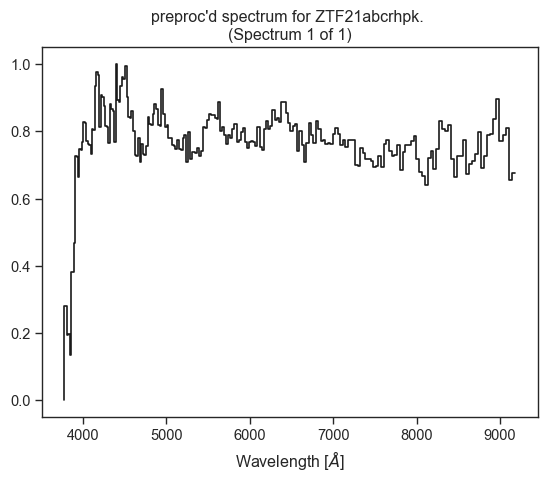

29 ZTF21abrfvax


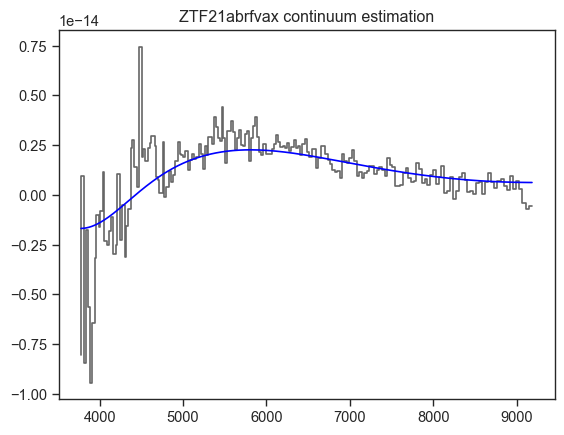

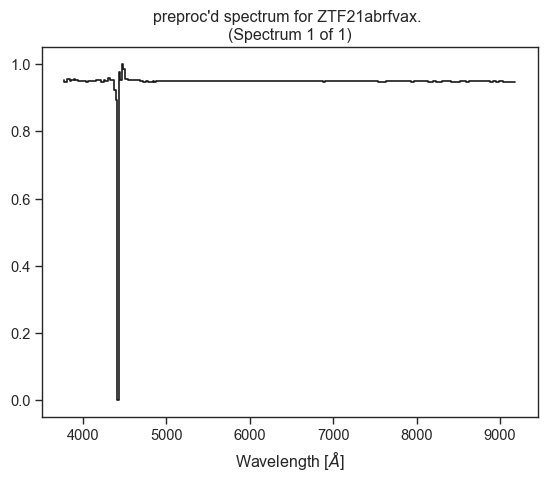

30 ZTF22abxlfpl


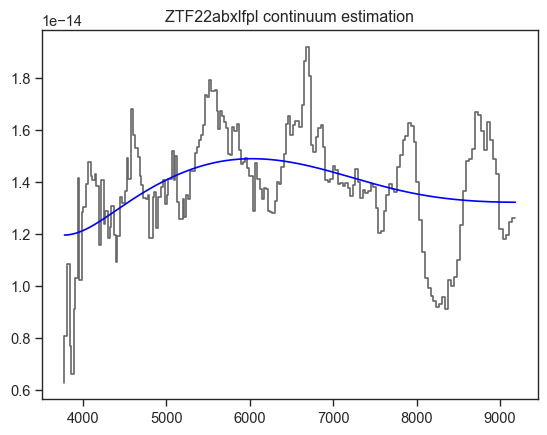

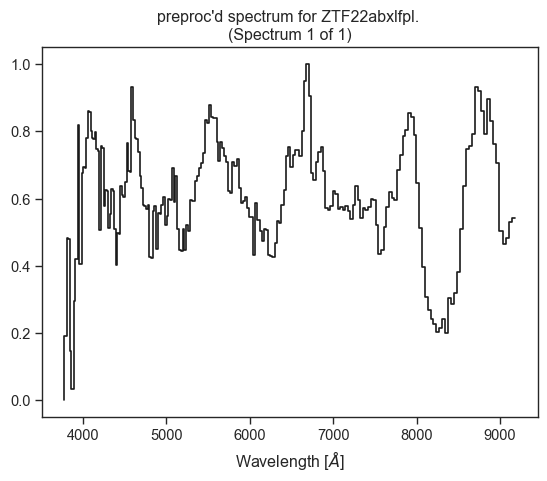

31 ZTF22abztcly


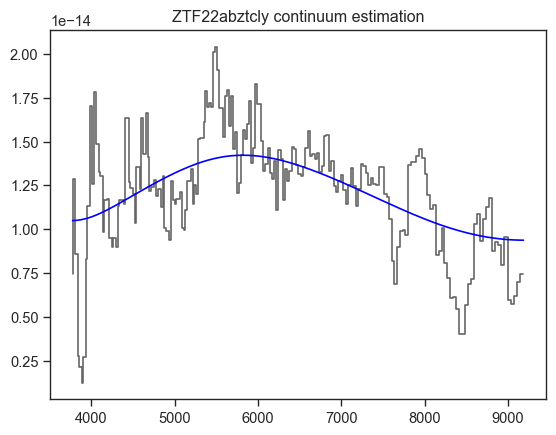

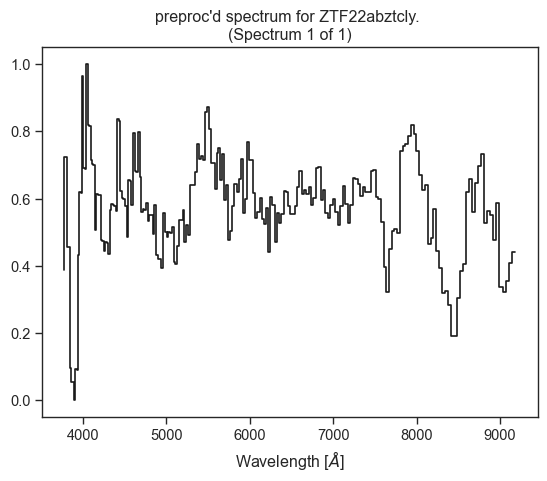

32 ZTF22aagzmcz


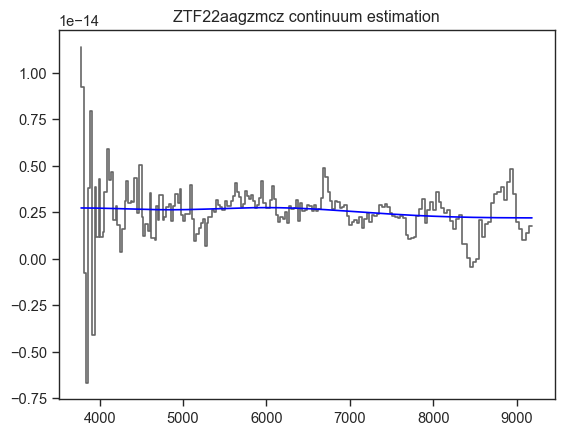

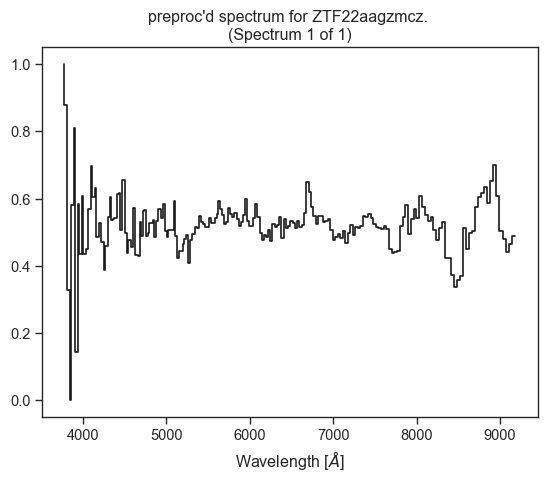

33 ZTF22aalfmec


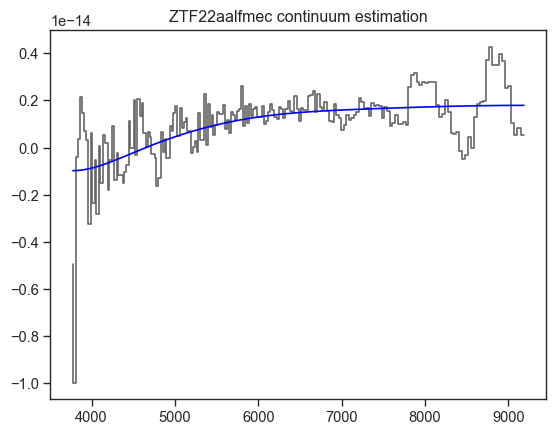

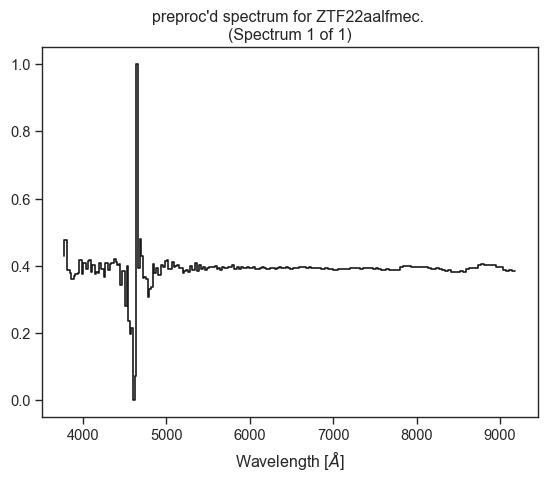

34 ZTF22aaoolua


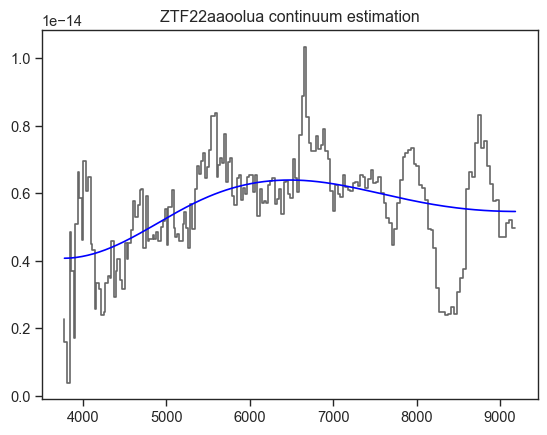

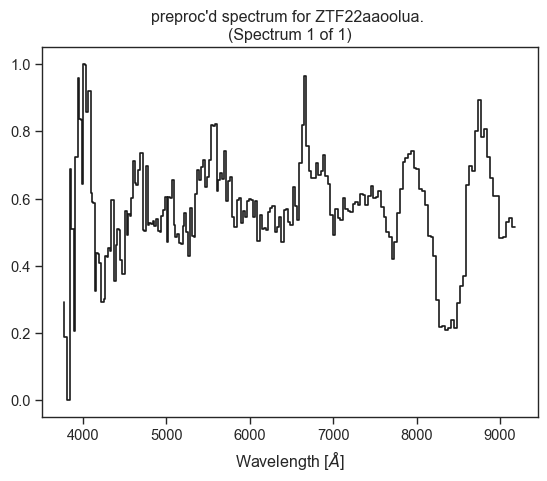

35 ZTF22aasxgjp


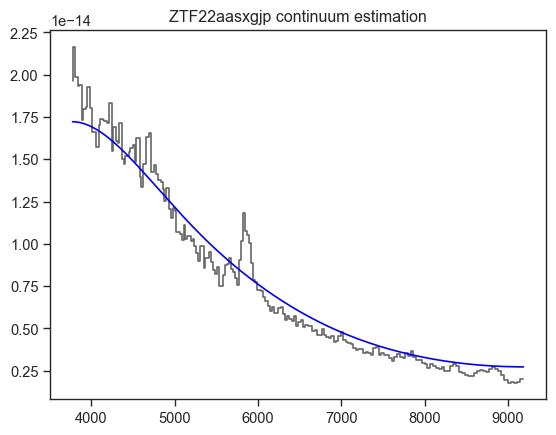

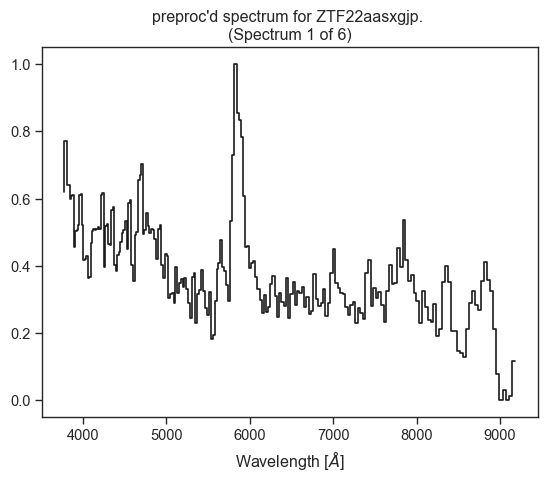

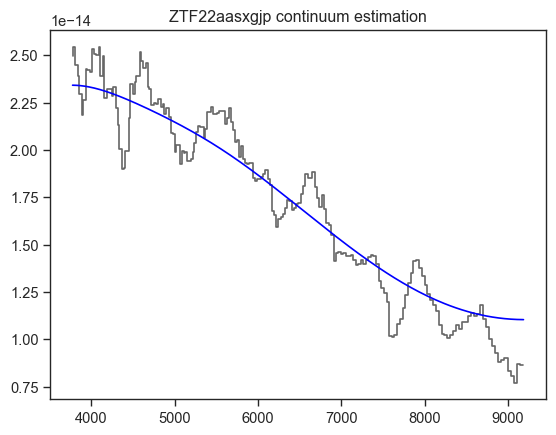

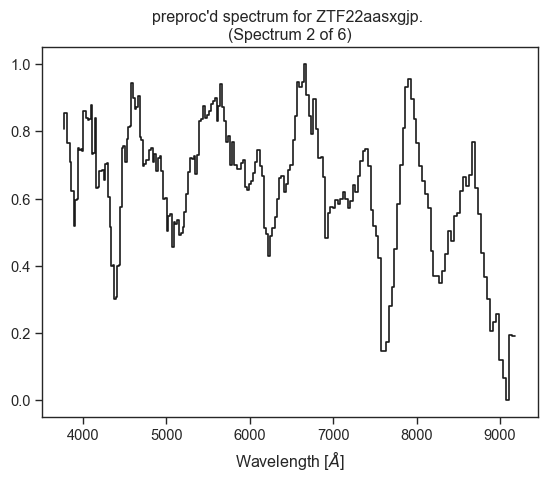

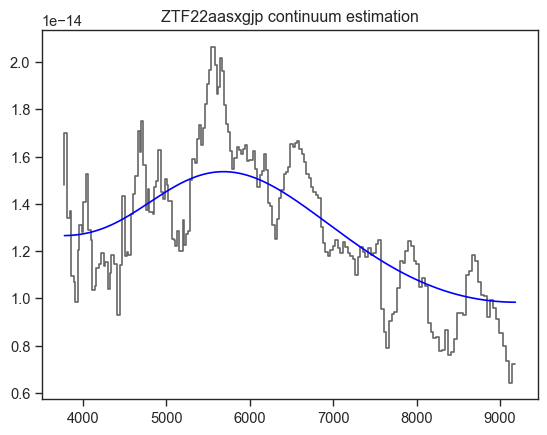

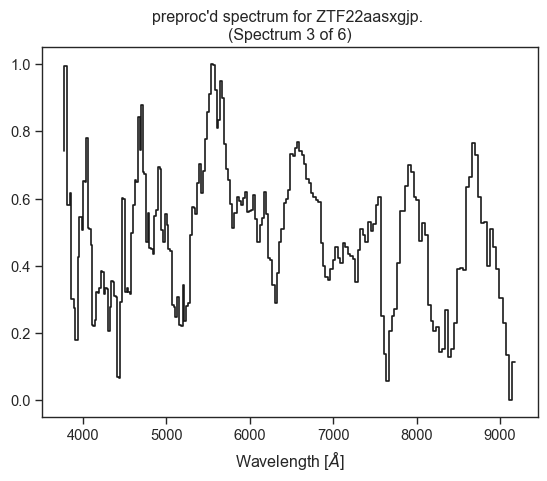

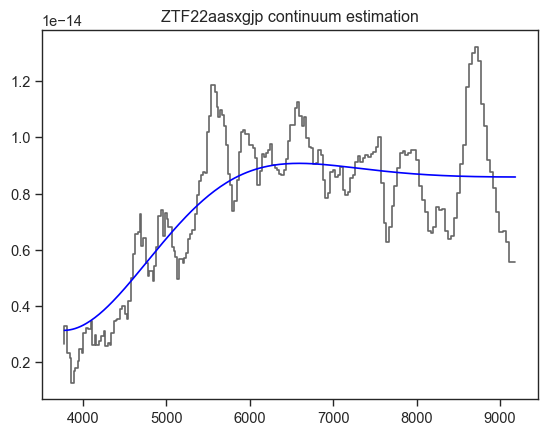

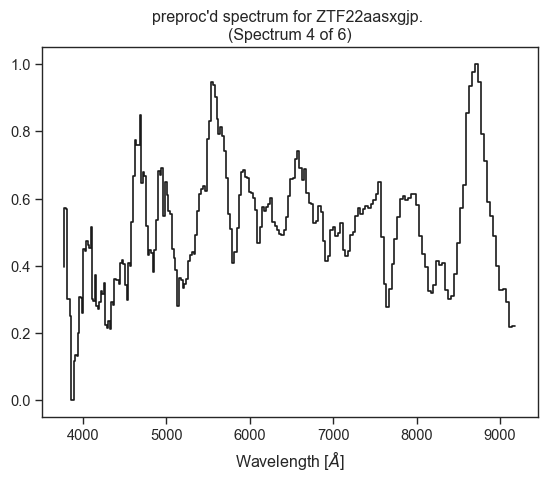

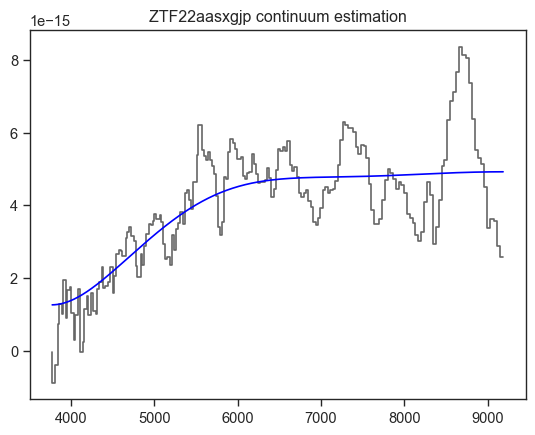

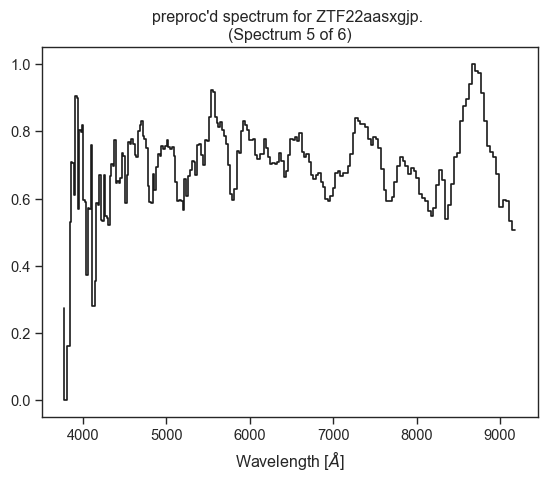

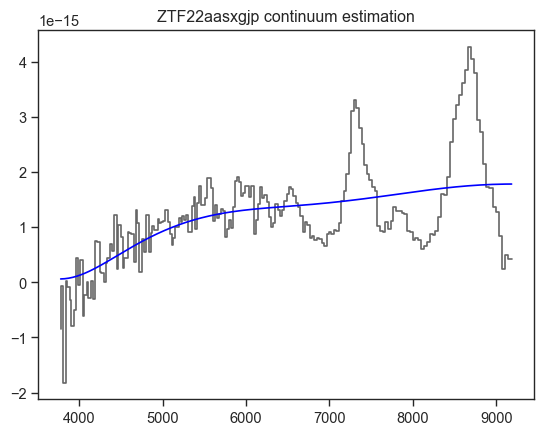

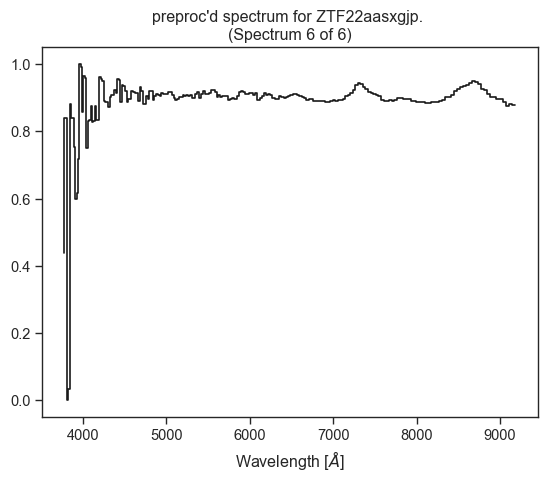

36 ZTF22abllclb


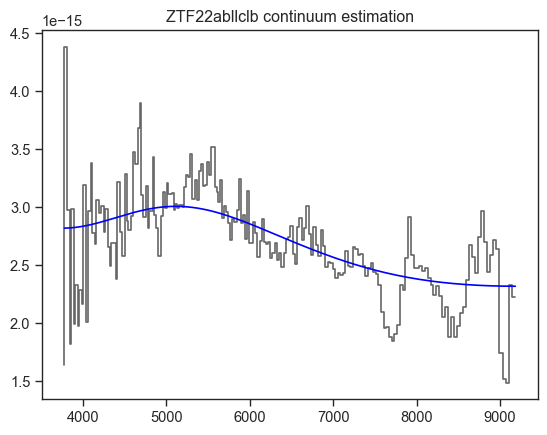

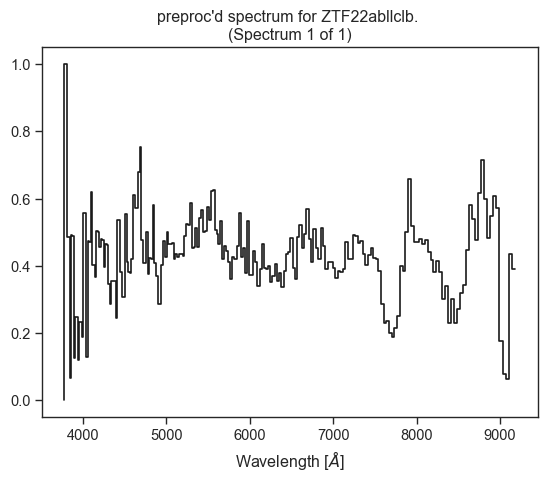

37 ZTF23aaazffe


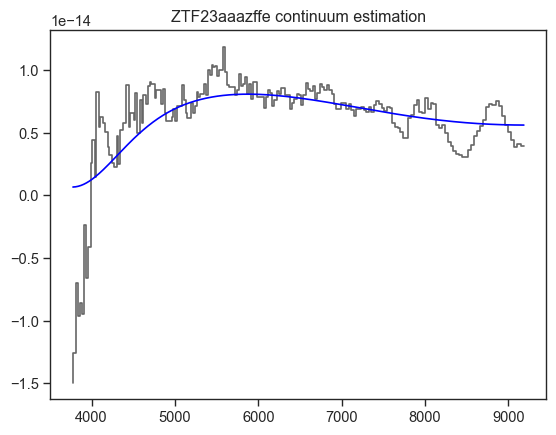

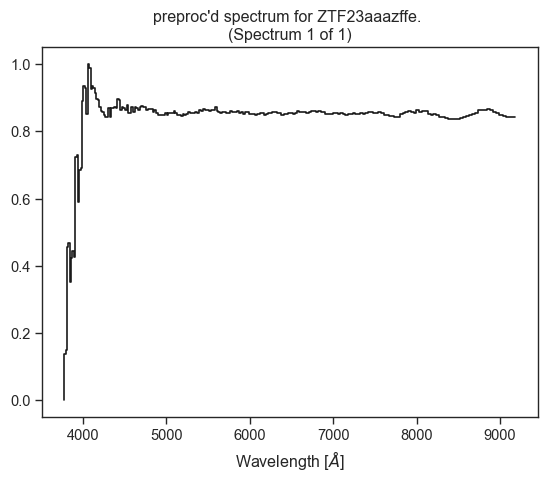

38 ZTF23aajakys


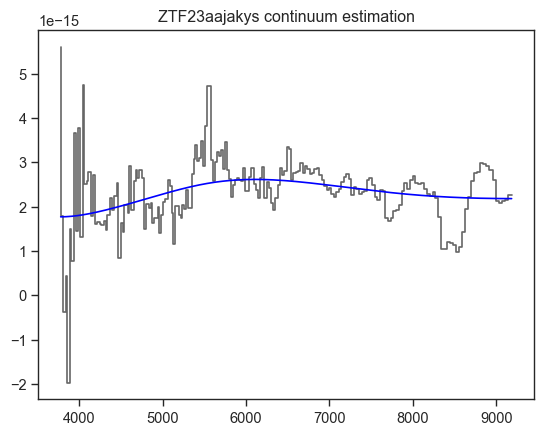

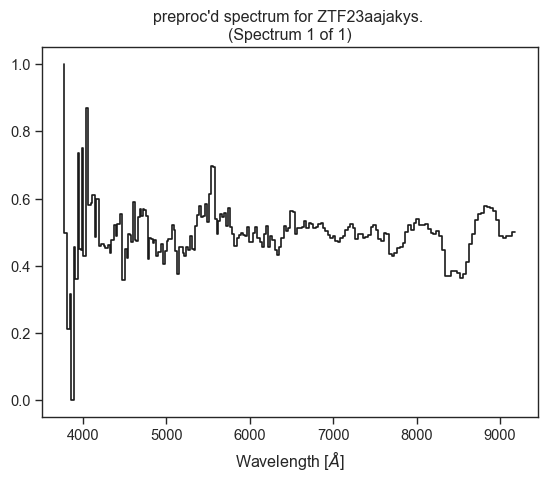

39 ZTF23aajpxbm


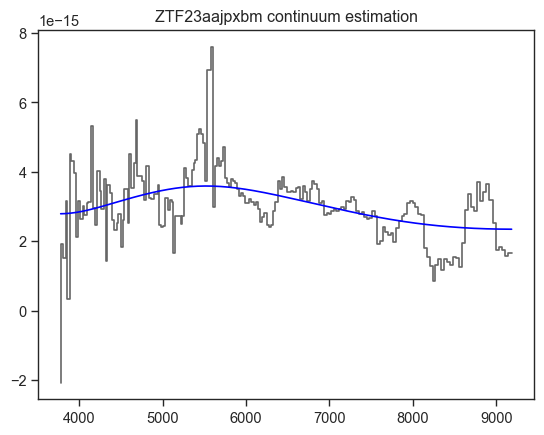

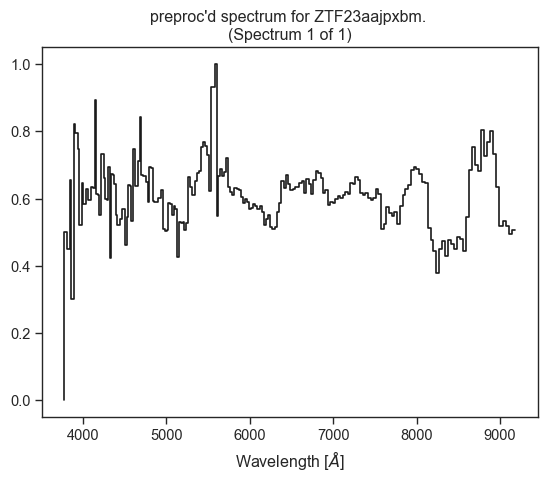

40 ZTF23abjrolk


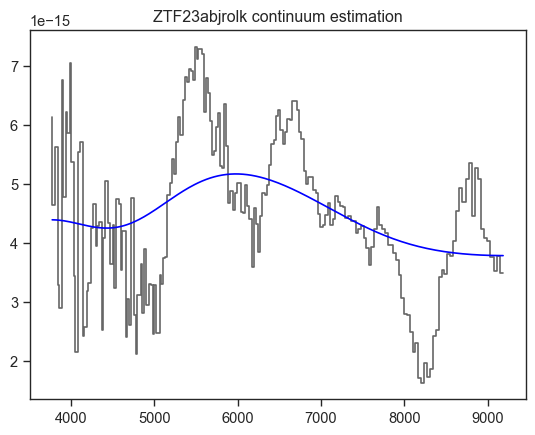

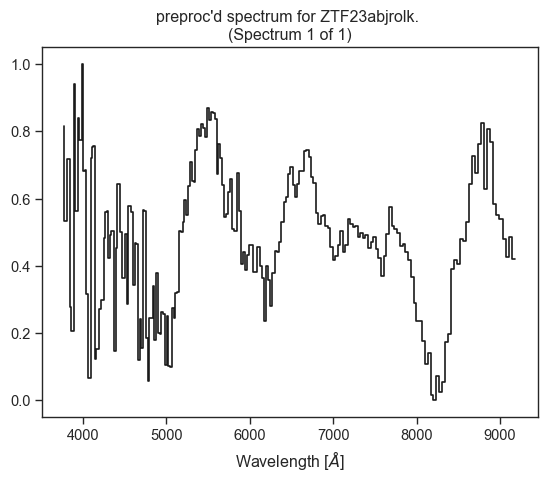

41 ZTF24absznoi


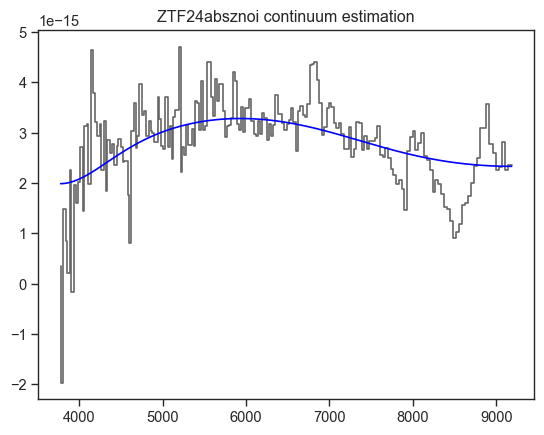

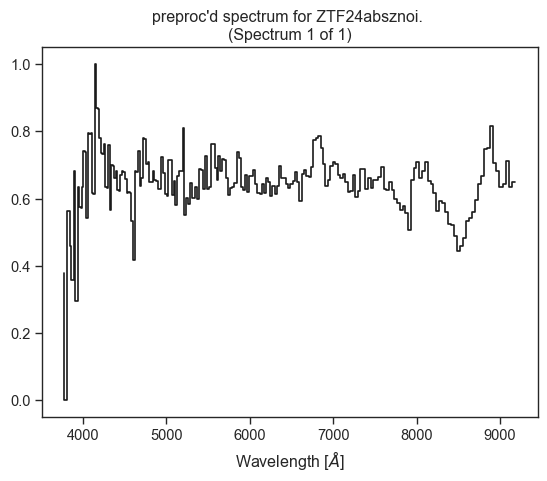

42 ZTF24abtnkbi


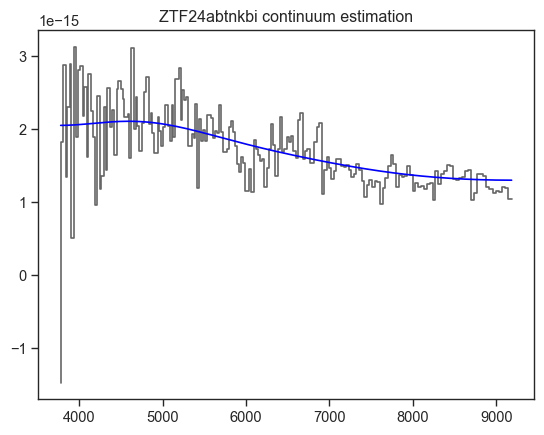

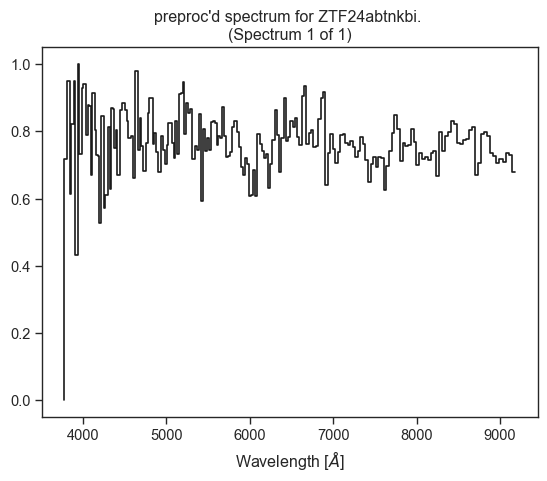

43 ZTF24abzmhtv


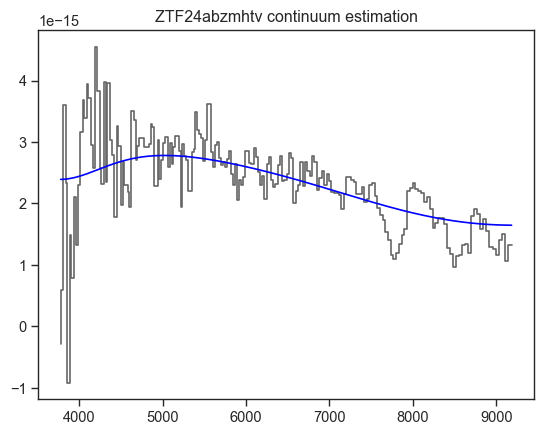

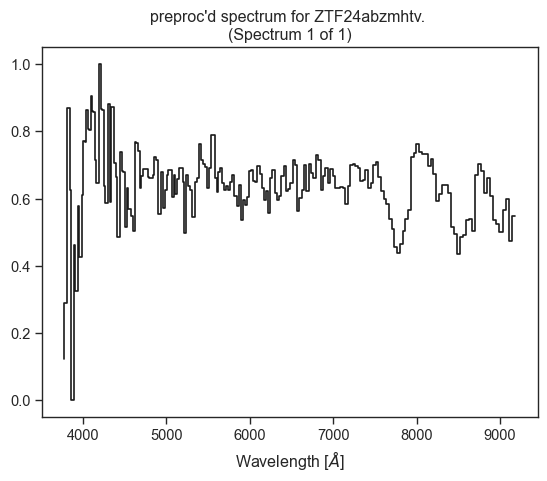

44 ZTF24abzgggz


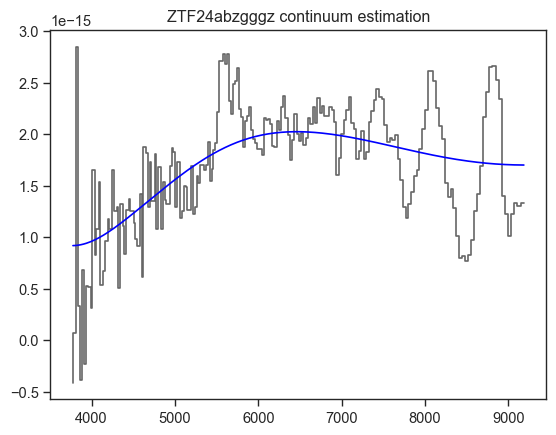

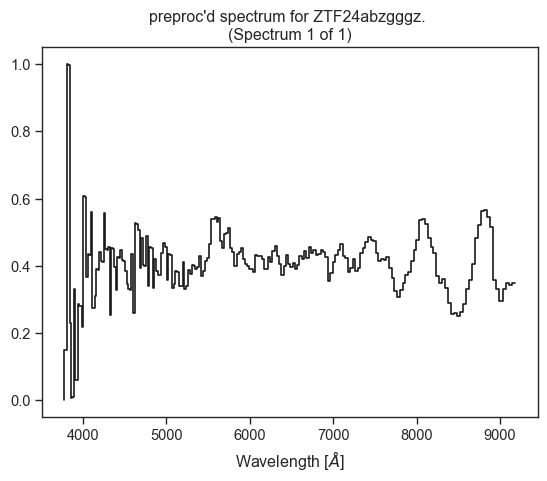

45 ZTF25aadnogd


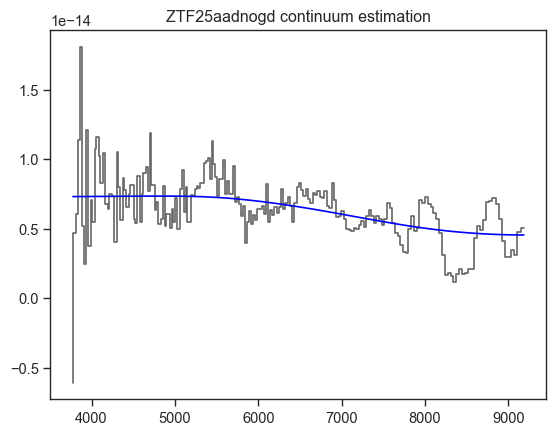

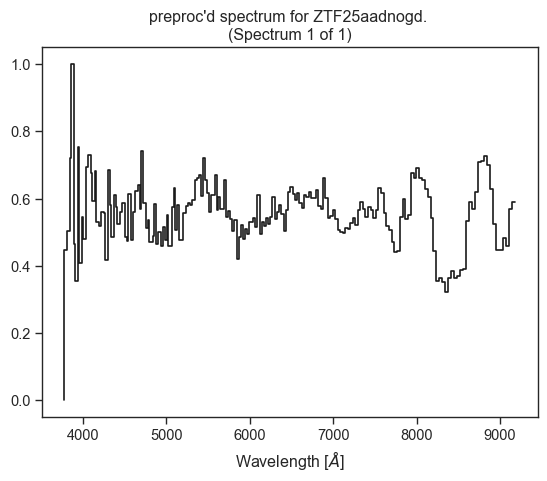

In [190]:
spectra_files_for_ic, ztf_names_ordered_ic = get_list_of_spec_files('ic_spectra', 'SN Ic')

for i in range(len(spectra_files_for_ic)):
    sfiles = spectra_files_for_ic[i]
    ztfname = ztf_names_ordered_ic[i]
    print(i, ztfname)
    preproc_spectra4maven(sfiles, save=True, plot=True, savedir='./maven_data/spectra/', ztfname=ztfname)

0 ZTF18abojpnr


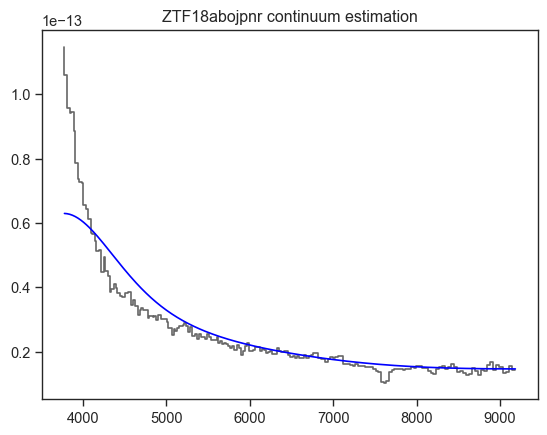

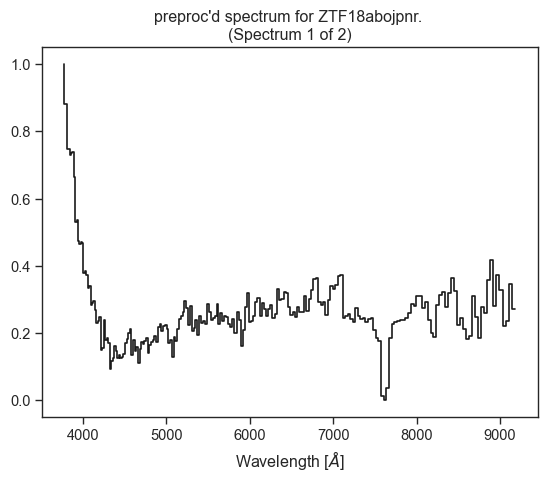

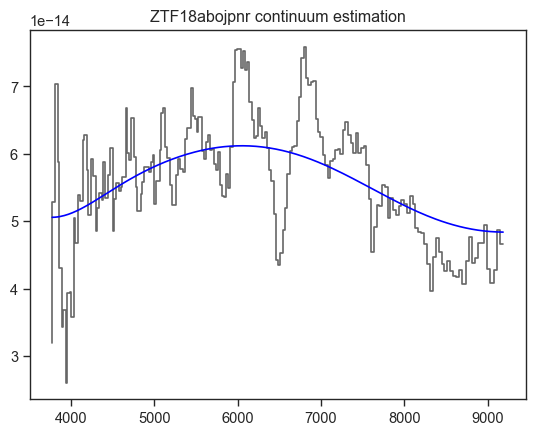

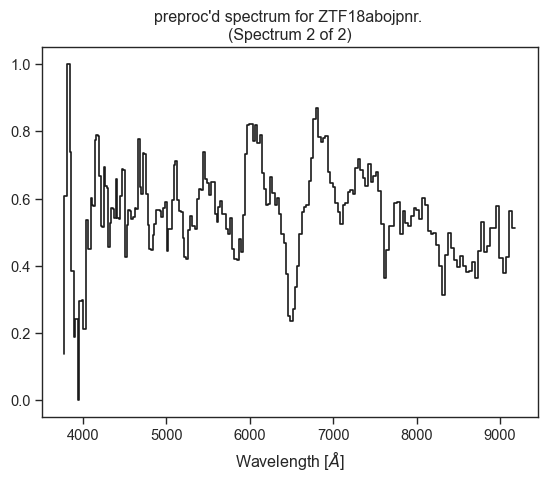

1 ZTF18acnmifq


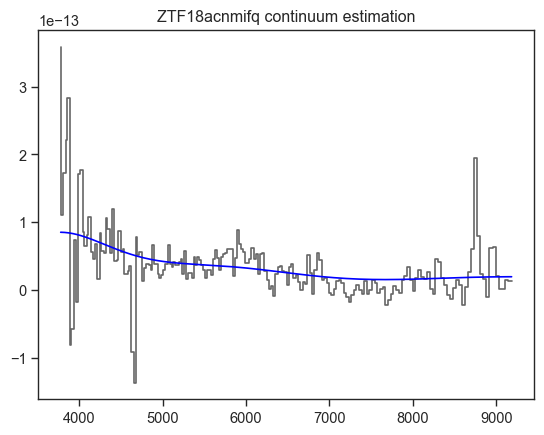

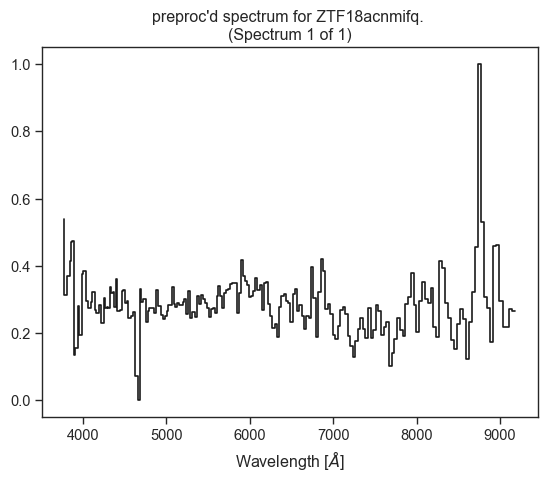

2 ZTF18acrcyqw


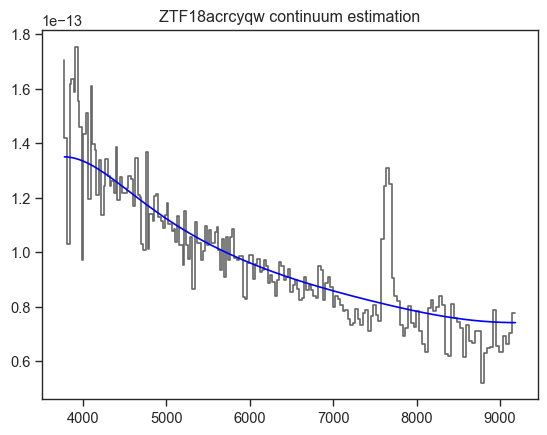

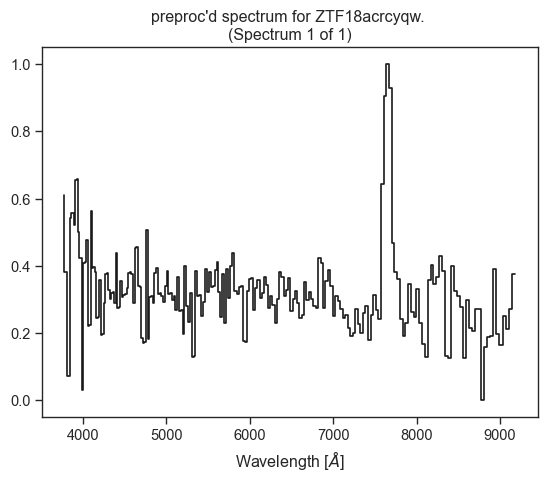

3 ZTF19aawethv


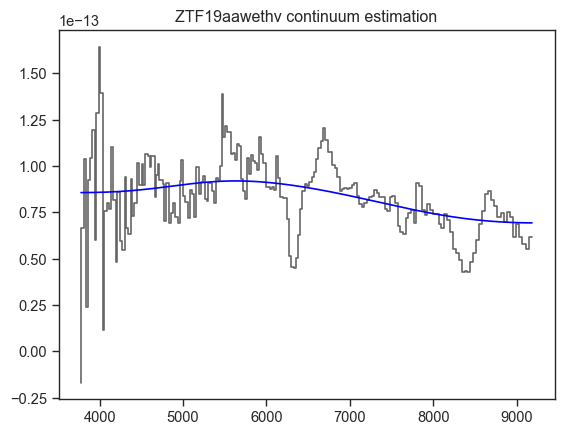

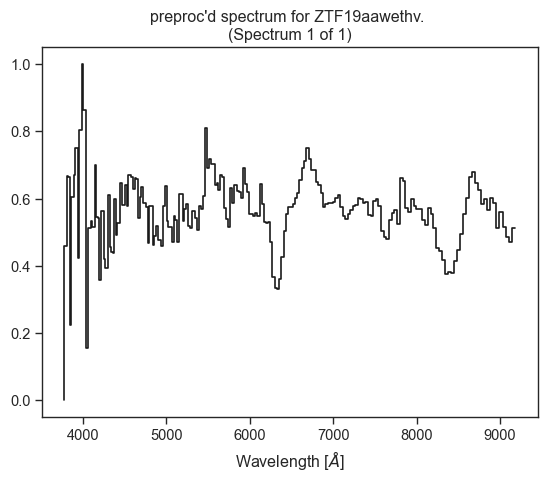

4 ZTF19abqmsnk


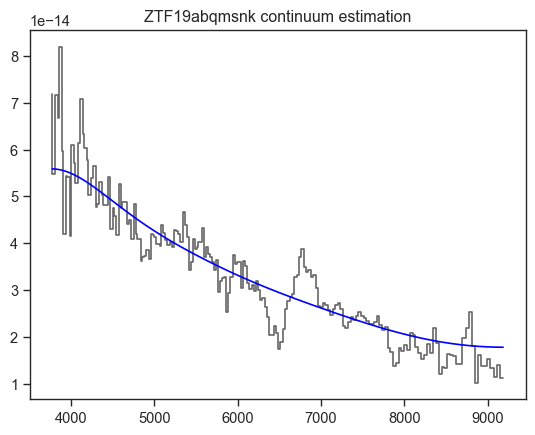

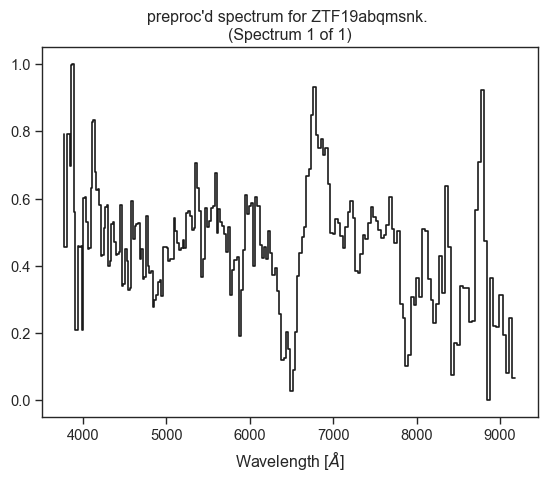

5 ZTF19abxtcio


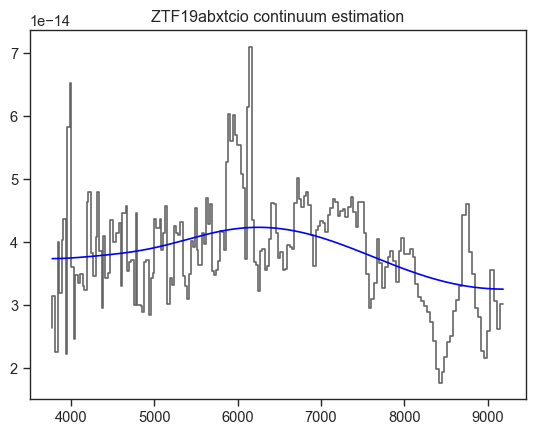

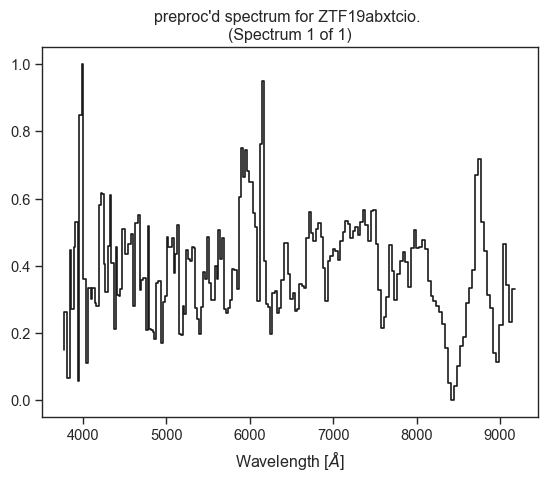

6 ZTF19aceshib


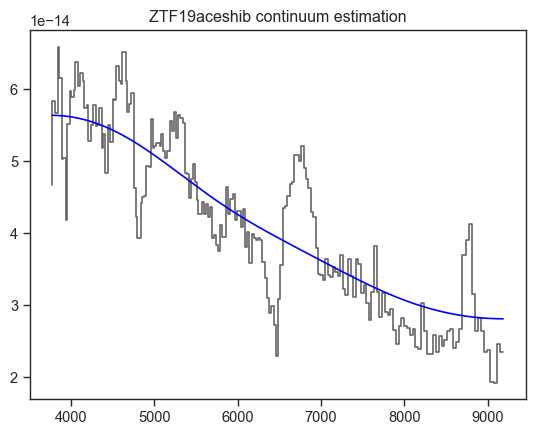

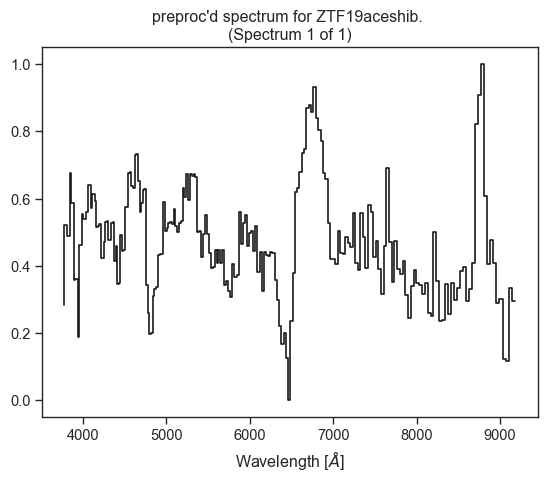

7 ZTF20adadlqm


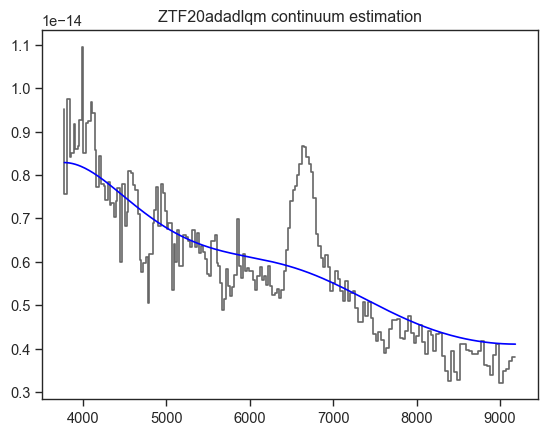

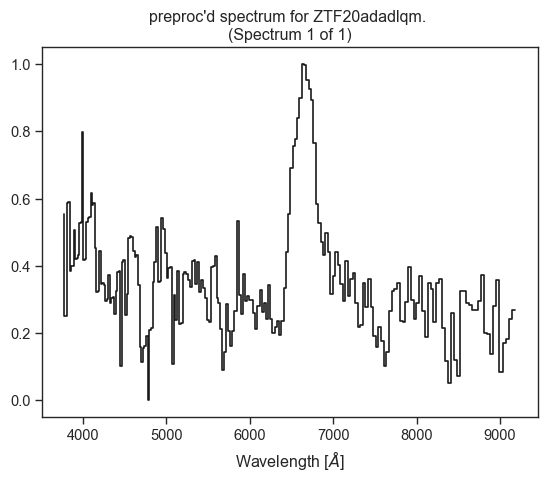

8 ZTF20acgiglu


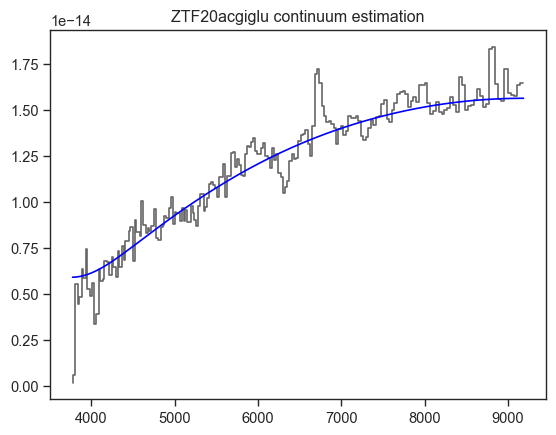

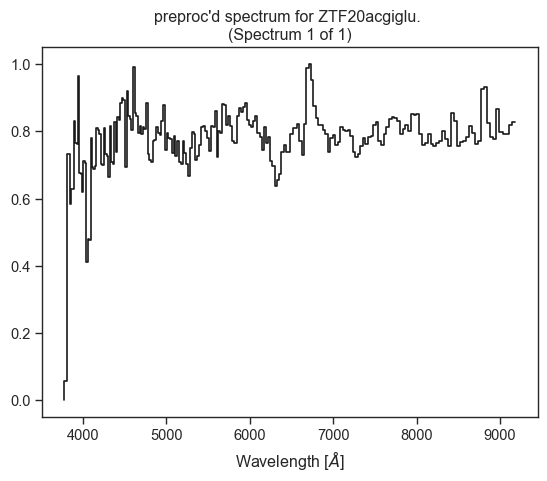

9 ZTF21aaxxmvs


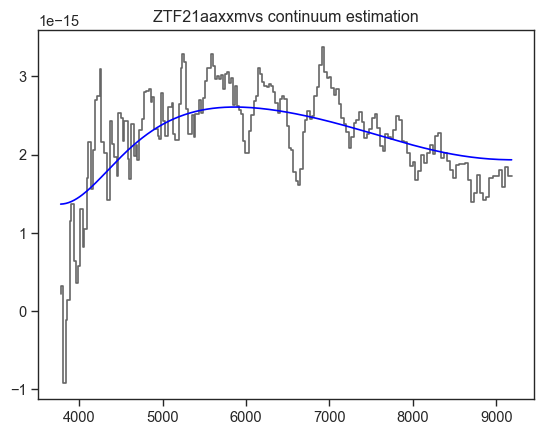

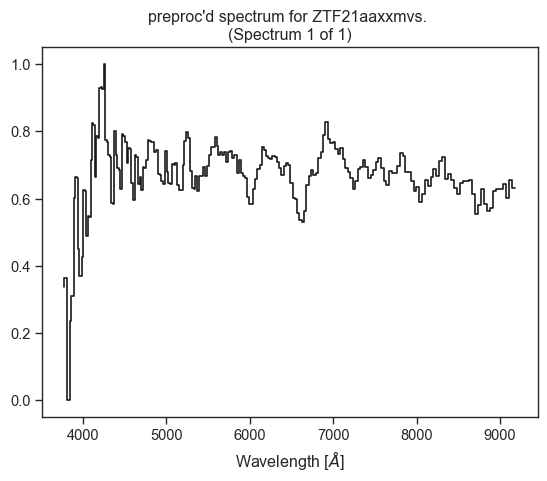

10 ZTF21aayfnjz


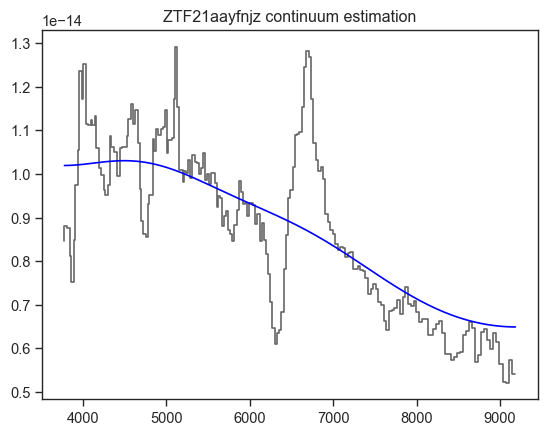

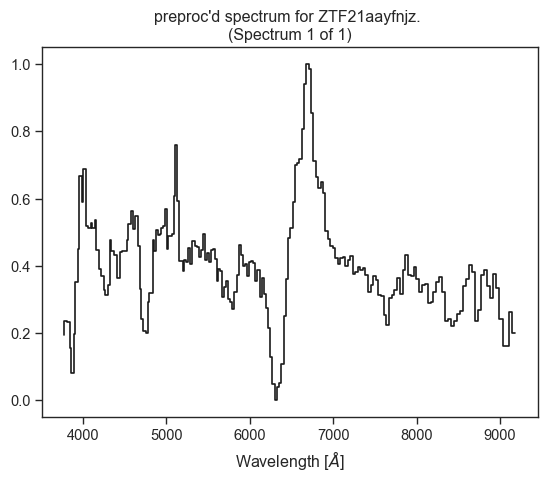

11 ZTF21abqvzjy


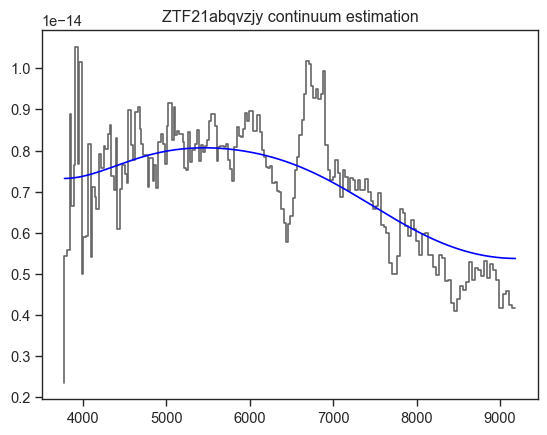

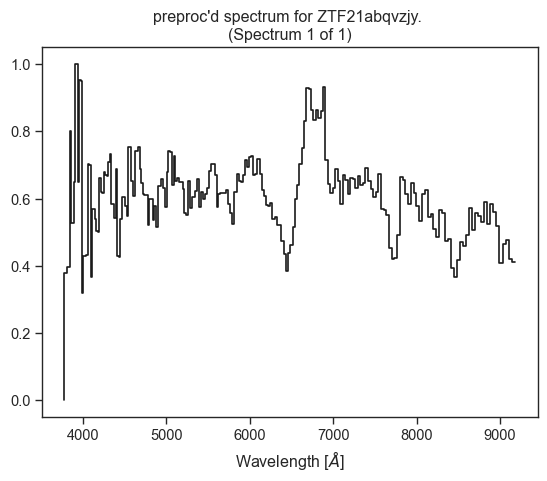

12 ZTF23aaialcw


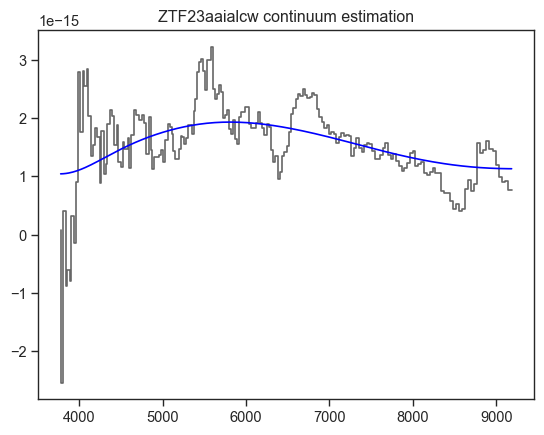

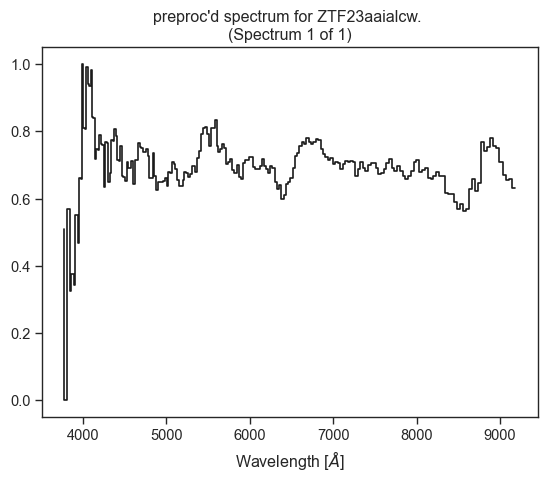

13 ZTF23aazjwtl


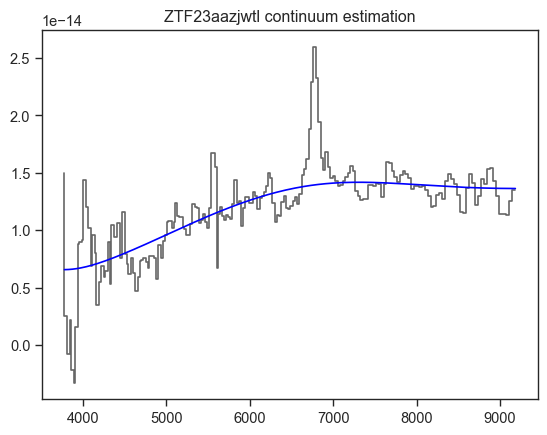

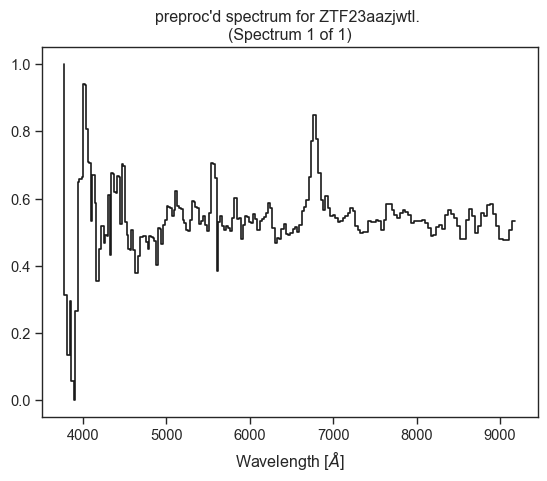

14 ZTF23aaaprhz


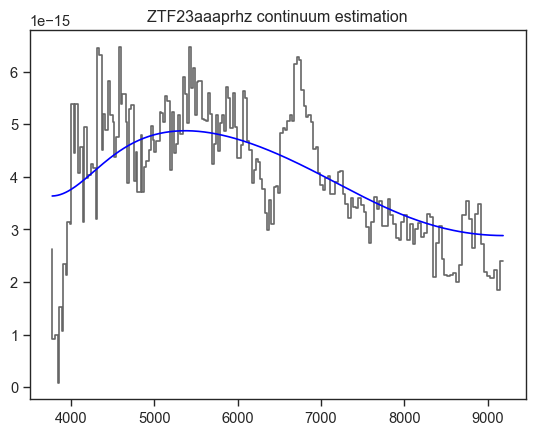

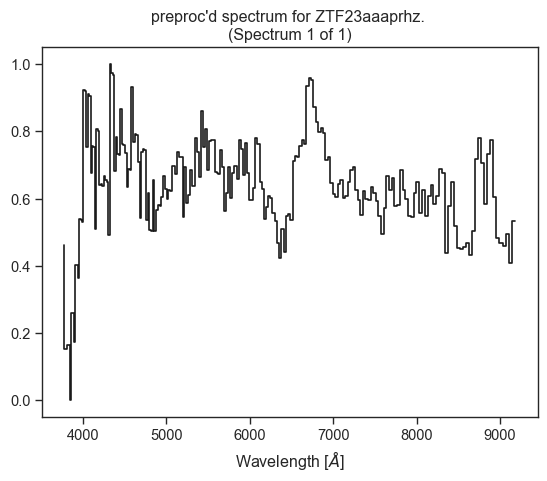

15 ZTF24abpdzvm


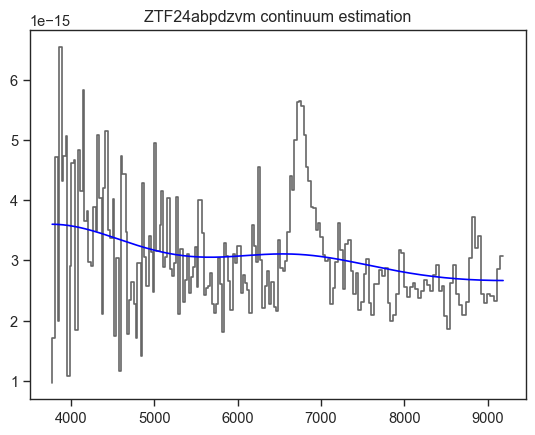

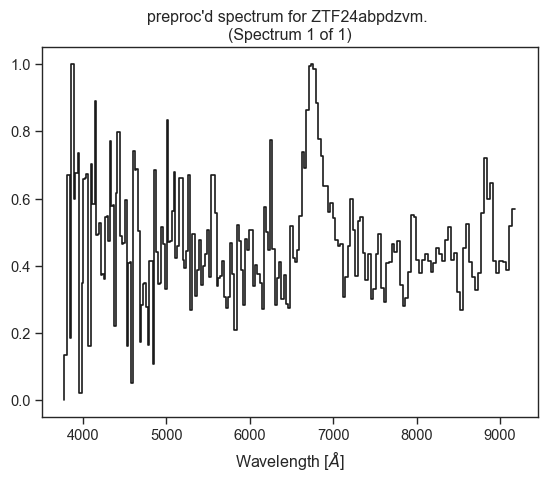

In [191]:
spectra_files_for_iib, ztf_names_ordered_iib = get_list_of_spec_files('iib_spectra', 'SN IIb')

for i in range(len(spectra_files_for_iib)):
    sfiles = spectra_files_for_iib[i]
    ztfname = ztf_names_ordered_iib[i]
    print(i, ztfname)
    preproc_spectra4maven(sfiles, save=True, plot=True, savedir='./maven_data/spectra/', ztfname=ztfname)

0 ZTF19aaznwze


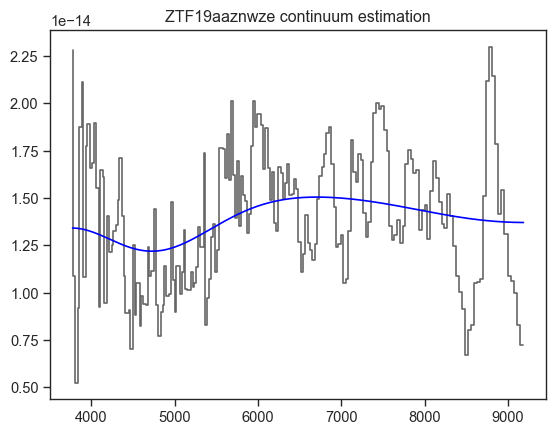

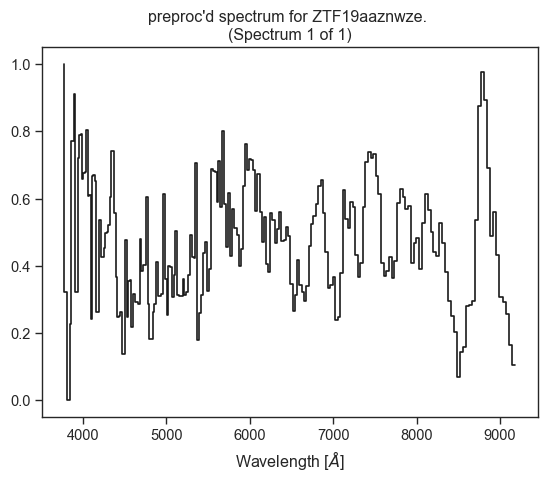

In [192]:
spectra_files_for_carich, ztf_names_ordered_carich = get_list_of_spec_files('ca-rich_spectra', 'SN Ib-Ca-rich')

for i in range(len(spectra_files_for_carich)):
    sfiles = spectra_files_for_carich[i]
    ztfname = ztf_names_ordered_carich[i]
    print(i, ztfname)
    preproc_spectra4maven(sfiles, save=True, plot=True, savedir='./maven_data/spectra/', ztfname=ztfname)

0 ZTF18aahhzqn


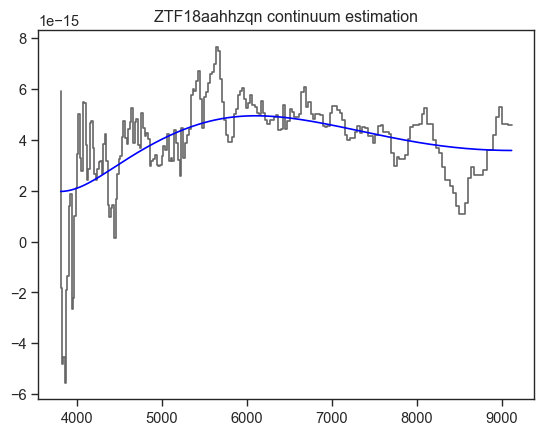

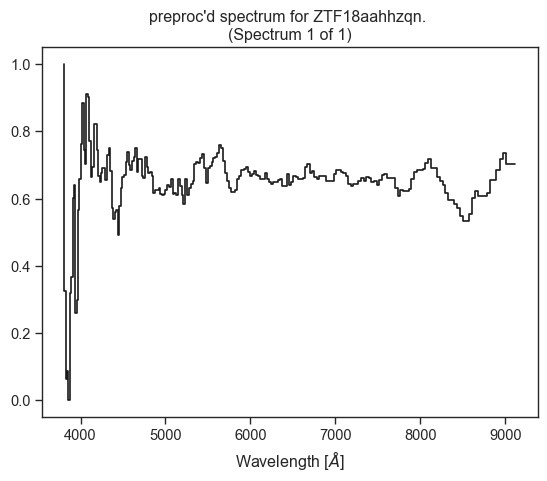

1 ZTF18acisruf


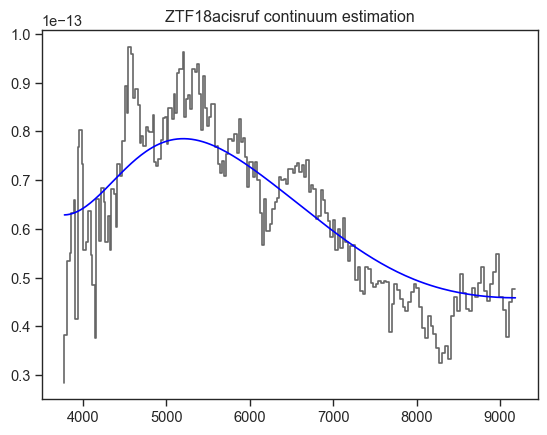

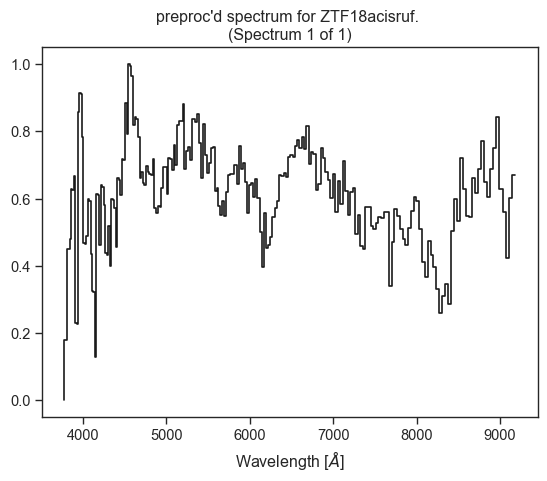

2 ZTF22aaxtias


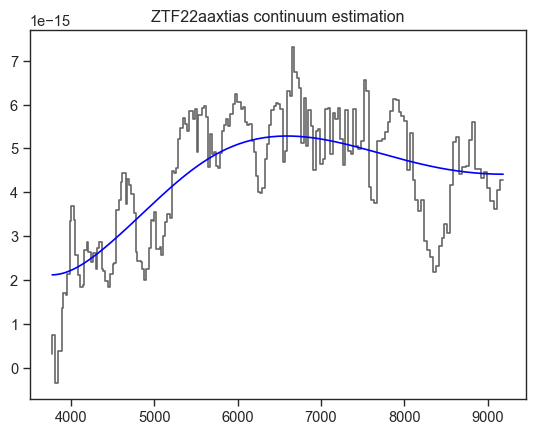

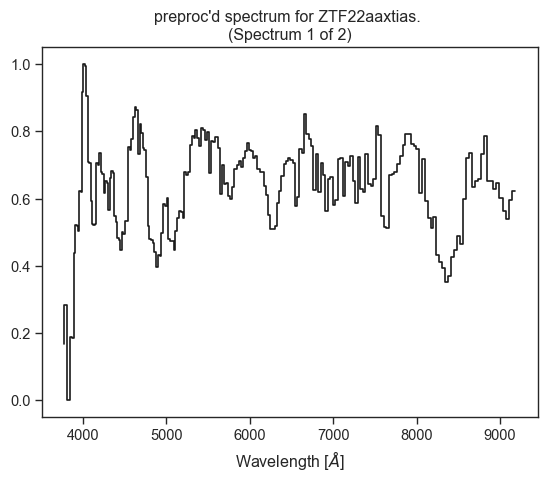

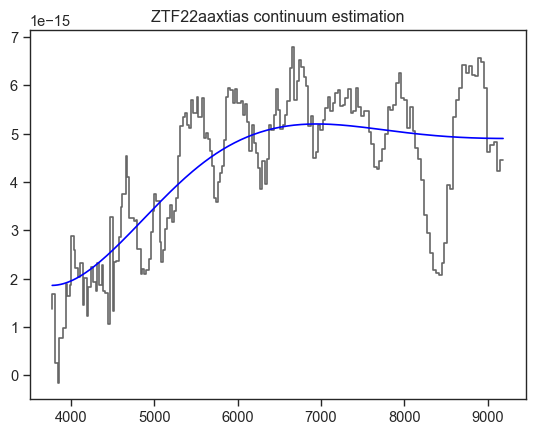

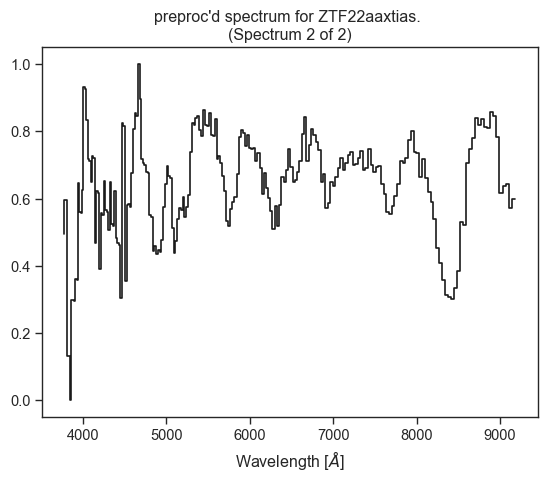

3 ZTF23abhyxpr


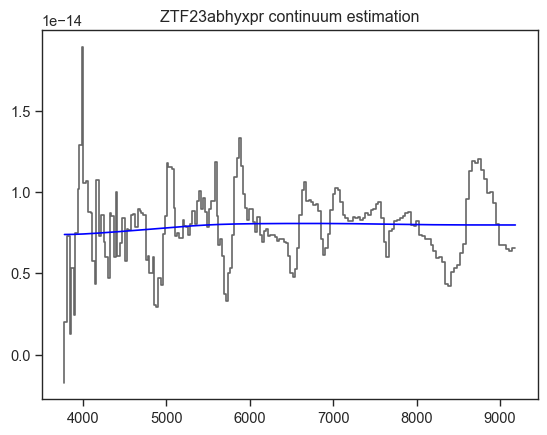

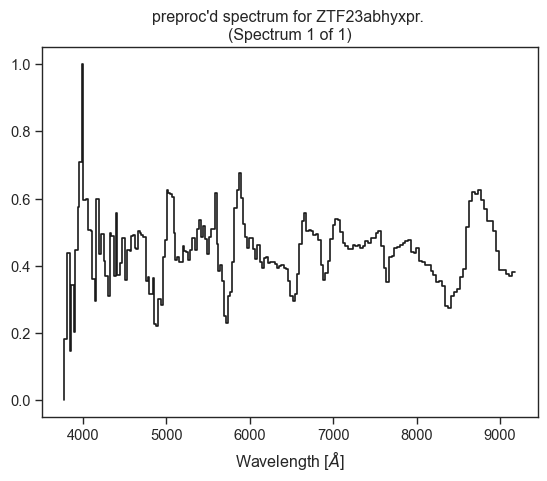

In [193]:
spectra_files_for_ibc, ztf_names_ordered_ibc = get_list_of_spec_files('ibc_spectra', 'SN Ib/c')

for i in range(len(spectra_files_for_ibc)):
    sfiles = spectra_files_for_ibc[i]
    ztfname = ztf_names_ordered_ibc[i]
    print(i, ztfname)
    preproc_spectra4maven(sfiles, save=True, plot=True, savedir='./maven_data/spectra/', ztfname=ztfname)

0 ZTF18aakuewf


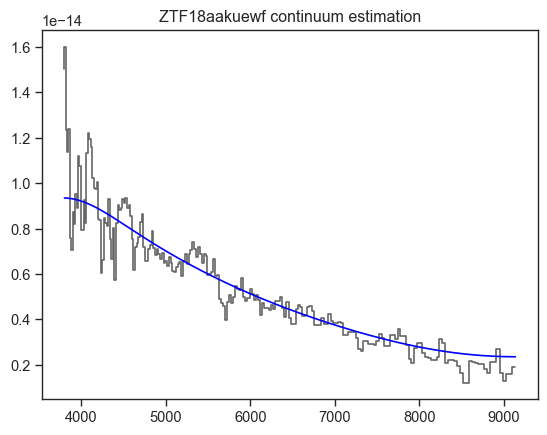

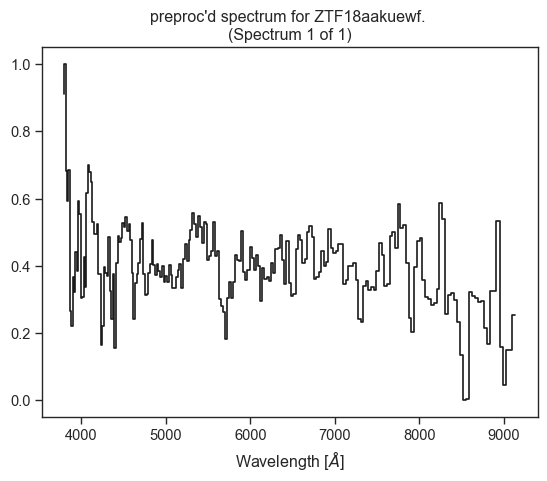

1 ZTF18abwkrbl


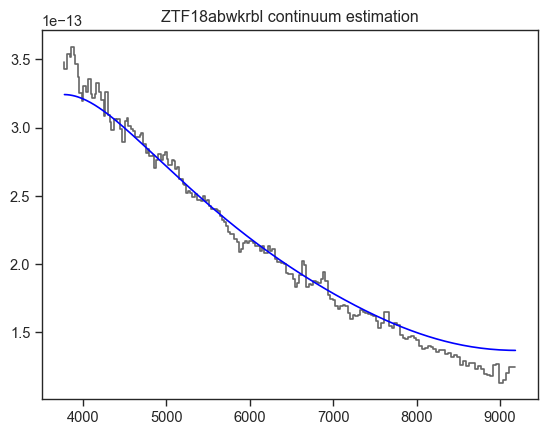

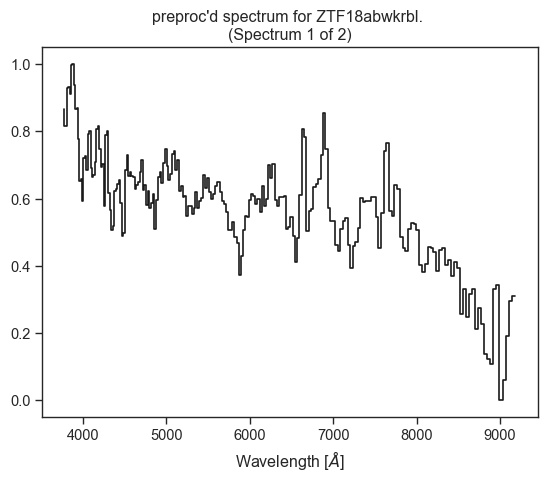

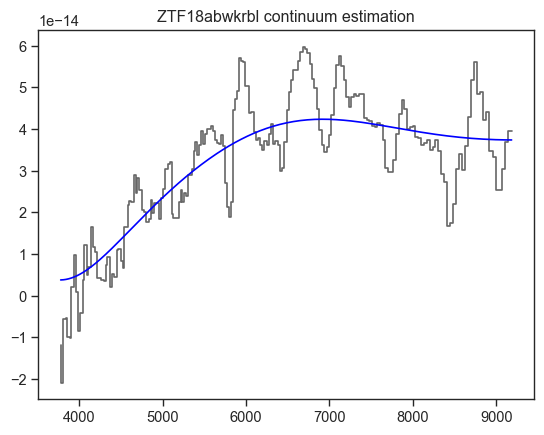

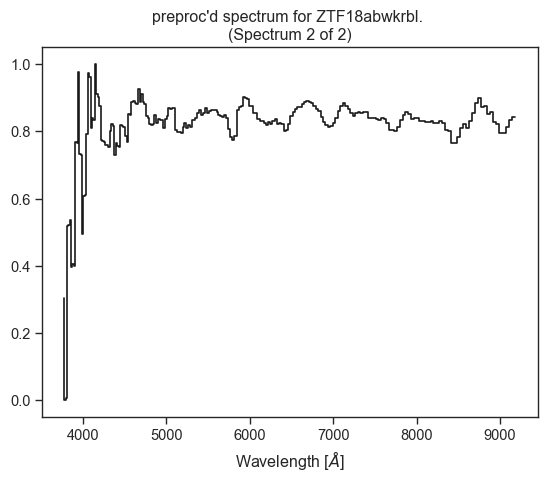

2 ZTF19aapfmki


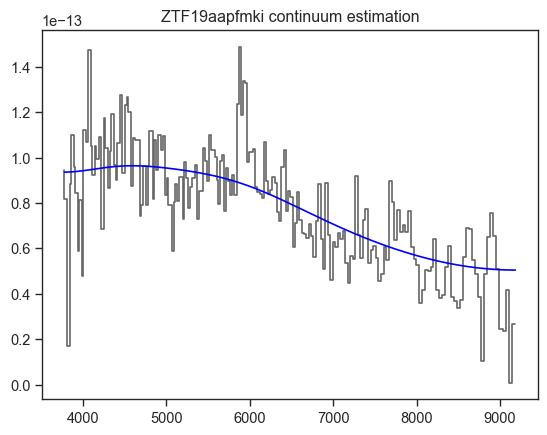

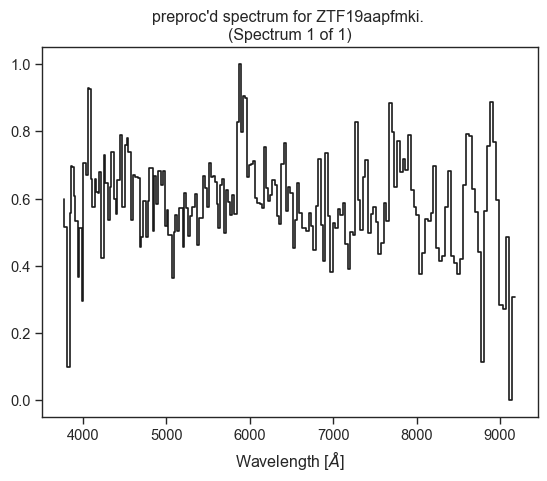

3 ZTF20aalrqbu


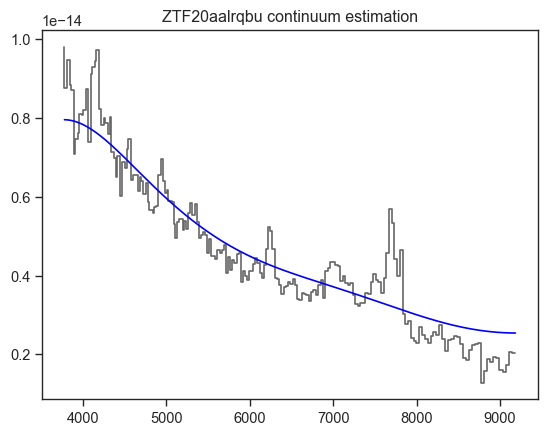

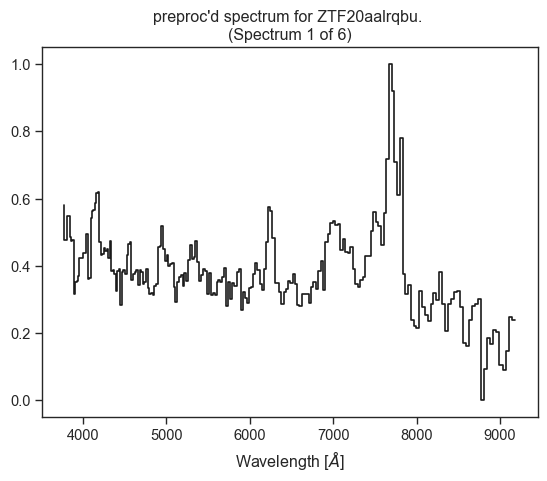

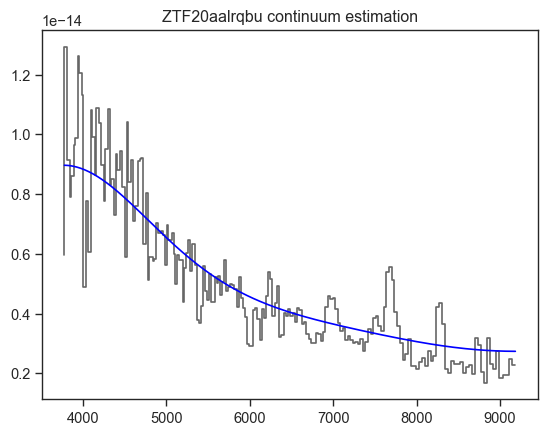

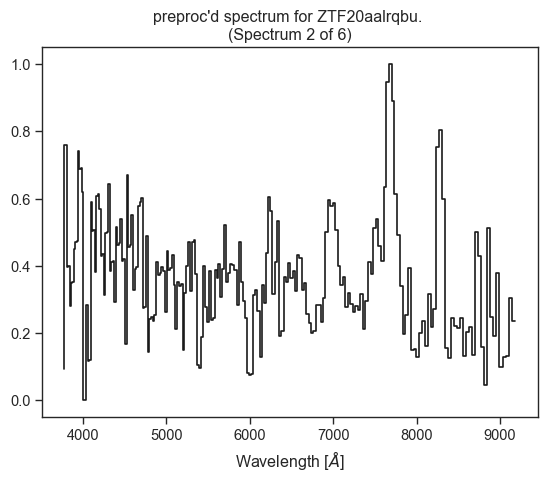

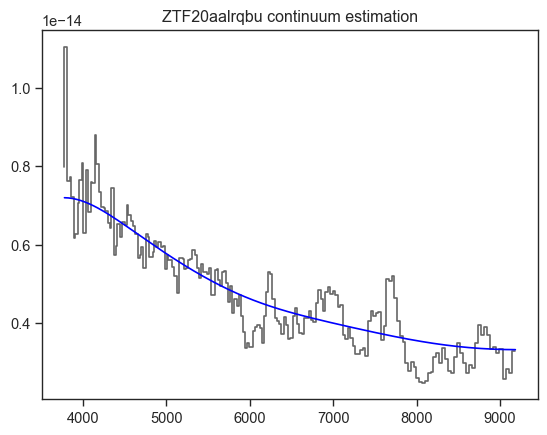

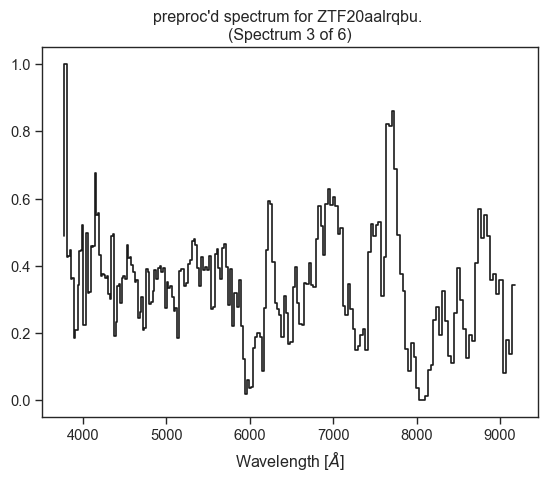

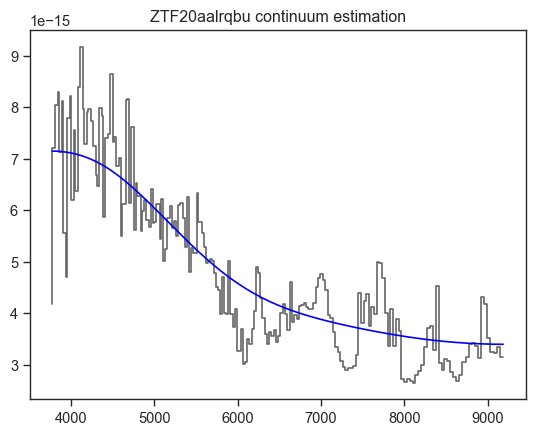

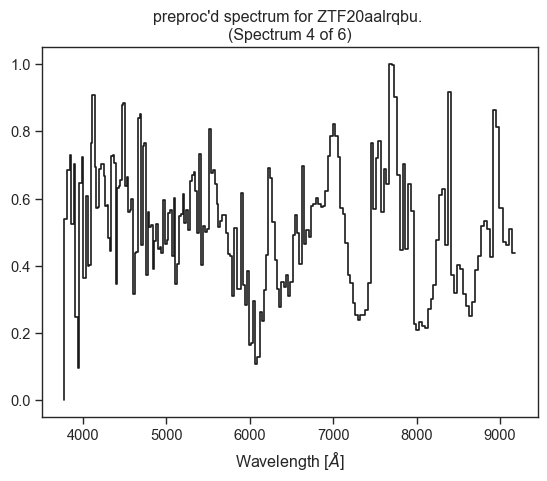

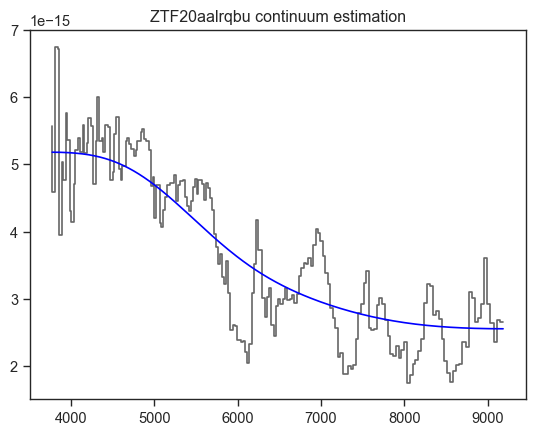

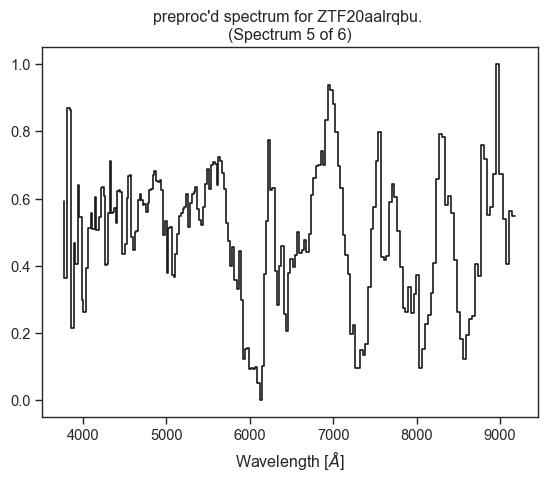

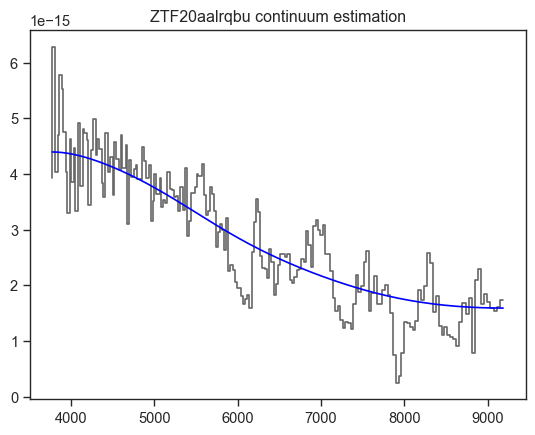

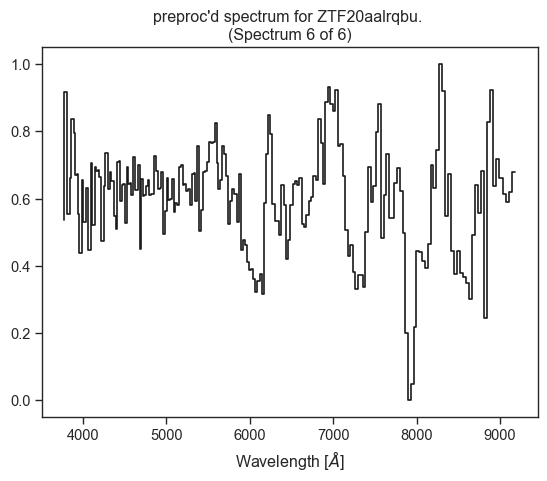

4 ZTF23aapuknd


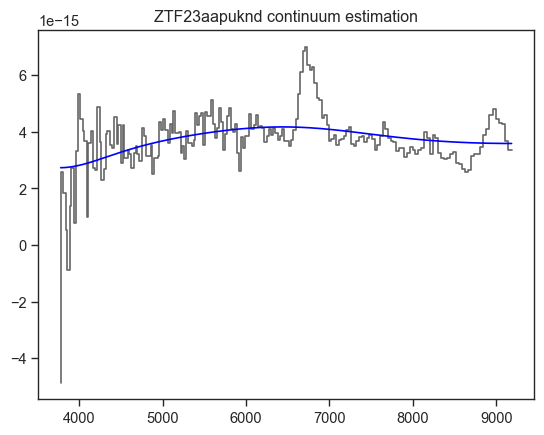

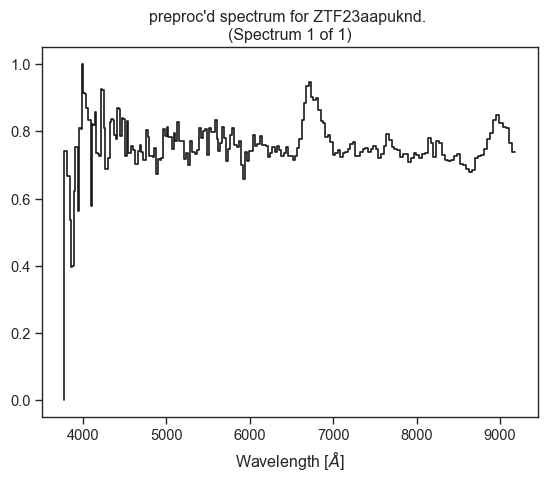

In [194]:
spectra_files_for_ibn, ztf_names_ordered_ibn = get_list_of_spec_files('ibncn_spectra', 'SN Ibn')

for i in range(len(spectra_files_for_ibn)):
    sfiles = spectra_files_for_ibn[i]
    ztfname = ztf_names_ordered_ibn[i]
    print(i, ztfname)
    preproc_spectra4maven(sfiles, save=True, plot=True, savedir='./maven_data/spectra/', ztfname=ztfname)

0 ZTF21aaxtctv


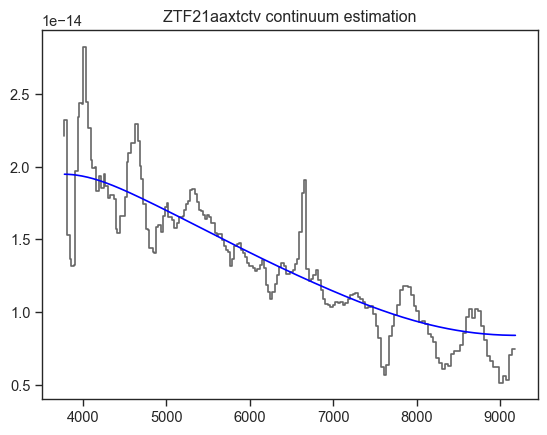

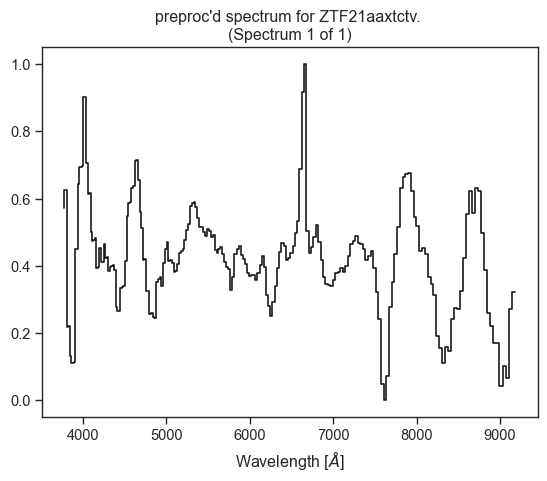

In [195]:
spectra_files_for_icpec, ztf_names_ordered_icpec = get_list_of_spec_files('icpec_spectra', 'SN Ic-pec')

for i in range(len(spectra_files_for_icpec)):
    sfiles = spectra_files_for_icpec[i]
    ztfname = ztf_names_ordered_icpec[i]
    print(i, ztfname)
    preproc_spectra4maven(sfiles, save=True, plot=True, savedir='./maven_data/spectra/', ztfname=ztfname)

0 ZTF19aayejww


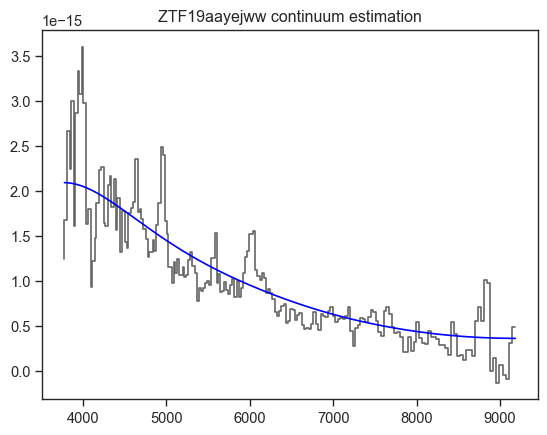

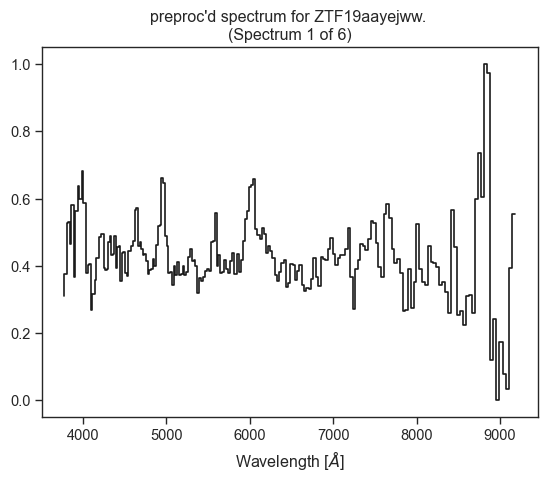

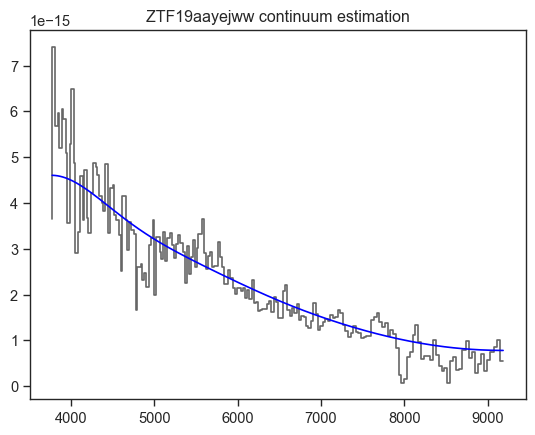

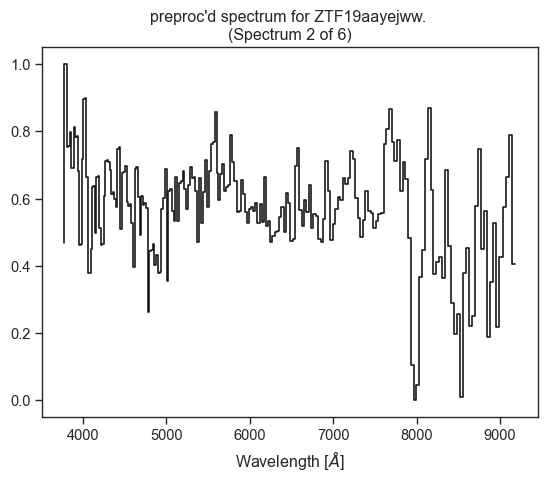

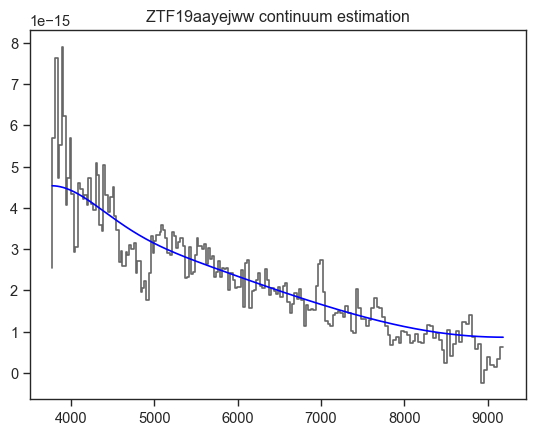

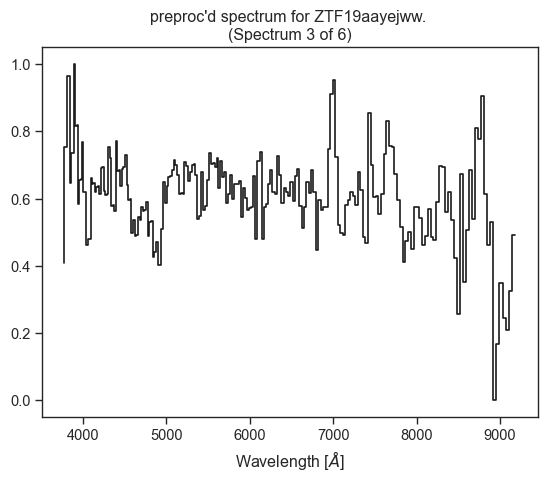

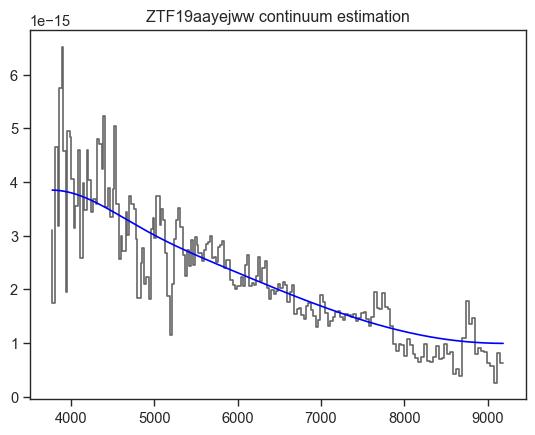

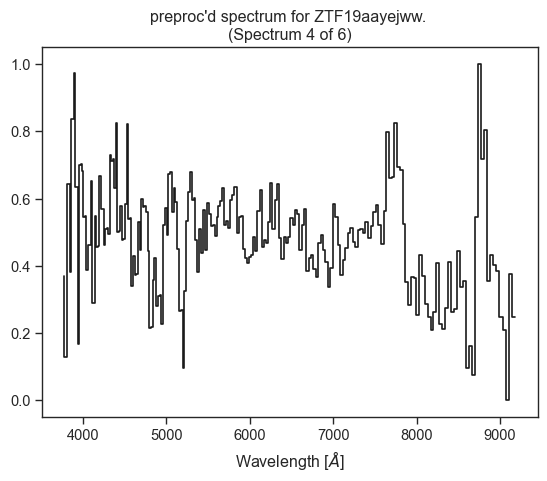

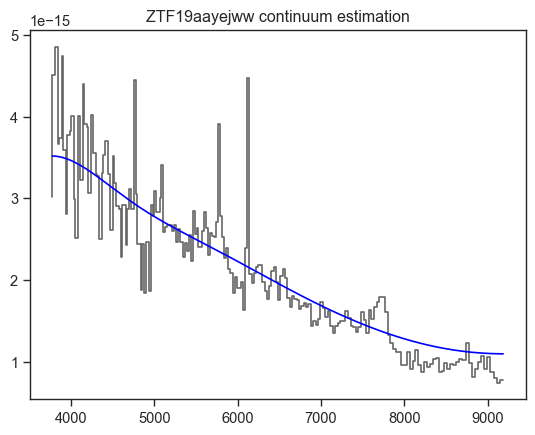

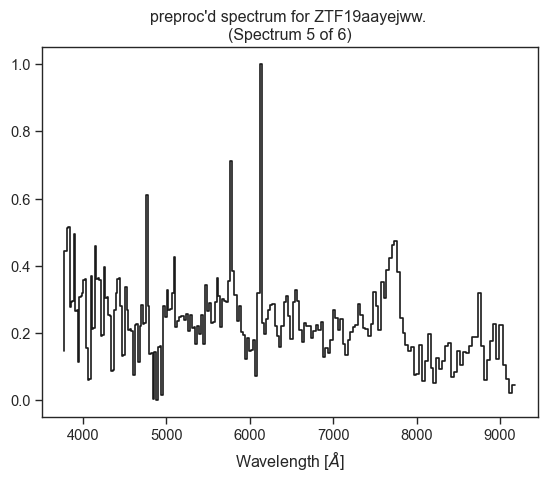

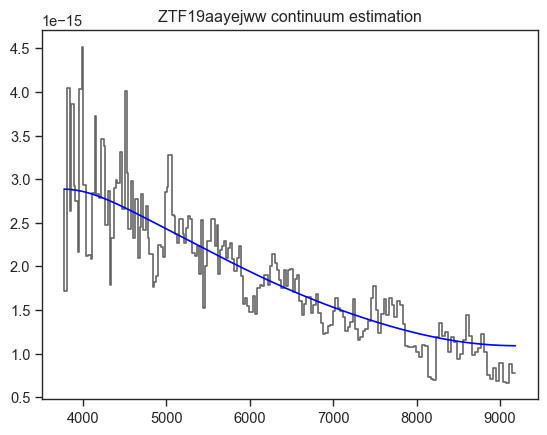

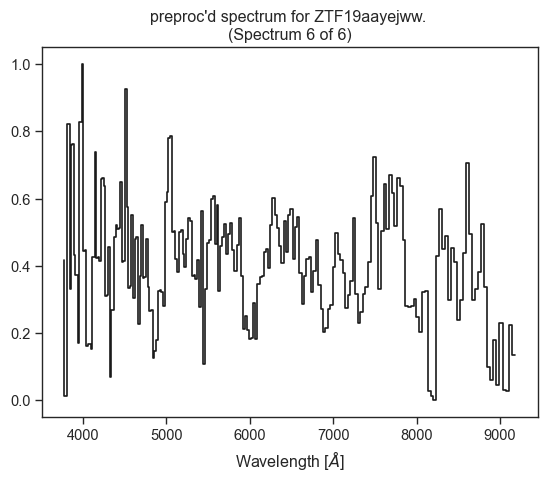

In [48]:
spectra_files_for_icn, ztf_names_ordered_icn = get_list_of_spec_files('ibncn_spectra', 'SN Icn')

for i in range(len(spectra_files_for_icn)):
    sfiles = spectra_files_for_icn[i]
    ztfname = ztf_names_ordered_icn[i]
    print(i, ztfname)
    preproc_spectra4maven(sfiles, save=True, plot=True, savedir='./maven_data/spectra/', ztfname=ztfname)

In [ ]:
"""
old code for pre-processing spectra
        # w_den = (w1 - w0)/nw 
        # smooth = 6

        ##move the spectra to have mean = 0
        # mean = np.mean(spectrafile['flux'])
        # flux_cen0 = spectrafile['flux']-mean
        # 
        ## set values in all columns, with wavelength outside of 3500-10000, to 0
        # spectrafile.loc[(spectrafile['wavelength']<3500)|(spectrafile['wavelength']>10000), ['']] = 0
        # 
        ## apply low-pass median filter to smooth spectrum
        # del_lam = dataset.loc[dataset['ztf_name']==ztfname, 'Del-Lambda'].iloc[i]
        # if del_lam>w_den:
        #     print('Original spectrum spacing larger than new spacing--skipping low-pass median filter')
        # else:
        #     window_size = math.ceil( (w_den / del_lam) * smooth ) #rounds value to next highest integer
        #     # print(f'windowsize={window_size}')
        #     smooth_spec = spectrafile['flux'].rolling(1, center=True, min_periods=1).median()
        #     spectrafile['smooth_flux'] = smooth_spec
        ##log-wavelength binning
                # log_wave = np.logspace(np.log(w0), np.log(w1), num=nw, endpoint=True, base=np.e)
        # log_wave_mid, binned_fluxes = [],[]
        # for j, rightbin in enumerate(log_wave[1:]):
        #     leftbin = log_wave[j]
        #     if del_lam>w_den: #use non-smoothed spec
        #         binned_flux = spectrafile.loc[(leftbin<spectrafile['wavelength'])&
        #                                     (spectrafile['wavelength']<rightbin),
        #                                     'flux'].sum() #smooth_flux
        #     else:
        #         binned_flux = spectrafile.loc[(leftbin<spectrafile['wavelength'])&
        #                                     (spectrafile['wavelength']<rightbin),
        #                                     'smooth_flux'].sum()
        #     binned_fluxes.append(binned_flux)
        #     log_wave_mid.append((leftbin+rightbin)/2)

        # fitting and dividing out 13-point cubic spline fit to remove continuum
        # non0_idx, non0_wave, non0_flux = [],[],[]
        # for k,f in enumerate(fbins):
        #     if f != 0:
        #         non0_idx.append(k)
        #         non0_wave.append(wbins[k])
        #         non0_flux.append(f)

        #smooth?
        # smooth_spec = flux.rolling(2, center=True, min_periods=1).median()
        
        # # fitting and dividing out N-point cubic spline fit to remove continuum
        #     #choose N evenly(?) spaced points along our array
        # npoints = 2
        # idx = np.round(np.linspace(0, len(wbins) - 1, npoints)).astype(int)
        # # idx = [2, 35, 125, 180, 210]
        # idx = [35, 180]
        # cs_wave = [wbins[m] for m in idx]
        # cs_flux = [fbins[n] for n in idx]
        #     #fit the cubicspline to just those points
        # cs = CubicSpline(cs_wave, cs_flux)
        #     #divide the cubic spline fit from whole array
        # cont_divid_flux = fbins / cs(wbins)
        
        #debug plots to check if cubicspline fit looks good
        # plt.figure()
        # plt.plot(wbins, fbins*1e13, zorder=0, color='k', alpha=.9)
        # plt.scatter(cs_wave, np.array(cs_flux)*1e13, facecolor='mediumslateblue', zorder=5, s=50, edgecolor='white')
        # plt.plot(wbins, cs(wbins)*1e13, color='mediumslateblue', zorder=3, linewidth=2)
        # plt.title(f"{npoints}-point Cubic Spline for {ztfname}")
        # plt.gca().grid(False)
        # plt.show()
        
        # idx = np.round(np.linspace(0, len(non0_flux) - 1, 13)).astype(int)
        # cs_wave = [non0_wave[m] for m in idx]
        # cs_flux = [non0_flux[n] for n in idx]

        # #updating whole spectrum w/ norm'd values
        # for s,idx in enumerate(non0_idx):
        #     fbins[idx] = norm_flux[s]
        
"""